**Sep2026: runs without errors**

- needs other cluster glacier model data (from standard projections e.g.)

# Estimate glacier model volume steady state differences vs climate model differences...

- I did quite some analysis, but I am not sure how to best sum it up...
- maybe also interesting to analyse aswell whether the different glacir models have different "sensitvities" in the choice of the climate scenario... ---> but actually that is just the "reference" thing, analysed in PartB__3_....

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import scipy
import os
import glob
import matplotlib.pyplot as plt
from datetime import date
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import seaborn as sns

import oggm

from help_functions import pal_models, model_order, d_reg_num_name, model_order_anonymous, get_glob_temp_exp


In [2]:
hue_order_anonymous = []

pal_models_l = []
hue_order = []
for m, p in zip(model_order, pal_models):
    if (m!='OGGM-VAS') and (m!='OGGM_v153'):
        hue_order.append(m)
        pal_models_l.append(p)
for m in hue_order:
    hue_order_anonymous.append(model_order_anonymous[m])
pal_models = pal_models_l

print(hue_order, hue_order_anonymous)
# select the right models:
pal_models = sns.color_palette(pal_models)

dict_model_col = {}
for c,m in zip(pal_models, hue_order):
    dict_model_col[m] = c
    
# select the right models

glac_models = hue_order

num_dict = {0:'(a)', 1:'(b)', 2:'(c)', 3:'(d)', 4: '(e)', 5:'(f)', 6:'(g)', 7:'(h)', 8:'(i)', 9:'(j)', 10:'(k)', 11:'(l)', 12:'(m)'} 


['PyGEM-OGGM_v13', 'GloGEMflow', 'GloGEMflow3D', 'OGGM_v16', 'GLIMB', 'Kraaijenbrink', 'GO', 'CISM2'] ['model 1', 'model 2', 'model 3', 'model 4', 'model 5', 'model 6', 'model 7', 'model 8']


In [3]:
pd_reg_models_vol_5000 = pd.read_csv('PartB_data/steady_state_relative_volume_change.csv', index_col=[0])


**just some checks**

In [4]:
pd_reg_models_vol_5000.loc[pd_reg_models_vol_5000.period_scenario == '1995-2014_hist'].temp_ch_ipcc.unique()

array([0.90146673, 0.91331315, 0.90493955, 0.92224895, 1.05876741])

In [5]:
pd_reg_models_vol_5000.loc[pd_reg_models_vol_5000.period_scenario == '2021-2040_ssp126'].temp_ch_ipcc.quantile([0,0.5,1])

0.0    1.469114
0.5    1.636715
1.0    2.176144
Name: temp_ch_ipcc, dtype: float64

In [6]:
pd_reg_models_vol_5000.loc[pd_reg_models_vol_5000.period_scenario == '2081-2100_ssp126'].temp_ch_ipcc.quantile([0,0.5,1])

0.0    1.659996
0.5    1.947788
1.0    3.038482
Name: temp_ch_ipcc, dtype: float64

In [7]:
pd_reg_models_vol_5000

,model_author,gcm,period_scenario,temp_ch_ipcc,volume_m3,year_after_2020,relative volume change (in %),"delta relative volume change (in %, to median model)","delta relative volume change (in %, to median model, relative to ref period )",rgi_reg
0,GLIMB,gfdl-esm4,1851-1870_hist,0.231409,1.253455e+14,0.0,80.812475,-5.675031,-5.984223,Global
1,GLIMB,gfdl-esm4,1901-1920_hist,0.478289,1.146157e+14,0.0,74.273069,-1.113826,-1.423018,Global
2,GLIMB,gfdl-esm4,1951-1970_hist,0.392281,1.179973e+14,0.0,76.486687,-12.982556,-13.291747,Global
3,GLIMB,gfdl-esm4,1995-2014_hist,0.901467,1.033774e+14,0.0,67.609008,0.309192,0.000000,Global
4,GLIMB,gfdl-esm4,2021-2040_ssp126,1.493792,8.175907e+13,0.0,53.517849,2.054803,1.745611,Global
...,...,...,...,...,...,...,...,...,...,...
11515,CISM2,ukesm1-0-ll,2061-2080_ssp370,4.439977,2.282390e+08,0.0,0.230853,-0.271691,3.702509,11
11516,CISM2,ukesm1-0-ll,2061-2080_ssp585,5.230543,3.317951e+07,0.0,0.033679,-0.102246,3.871955,11
11517,CISM2,ukesm1-0-ll,2081-2100_ssp126,3.038482,2.965017e+09,0.0,3.143693,-1.331851,2.642349,11
11518,CISM2,ukesm1-0-ll,2081-2100_ssp370,5.840495,2.100612e+07,0.0,0.021713,-0.053247,3.920953,11


0.2 5 0.0833736138284337
0.5 15 0.2524779717488781
0.2 14 1.6467728177590986
0.5 21 1.664909941388102
0.2 7 2.951472321285355
0.5 13 2.950346953824412
0.2 3 4.5943250252311145
0.5 5 4.439976778002009


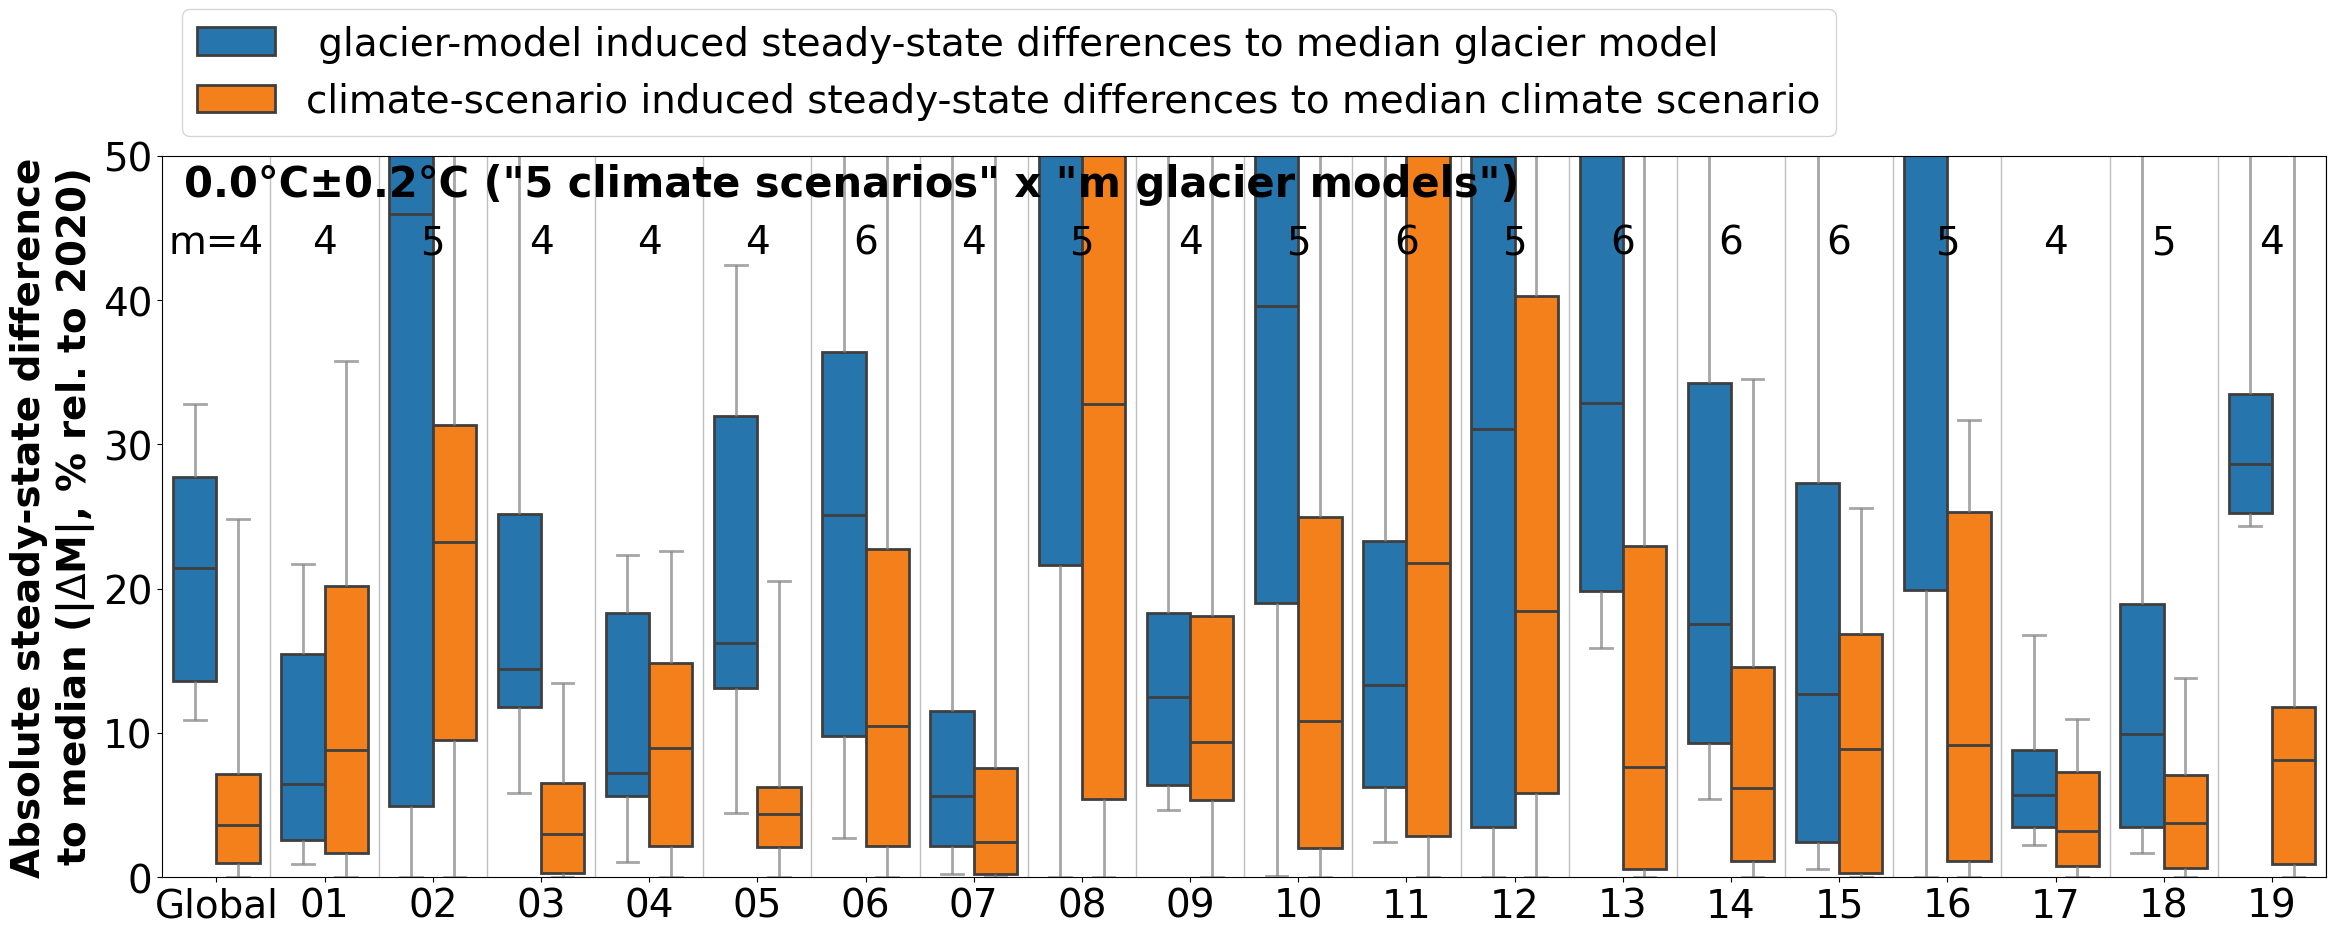

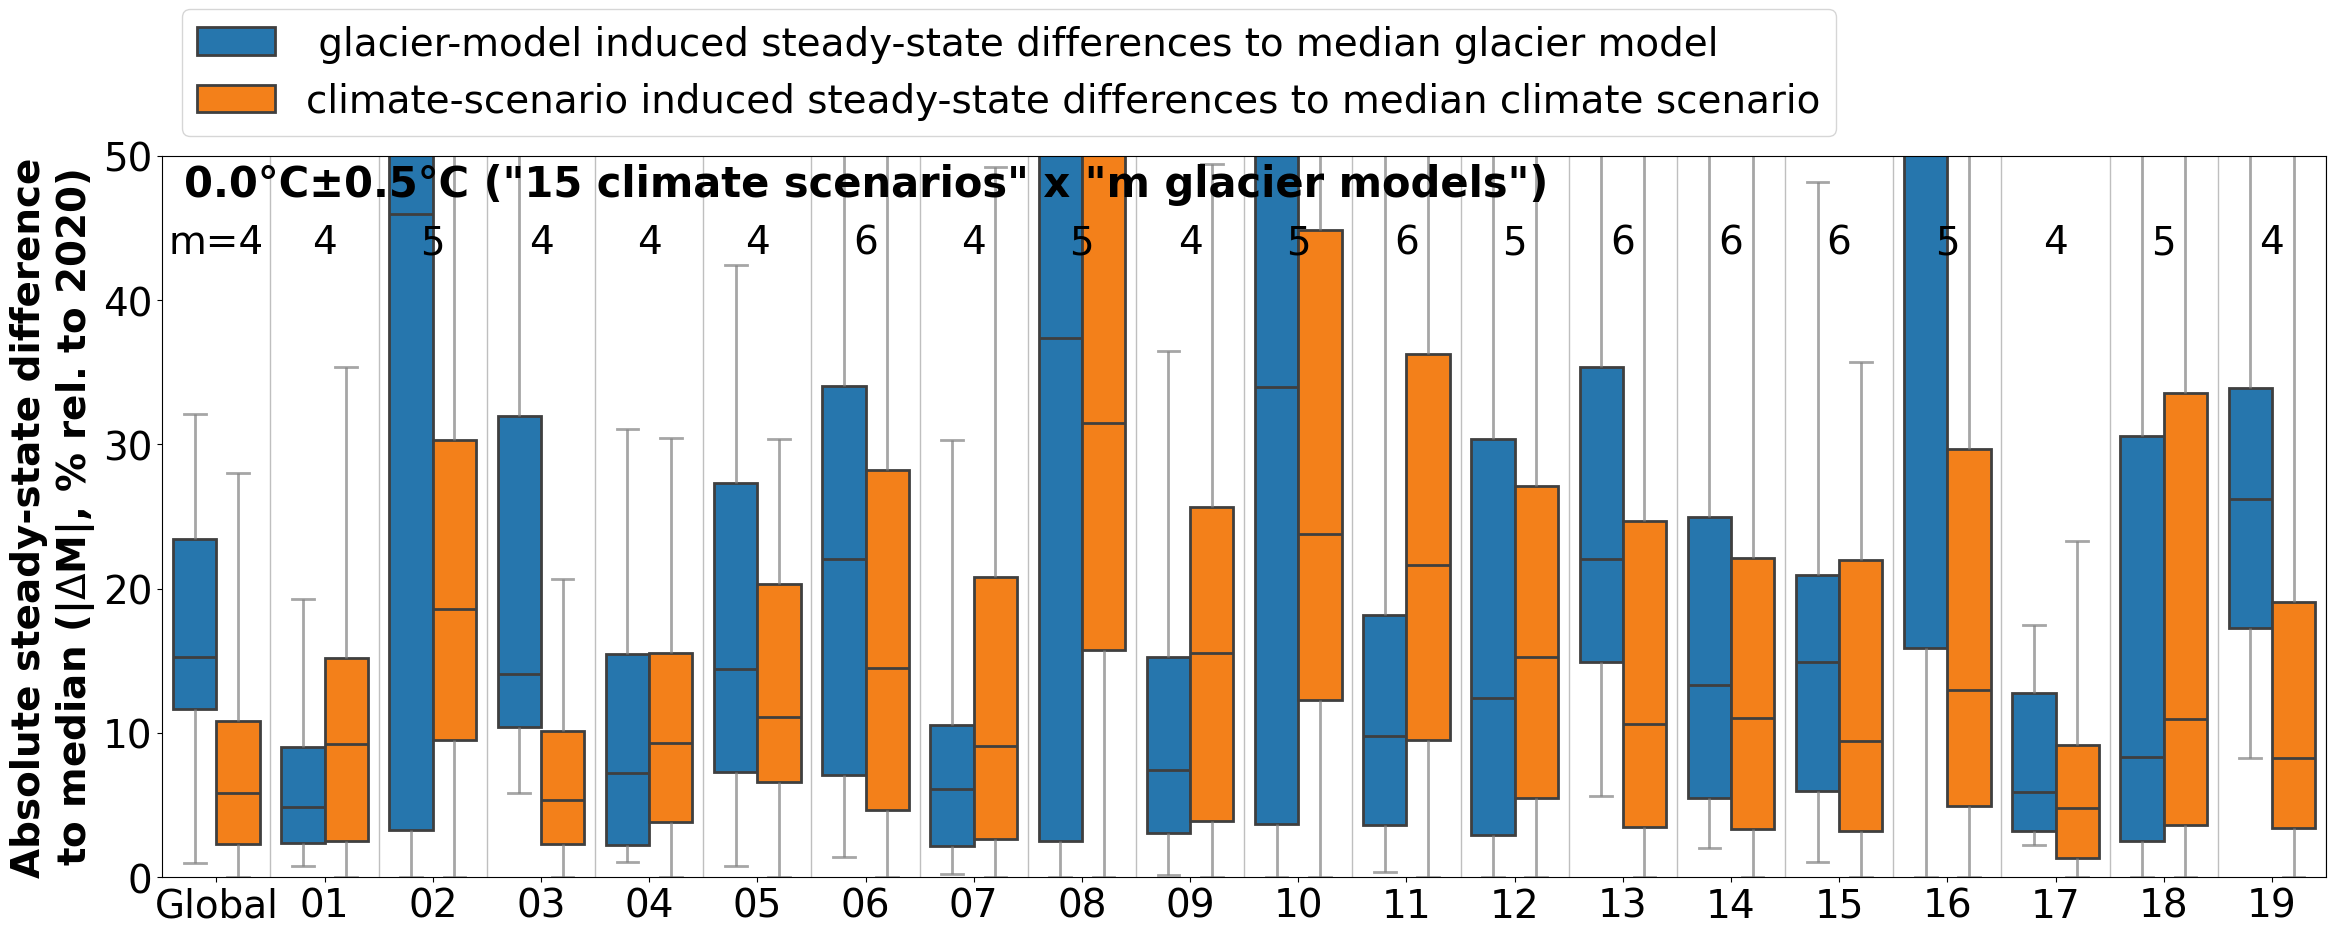

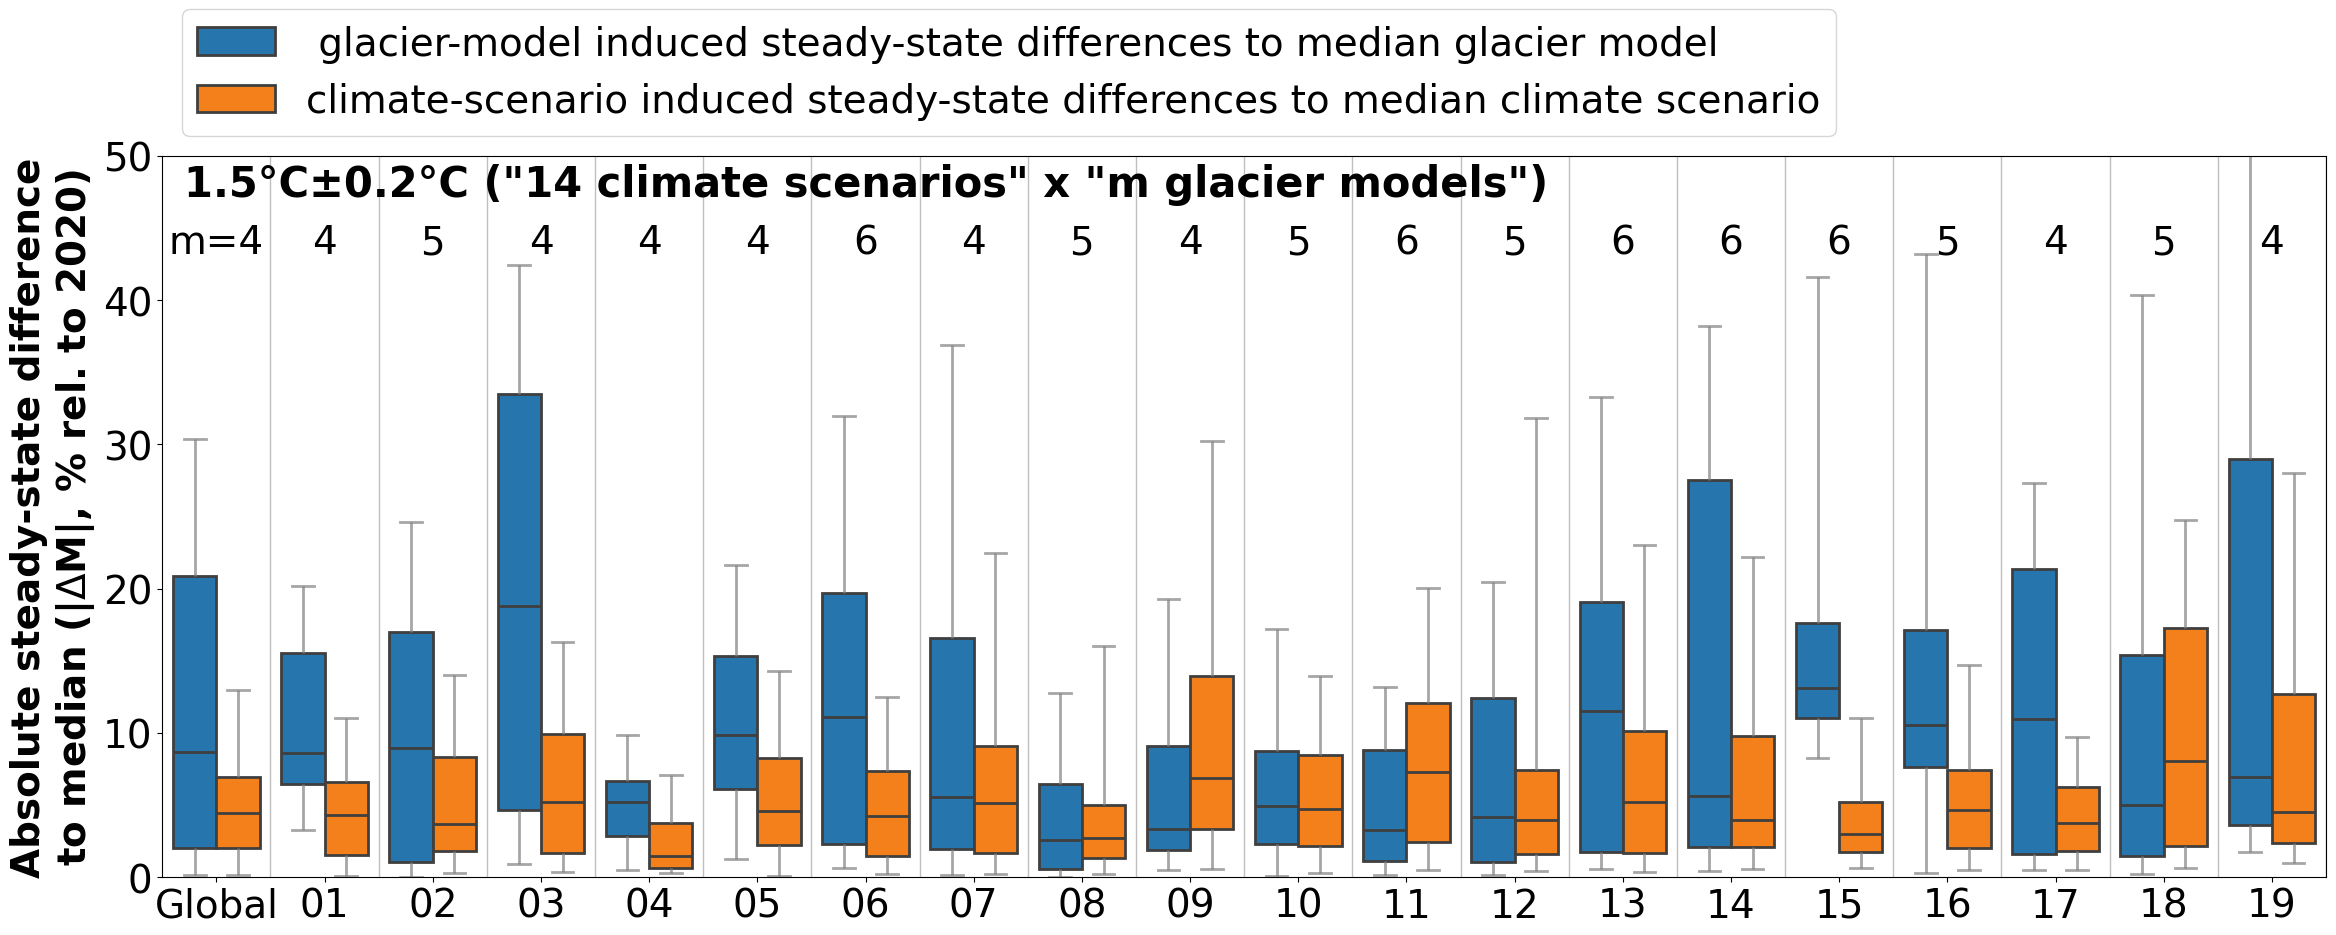

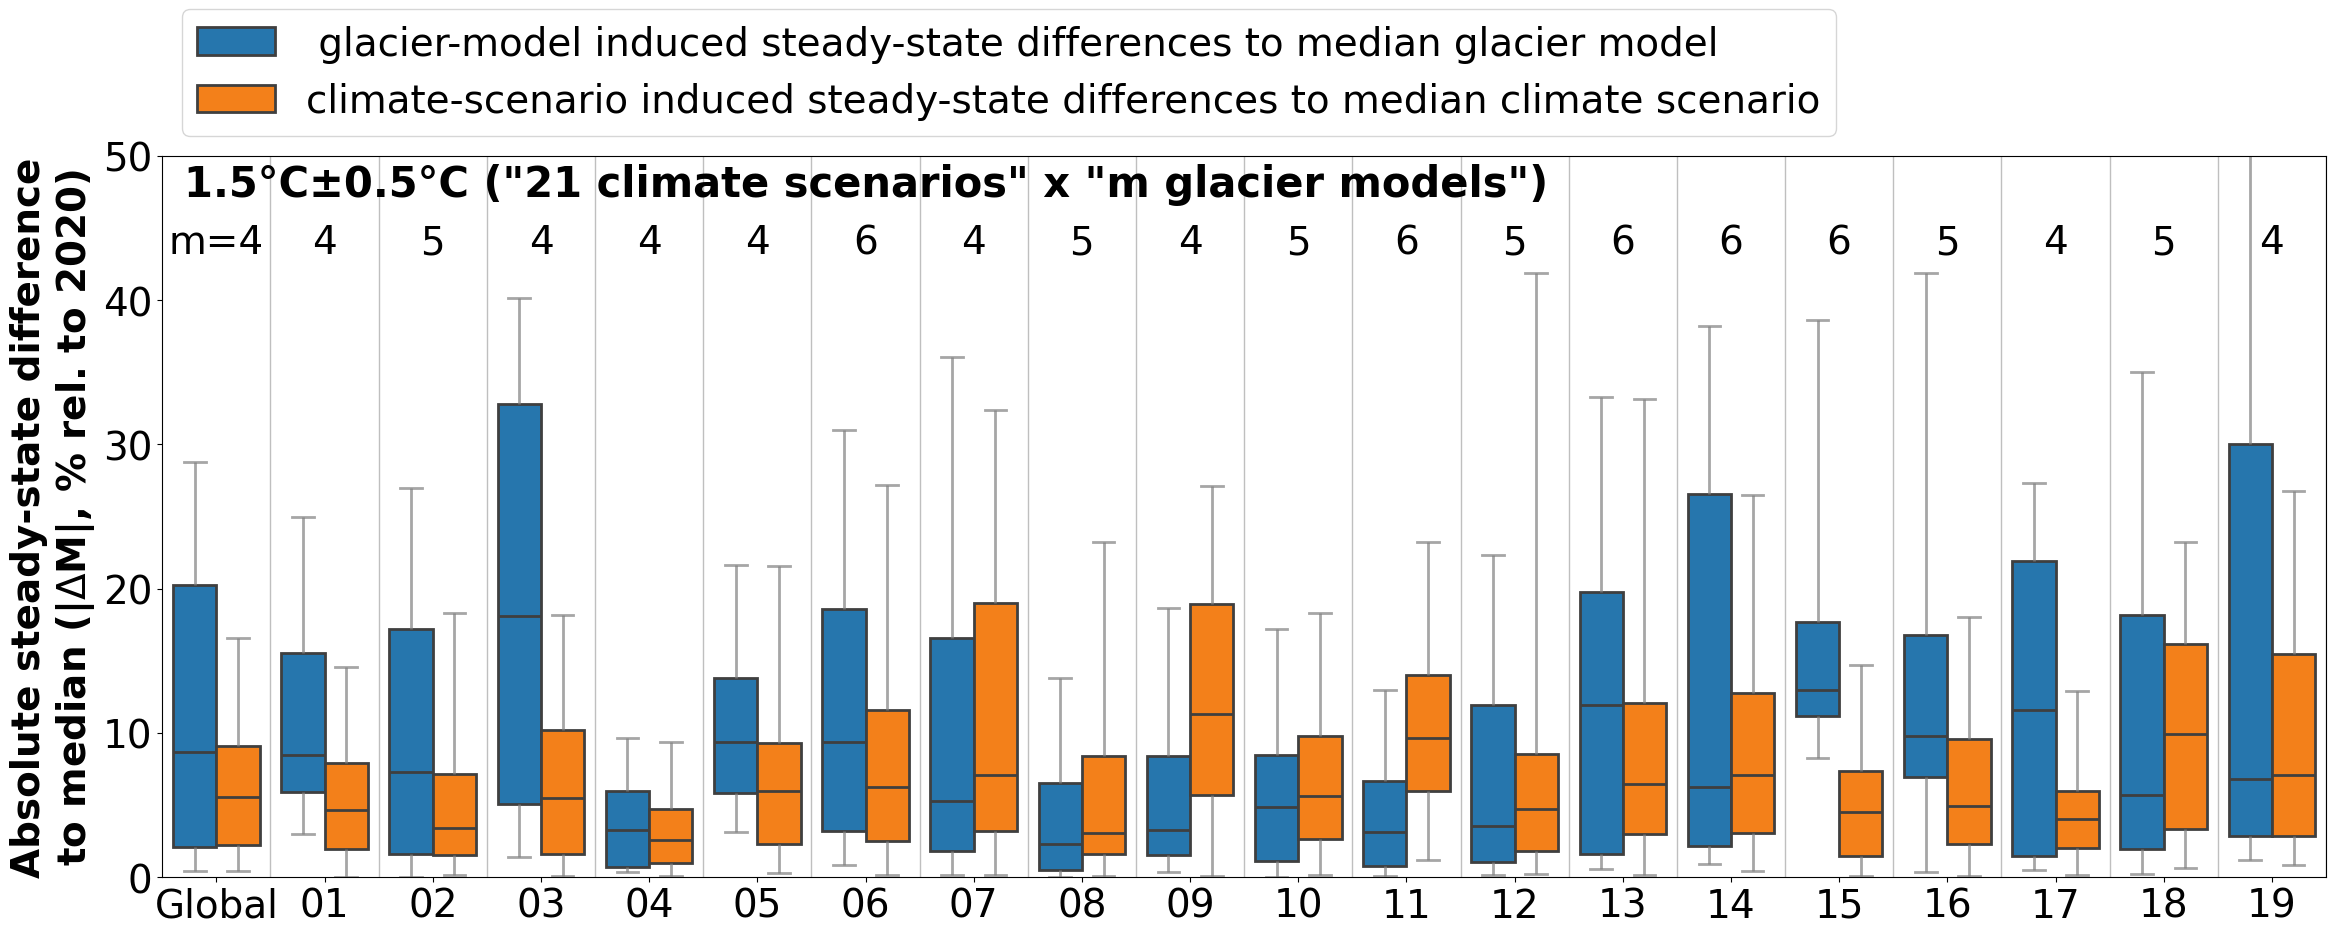

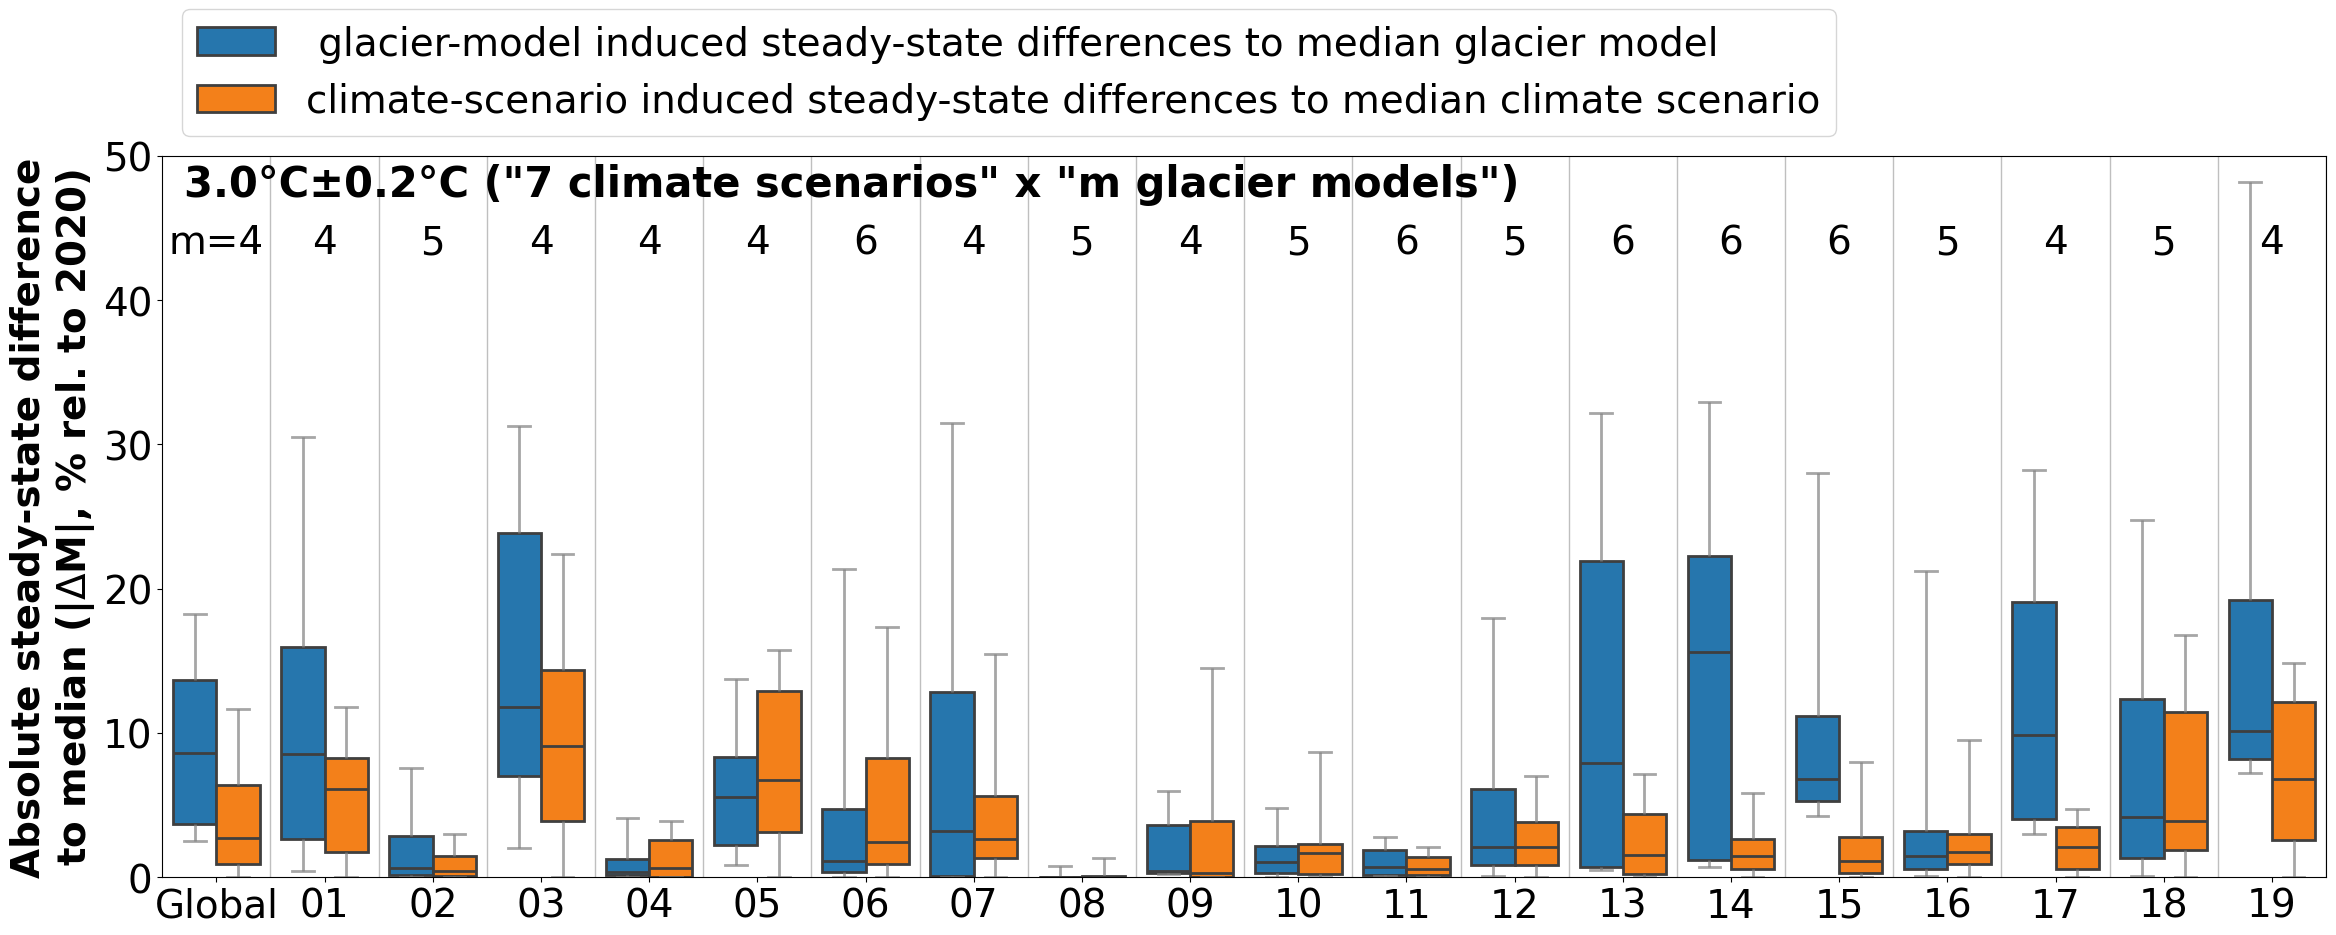

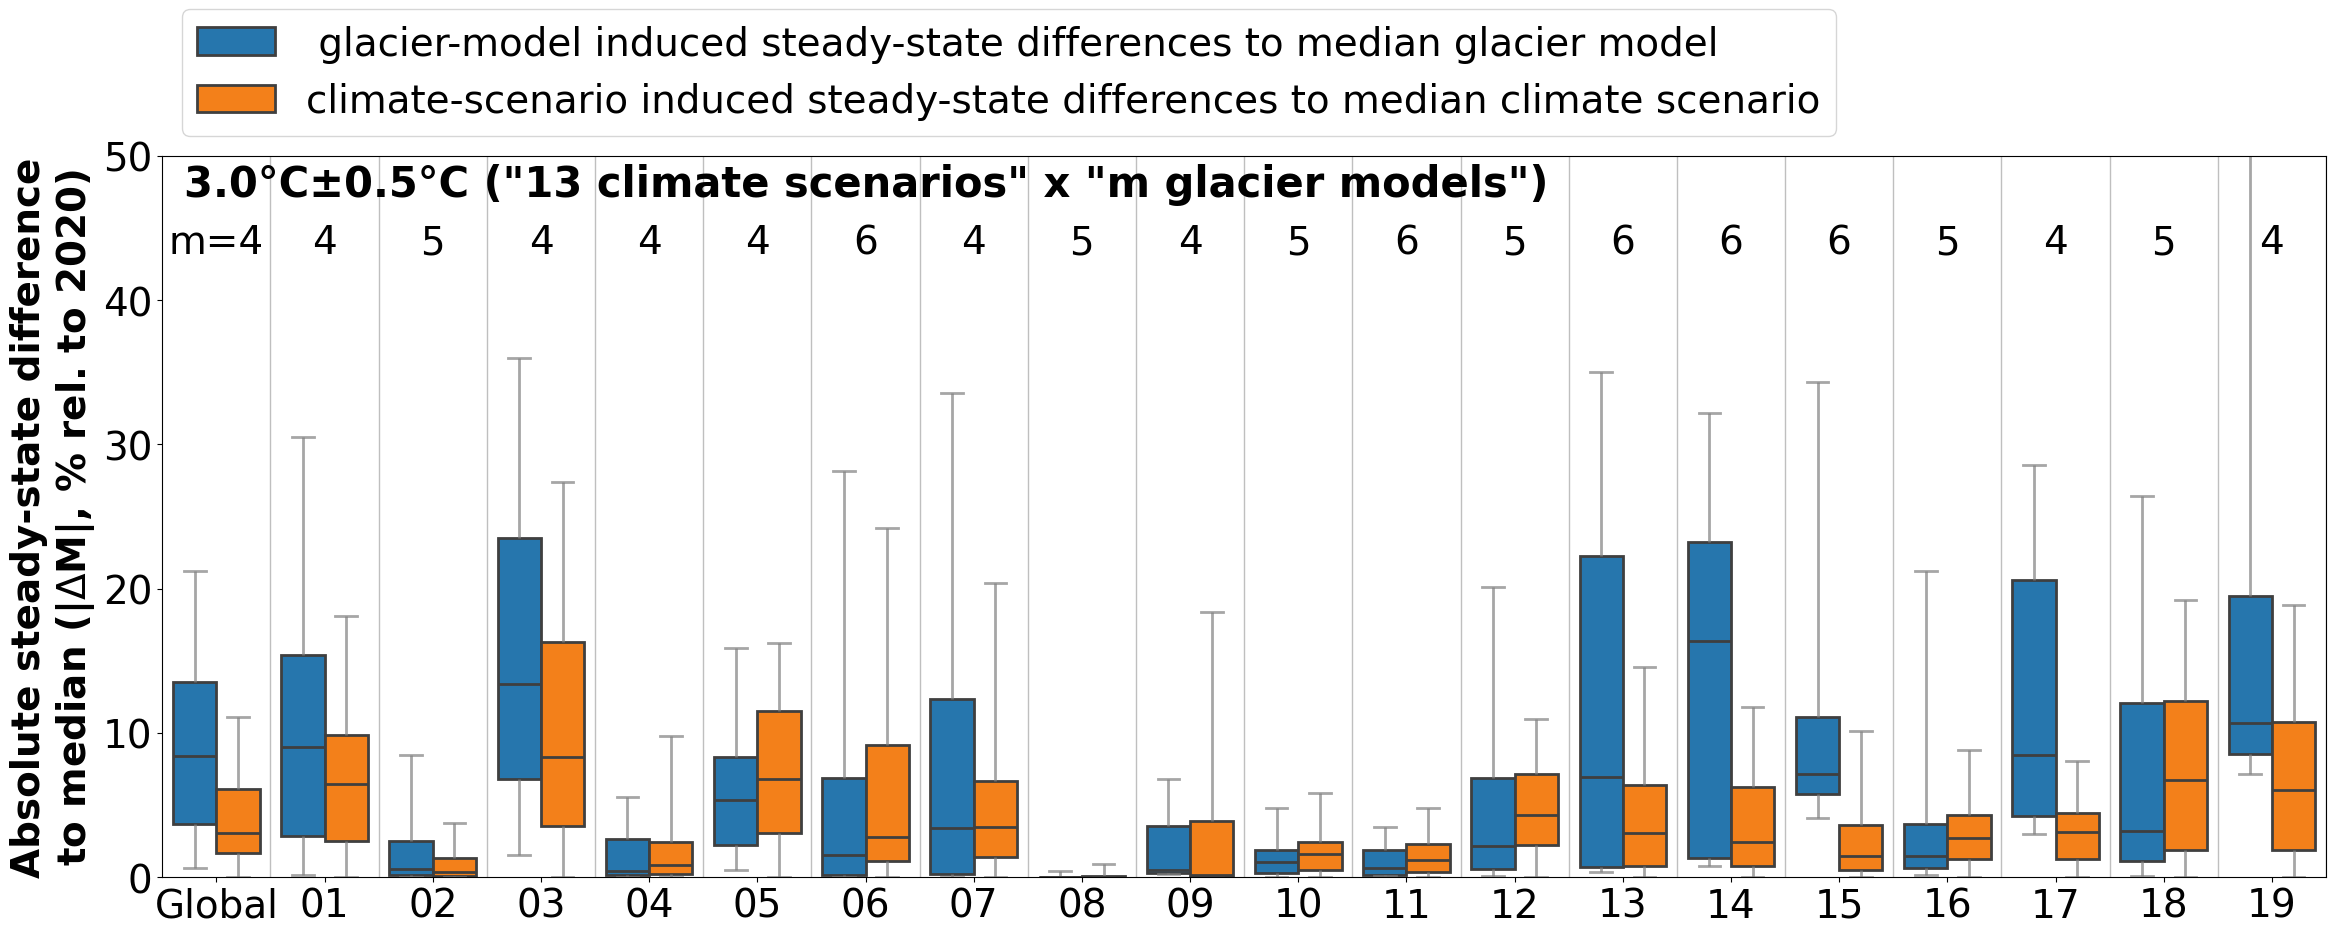

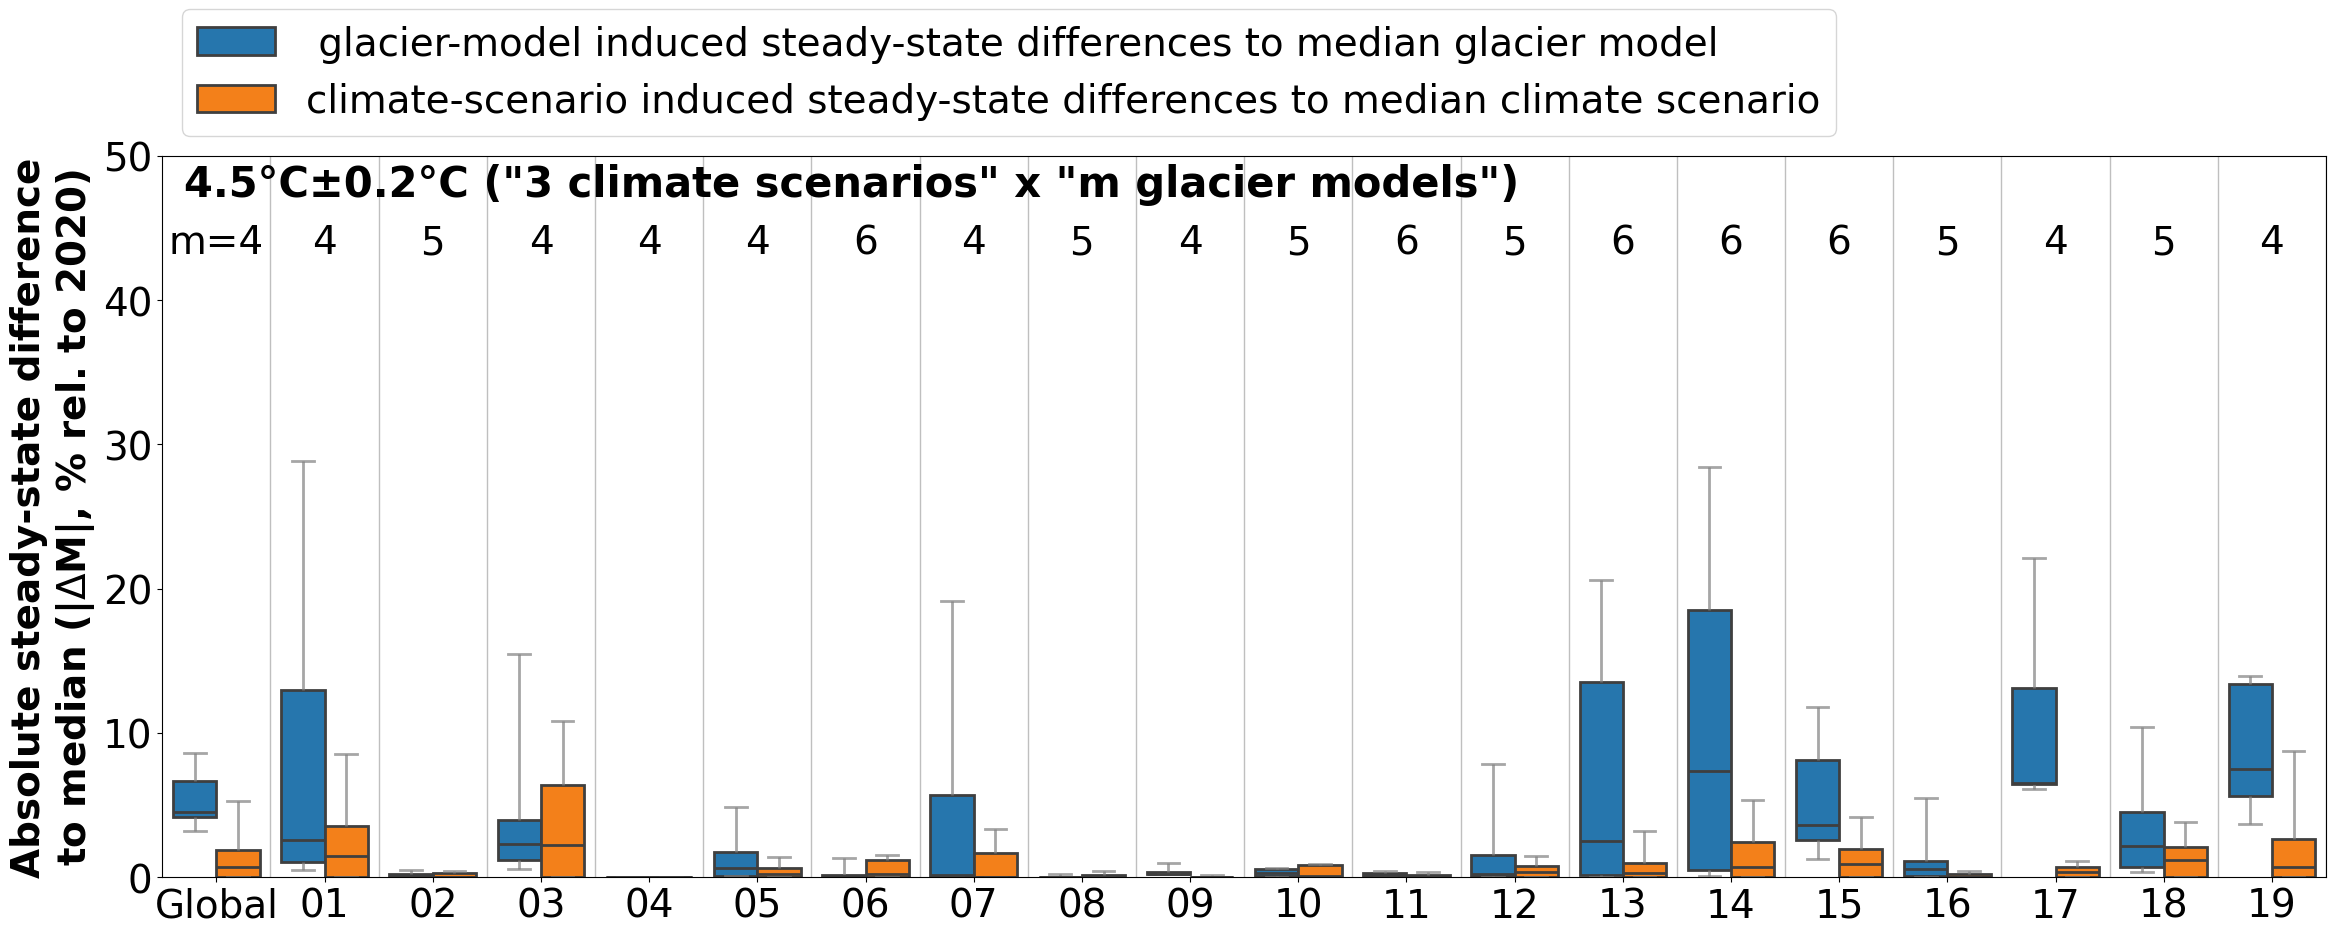

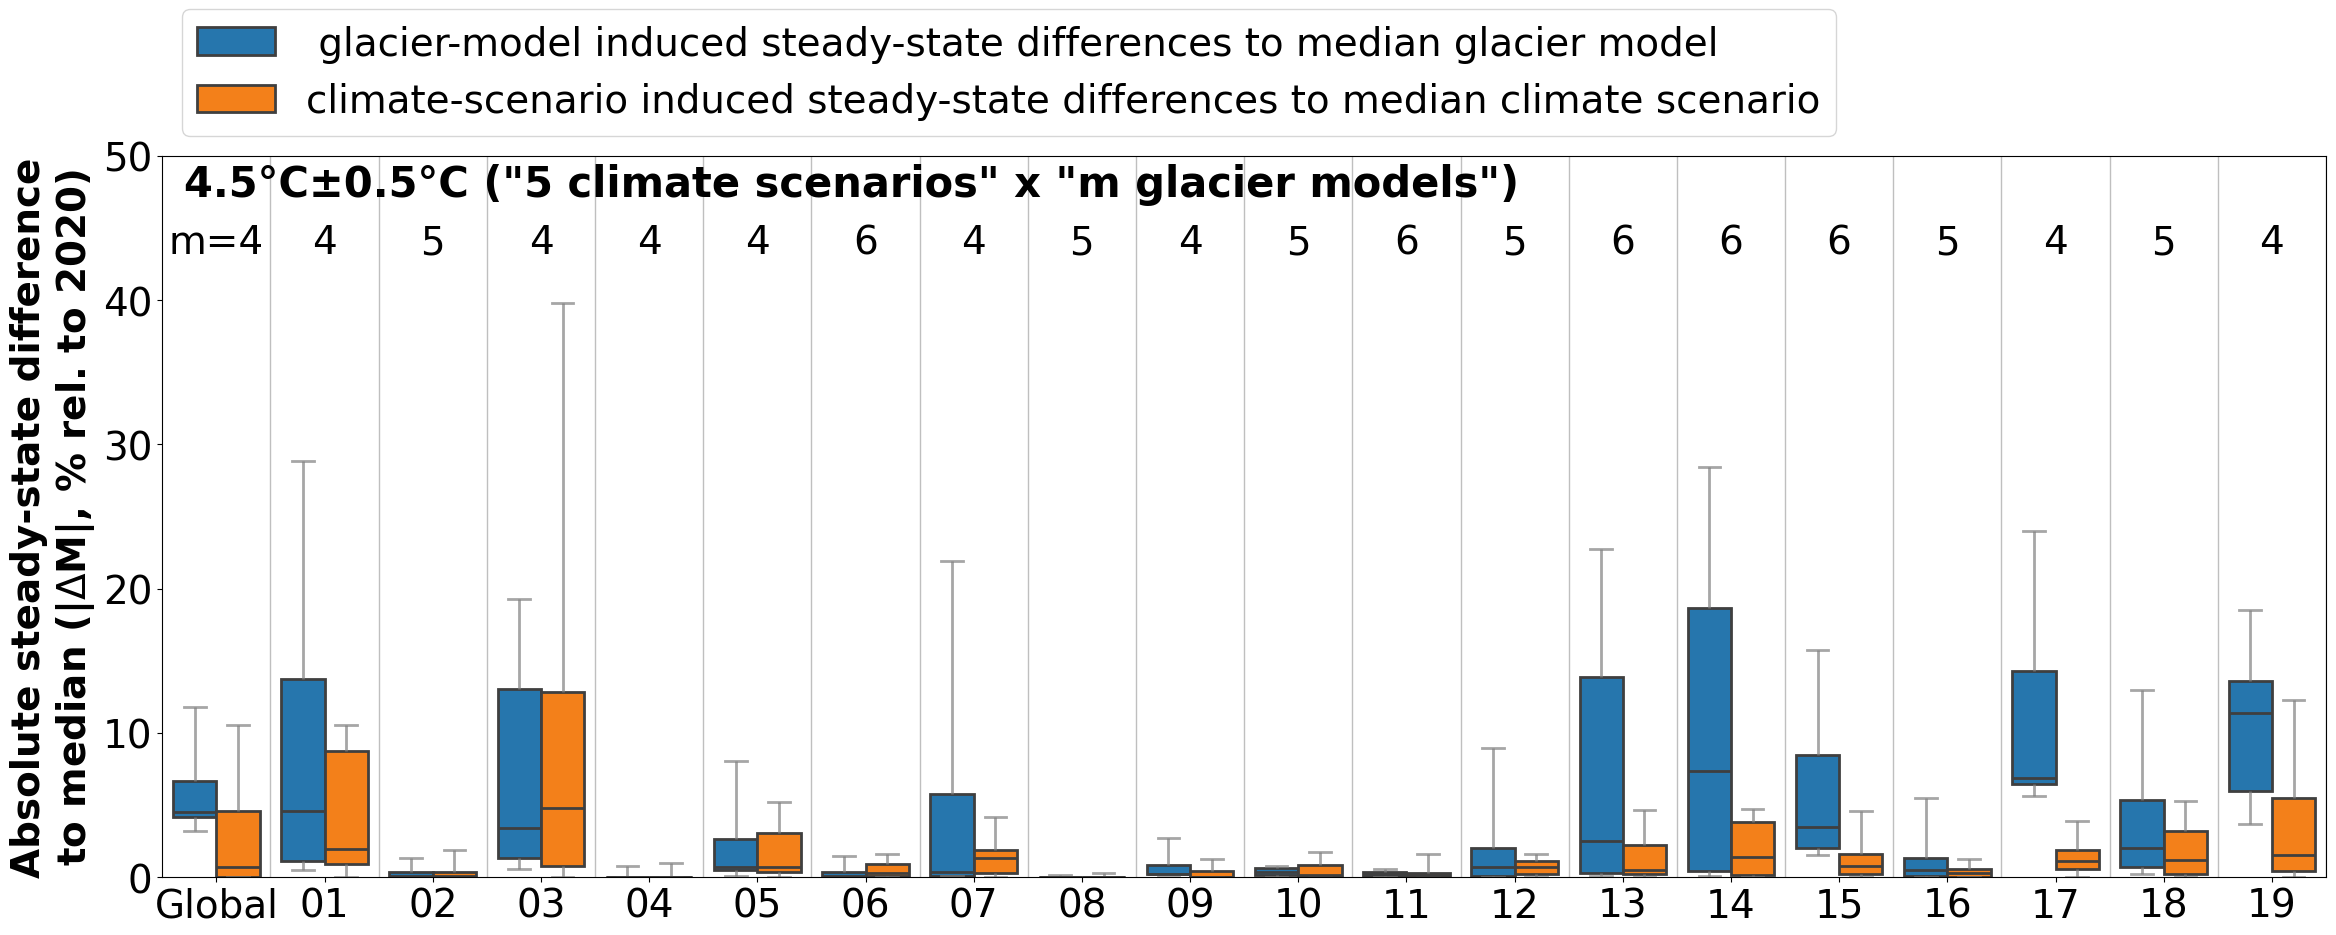

In [8]:
plt.rc('font', size=28)  


for temp in [0.0, 1.5, 3.0, 4.5]:
    for j,delta in enumerate([0.2, 0.5]): 
        plt.subplots(1,1,figsize=(24,10), sharey=True)
        _sel_temp = pd_reg_models_vol_5000.loc[(pd_reg_models_vol_5000.temp_ch_ipcc>=temp-delta) & 
                                            (pd_reg_models_vol_5000.temp_ch_ipcc<=temp+delta)]
        n = len(_sel_temp.groupby(['gcm','period_scenario']).count())
        print(delta, n, _sel_temp.groupby(['gcm','period_scenario'])['temp_ch_ipcc'].median().median())
        assert np.all(_sel_temp.groupby(['rgi_reg', 'model_author', 'temp_ch_ipcc']).count()==1)
        
        ds_sel_temp = _sel_temp.groupby(['rgi_reg', 'model_author',
                                      'temp_ch_ipcc'])[['relative volume change (in %)',
                                                         'delta relative volume change (in %, to median model)']].median().to_xarray()
        ds_sel_temp['delta relative volume change (in %, to median climate)'] = ds_sel_temp['relative volume change (in %)'] - ds_sel_temp['relative volume change (in %)'].median(dim='temp_ch_ipcc')
        
        ds_sel_temp[' glacier-model induced steady-state differences to median glacier model'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median model)'])
        ds_sel_temp['climate-scenario induced steady-state differences to median climate scenario'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median climate)'])
        _sel_temp = ds_sel_temp.to_dataframe().dropna()
        _sel_temp = _sel_temp.reset_index()
        _sel_temp_melt = _sel_temp.melt(id_vars=['rgi_reg', 'model_author', 'temp_ch_ipcc'],
                      value_vars=[' glacier-model induced steady-state differences to median glacier model',
                                  'climate-scenario induced steady-state differences to median climate scenario'])

        # Define custom sorting order
        custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
        # Create a categorical type with the custom order
        _sel_temp_melt['rgi_reg'] = pd.Categorical(_sel_temp_melt['rgi_reg'], categories=custom_order, ordered=True) 
        # Sort the DataFrame by the 'rgi_reg' column
        _sel_temp_melt = _sel_temp_melt.sort_values('rgi_reg').reset_index(drop=True)

        
        ax = plt.gca()
        y=f'delta relative volume change (in %, to median climate {temp}+/-{delta}°C)'
    
        xlim0=0#-35
        xlim1 = 50
        sns.boxplot(data=_sel_temp_melt,
                    ax = ax,
                    y='value',
                    x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
                    hue='variable', 
                    hue_order = [' glacier-model induced steady-state differences to median glacier model', 
                                 'climate-scenario induced steady-state differences to median climate scenario'],
                   fliersize=0, whis = [5,95], 
                          dodge = True, #hue='ssp',
                          #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
                    #y = 'time', #hue_order = ['2040', '2100'],
                    linewidth=2,
                    capprops={'color':'grey', 'alpha':0.7},
                    whiskerprops={'color':'grey', 'alpha':0.7},
                    saturation = 0.9,
                    #legend=False
                    #hue_order=_hue_order, palette=_pal_models,
                   )#legend = True)#legend=legend)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
        #_,xlim1 = ax.get_xlim()
        ax.set_ylim([xlim0,xlim1])
    
        ax.set_ylabel('Absolute steady-state difference\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)
    
    
        ax.set_xlabel('', fontsize=26)
        #for n in np.arange(xlim0+15,xlim1,20):
        #    ax.axhline(n, color='grey', ls=':', alpha = 0.5, lw=2)
        #ax.axhline(0, color='grey', ls=':', alpha = 1, lw=3)
        for vl in np.arange(0.5,20,1):
            ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
        #ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
        ax.text(0.01,0.99,f'{temp}°C±{delta}°C ("{n} climate scenarios" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
        _c = _sel_temp_melt.groupby(['rgi_reg','model_author'], observed=False)['value'].median().dropna().reset_index()
        _c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
        for j,c in enumerate(_c.values):
            if j ==0:
                ax.text(j,44,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
            else:
                ax.text(j,44,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
                
        plt.tight_layout()
        _temp = str(temp).replace('.','-')
        _delta = str(delta).replace('.','-')
        plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_scenario_induced_steady_stated_differences_{_temp}_delta{_delta}.png')
        plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_scenario_induced_steady_stated_differences_{_temp}_delta{_delta}.pdf')

In [9]:
_count_models = ds_sel_temp.to_dataframe().dropna().groupby(['model_author']).count()
global_models = list(_count_models.loc[_count_models['relative volume change (in %)']==100].index)
hue_order_global = []
pal_models_global = []
for h,p in zip(hue_order,pal_models):
    if h in global_models:
        hue_order_global.append(h)
        pal_models_global.append(p)

0.5 5 1.636714986028974
0.5 5 2.0912659163195166
0.5 5 1.9477879408841847


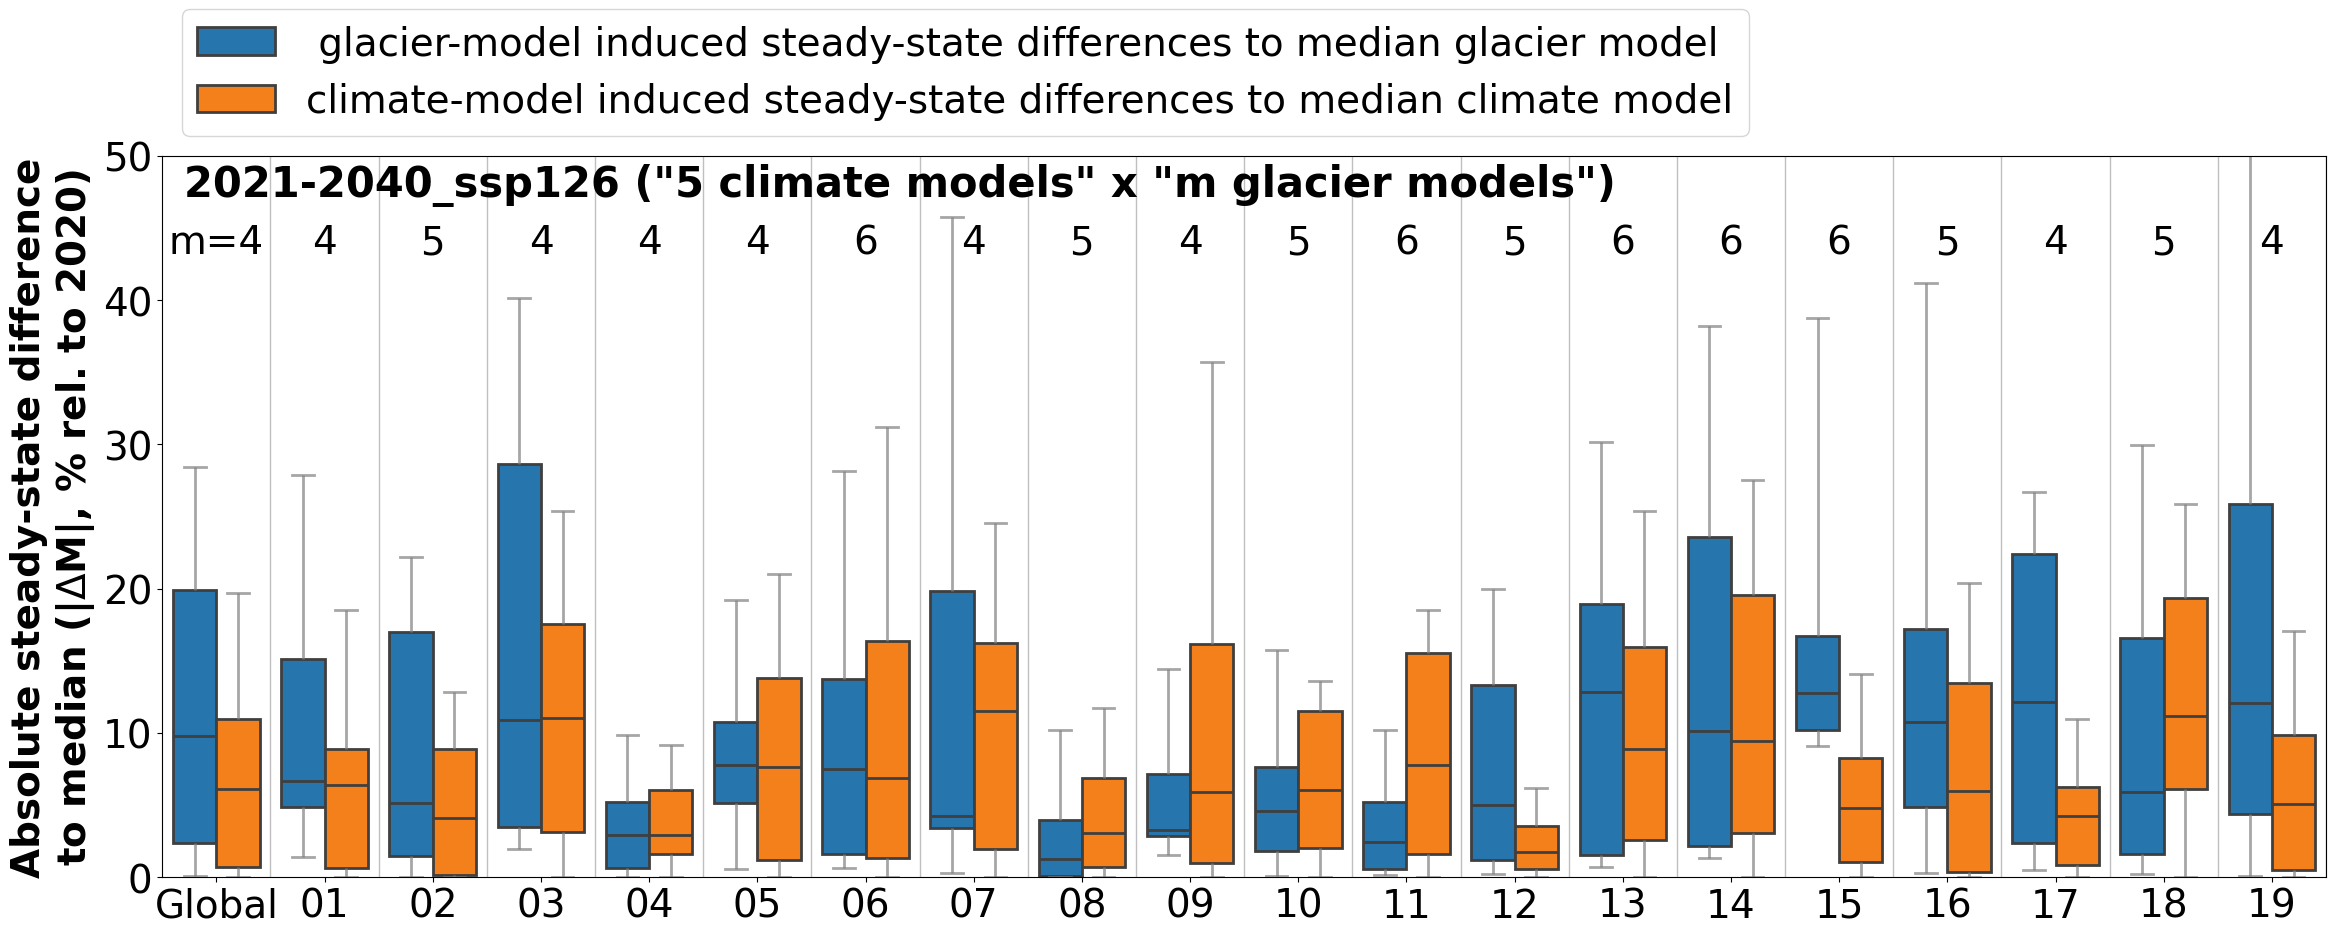

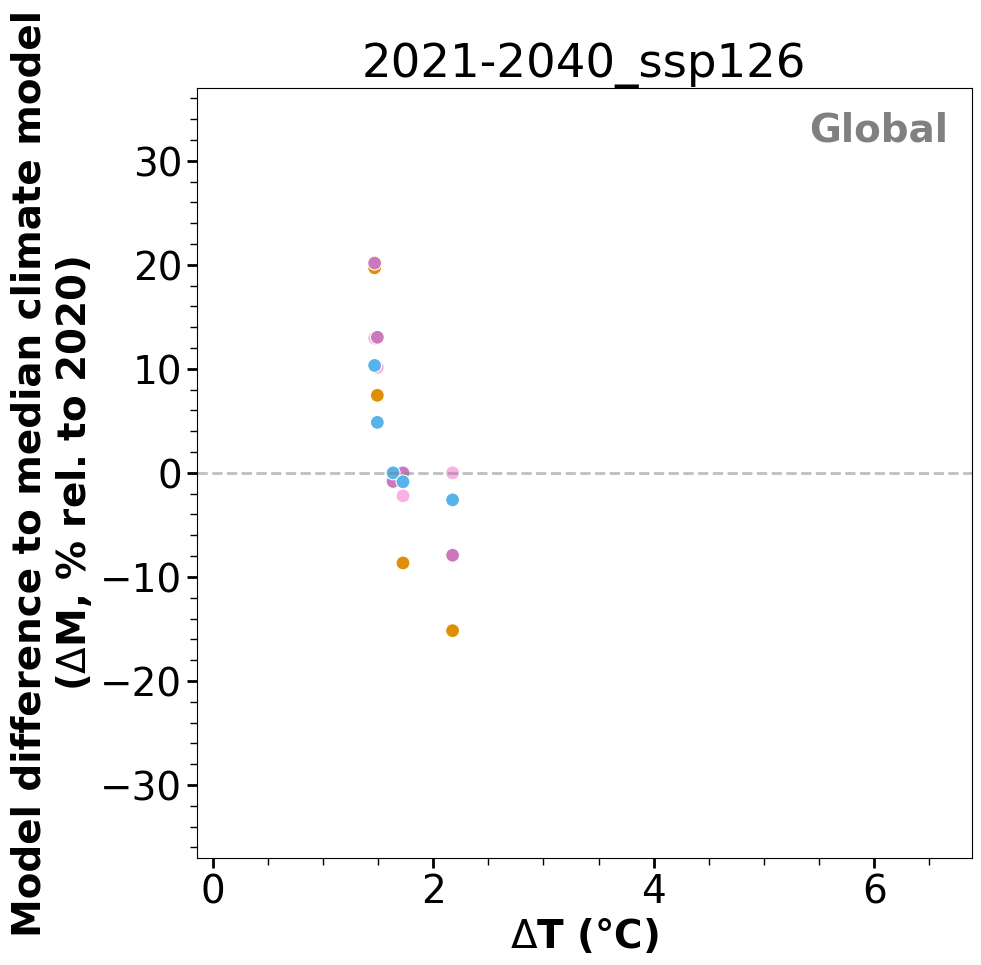

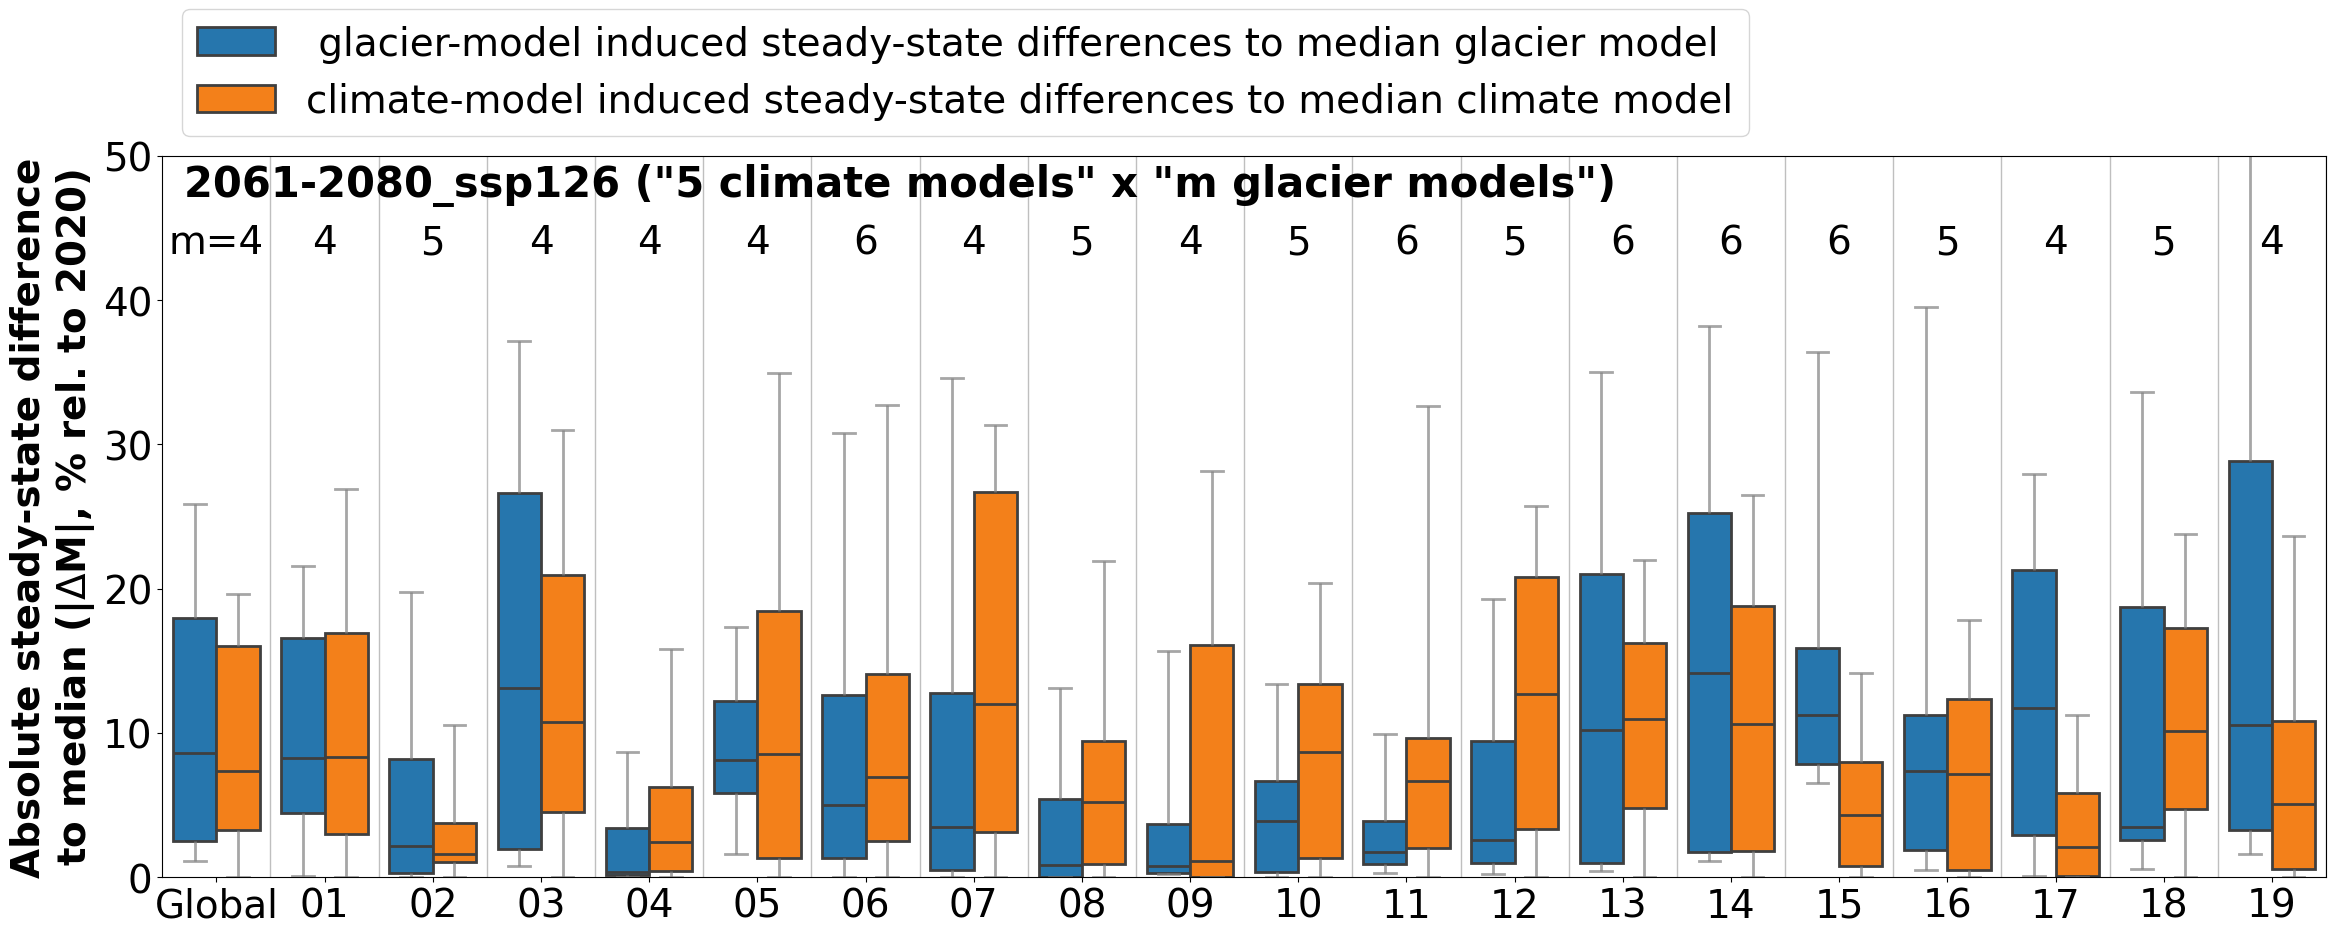

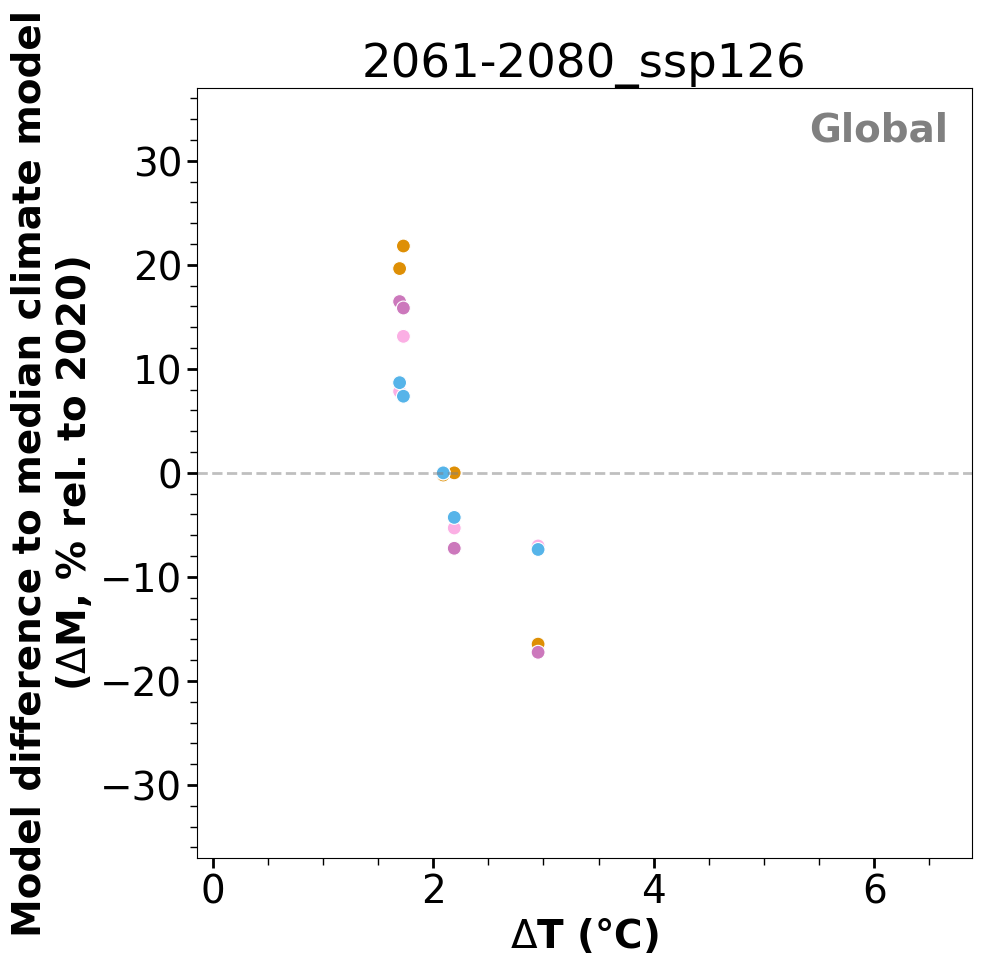

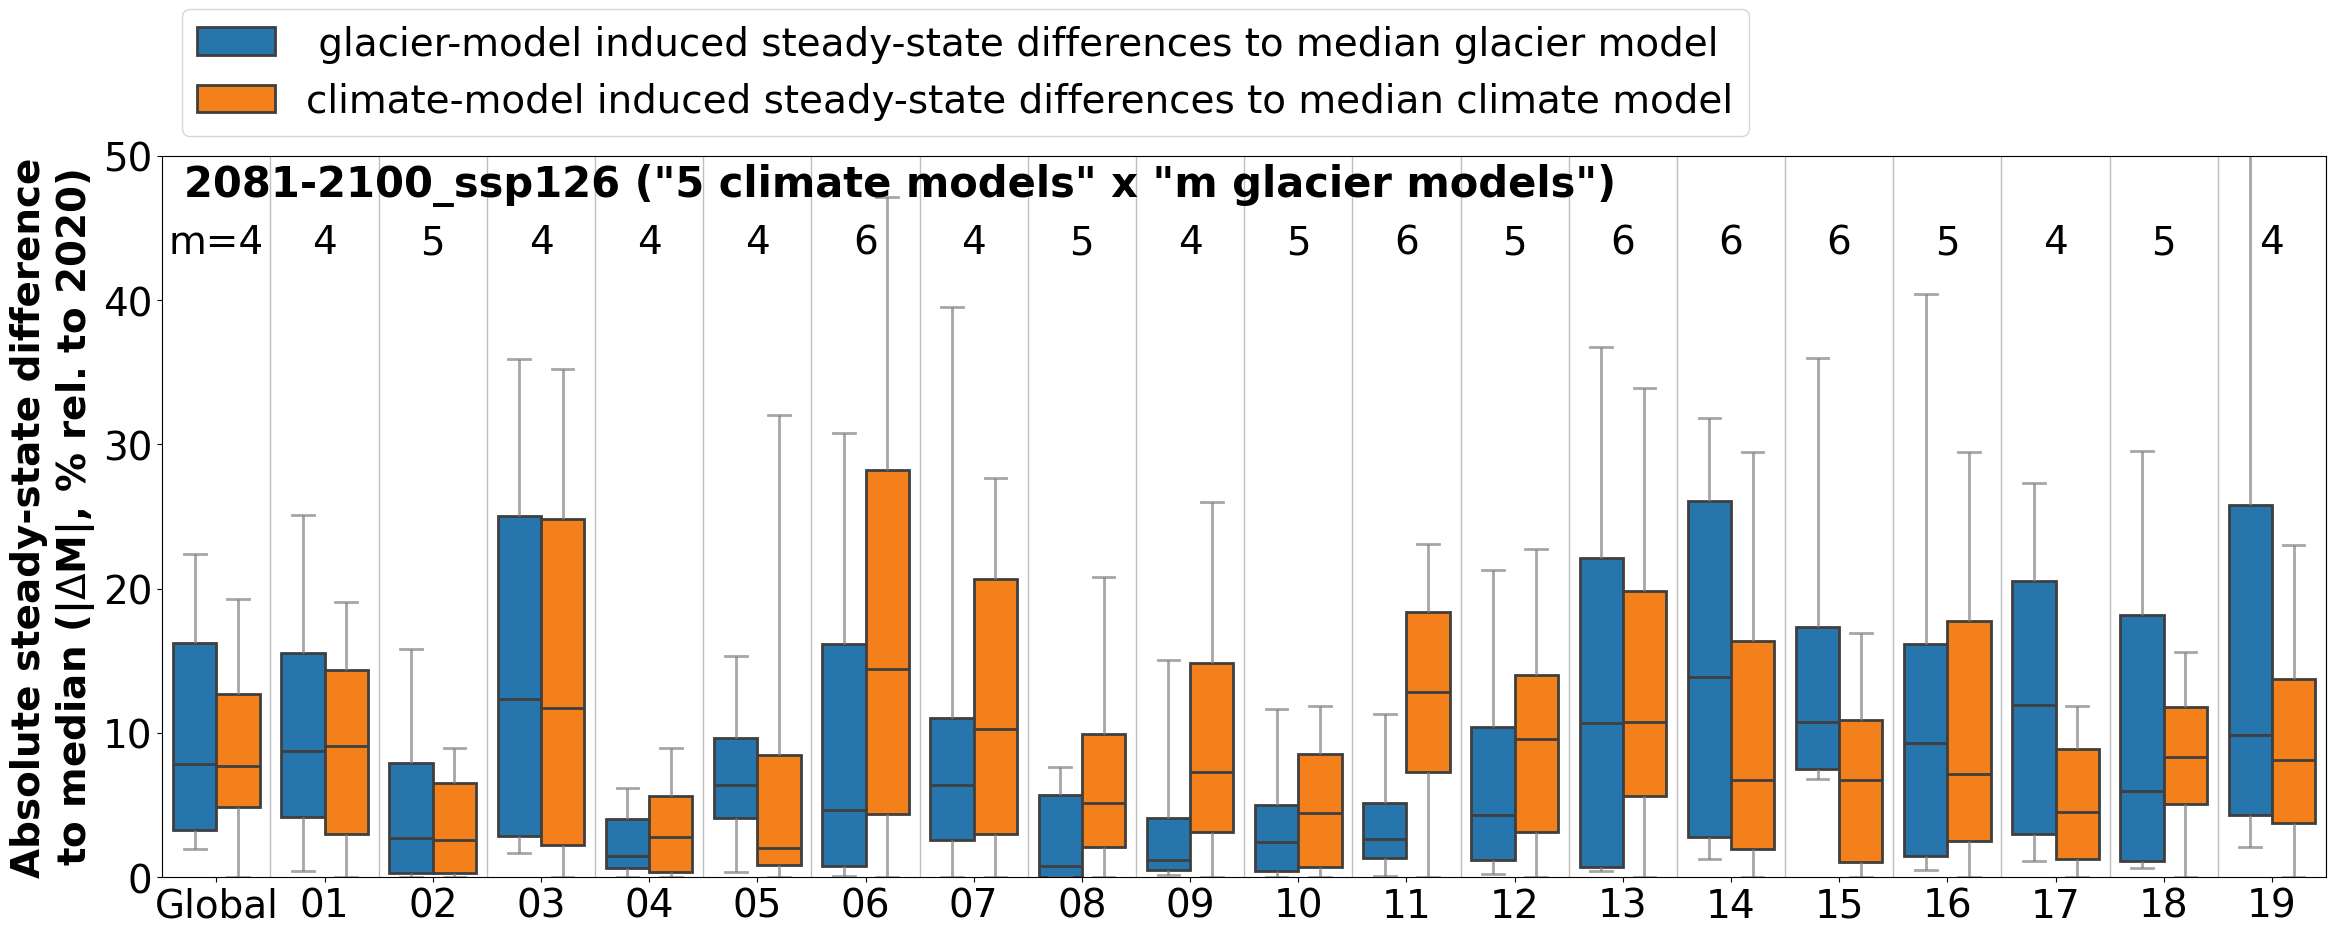

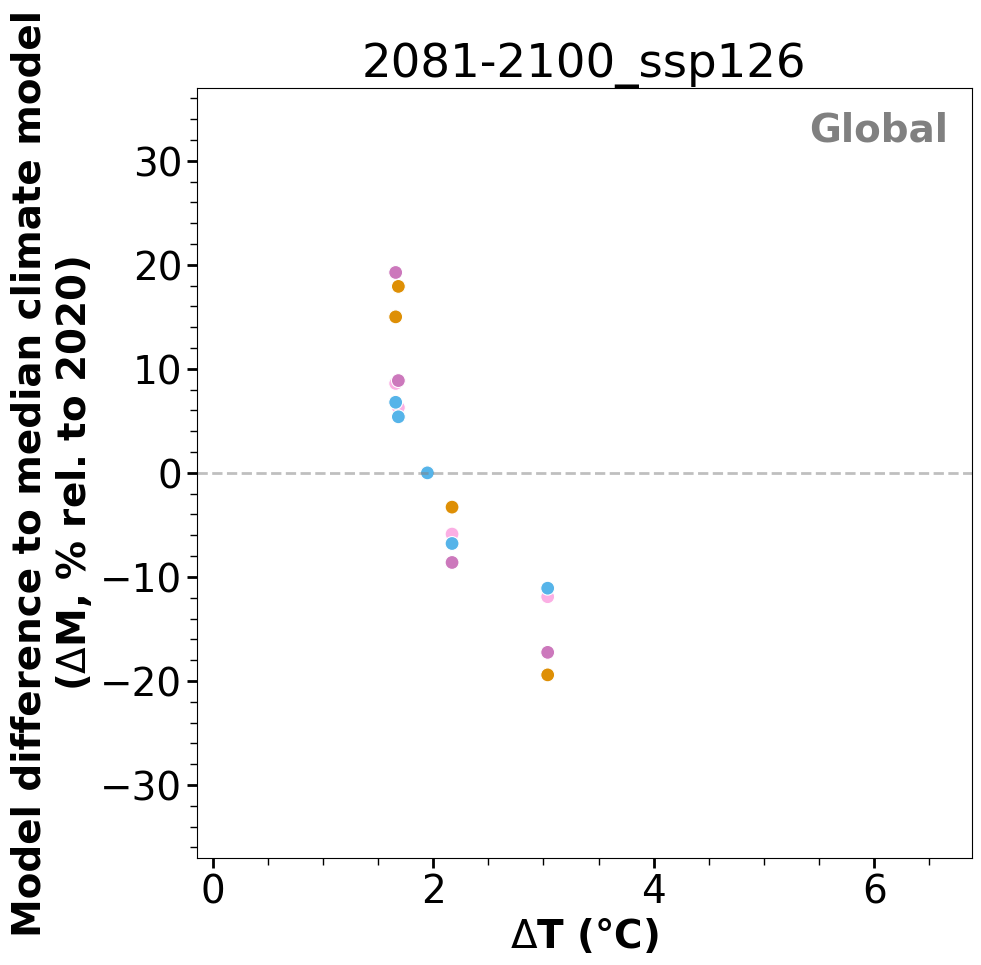

In [10]:
# select just one "period_scenario" for comparison...
for period_scenario in ['2021-2040_ssp126', '2061-2080_ssp126', '2081-2100_ssp126']:
    plt.subplots(1,1,figsize=(24,10), sharey=True)
    
    _sel_temp = pd_reg_models_vol_5000.loc[pd_reg_models_vol_5000.period_scenario==period_scenario]
    n = len(_sel_temp.groupby(['gcm','period_scenario']).count())
    print(delta, n, _sel_temp.groupby(['gcm','period_scenario'])['temp_ch_ipcc'].median().median())
    assert np.all(_sel_temp.groupby(['rgi_reg', 'model_author', 'temp_ch_ipcc']).count()==1)
    
    ds_sel_temp = _sel_temp.groupby(['rgi_reg', 'model_author',
                                  'temp_ch_ipcc'])[['relative volume change (in %)',
                                                     'delta relative volume change (in %, to median model)']].median().to_xarray()
    ds_sel_temp['delta relative volume change (in %, to median climate)'] = ds_sel_temp['relative volume change (in %)'] - ds_sel_temp['relative volume change (in %)'].median(dim='temp_ch_ipcc')
    
    ds_sel_temp[' glacier-model induced steady-state differences to median glacier model'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median model)'])
    ds_sel_temp['climate-model induced steady-state differences to median climate model'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median climate)'])
    _sel_temp = ds_sel_temp.to_dataframe().dropna()
    _sel_temp = _sel_temp.reset_index()
    _sel_temp_melt = _sel_temp.melt(id_vars=['rgi_reg', 'model_author', 'temp_ch_ipcc'],
                  value_vars=[' glacier-model induced steady-state differences to median glacier model',
                              'climate-model induced steady-state differences to median climate model'])
    
    # Define custom sorting order
    custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
    # Create a categorical type with the custom order
    _sel_temp_melt['rgi_reg'] = pd.Categorical(_sel_temp_melt['rgi_reg'], categories=custom_order, ordered=True) 
    # Sort the DataFrame by the 'rgi_reg' column
    _sel_temp_melt = _sel_temp_melt.sort_values('rgi_reg').reset_index(drop=True)
    
    
    ax = plt.gca()
    y=f'delta relative volume change (in %, to median climate {temp}+/-{delta}°C)'
    
    xlim0=0#-35
    xlim1 = 50
    sns.boxplot(data=_sel_temp_melt,
                ax = ax,
                y='value',
                x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
                hue='variable', 
                hue_order = [' glacier-model induced steady-state differences to median glacier model', 
                             'climate-model induced steady-state differences to median climate model'],
               fliersize=0, whis = [5,95], 
                      dodge = True, #hue='ssp',
                      #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
                #y = 'time', #hue_order = ['2040', '2100'],
                linewidth=2,
                capprops={'color':'grey', 'alpha':0.7},
                whiskerprops={'color':'grey', 'alpha':0.7},
                saturation = 0.9,
                #legend=False
                #hue_order=_hue_order, palette=_pal_models,
               )#legend = True)#legend=legend)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
    #_,xlim1 = ax.get_xlim()
    ax.set_ylim([xlim0,xlim1])
    
    ax.set_ylabel('Absolute steady-state difference\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)
    
    
    ax.set_xlabel('', fontsize=26)
    #for n in np.arange(xlim0+15,xlim1,20):
    #    ax.axhline(n, color='grey', ls=':', alpha = 0.5, lw=2)
    #ax.axhline(0, color='grey', ls=':', alpha = 1, lw=3)
    for vl in np.arange(0.5,20,1):
        ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
    #ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
    ax.text(0.01,0.99,f'{period_scenario} ("{n} climate models" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
    _c = _sel_temp_melt.groupby(['rgi_reg','model_author'], observed=False)['value'].median().dropna().reset_index()
    _c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
    for j,c in enumerate(_c.values):
        if j ==0:
            ax.text(j,44,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
        else:
            ax.text(j,44,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
            
    plt.tight_layout()
    plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_steady_stated_differences_{period_scenario}.png')
    plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_steady_stated_differences_{period_scenario}.pdf')

    rgi_reg = 'Global'


    if rgi_reg != 'Global':
        rgi_reg_long = f'{rgi_reg} - {d_reg_num_name[rgi_reg]}'
        _pal_models = pal_models
        _hue_order = hue_order
    else:
        rgi_reg_long = rgi_reg
        _pal_models = pal_models_global
        _hue_order = hue_order_global
    
    plt.subplots(1,1,figsize=(10,10)) #, sharey=True)
    ax1 = plt.gca()
    _d = ds_sel_temp['delta relative volume change (in %, to median climate)'].sel(rgi_reg=rgi_reg).to_dataframe().reset_index().dropna()
    
    sns.scatterplot(ax=ax1, data=_d, 
                    x='temp_ch_ipcc', y='delta relative volume change (in %, to median climate)',
                   hue='model_author', hue_order=_hue_order, palette=_pal_models, legend=True, s=100)
    handles, labels = ax1.get_legend_handles_labels()
    
    ax1.text(0.97,0.97, f'{rgi_reg_long}', ha='right', va='top', weight='bold',# spearman
                transform=ax1.transAxes, color='grey', fontsize=28)
    ax1.set_xlabel(r'$\Delta$T (°C)', weight='bold')
    ax1.set_ylabel('Model difference to median climate model\n'+r'($\Delta$M, % rel. to 2020)', weight='bold')
    
    ax1.axhline(0, ls='--', color='grey', lw=2, alpha = 0.5)
    ax1.tick_params(axis='both', which='major', width=2, length=7)
    ax1.tick_params(axis='both', which='minor', width=1, length=5)
    minorx_locator = MultipleLocator(1)  # 1° difference 
    ax1.xaxis.set_minor_locator(minorx_locator)
    minory_locator = MultipleLocator(10)  # 1° difference 
    ax1.yaxis.set_minor_locator(minory_locator)
    ax1.minorticks_on()
    ax1.set_xlim([pd_reg_models_vol_5000.temp_ch_ipcc.min(),
                  pd_reg_models_vol_5000.temp_ch_ipcc.max()])
    ax1.legend(handles, labels, loc='lower right', #bbox_to_anchor=(1,1), 
               ncol=1, fontsize=24);   
    ax1.legend().remove()
    plt.ylim([-37,37])
    plt.title(period_scenario)


**Plots just for presentation**

(-37.0, 37.0)

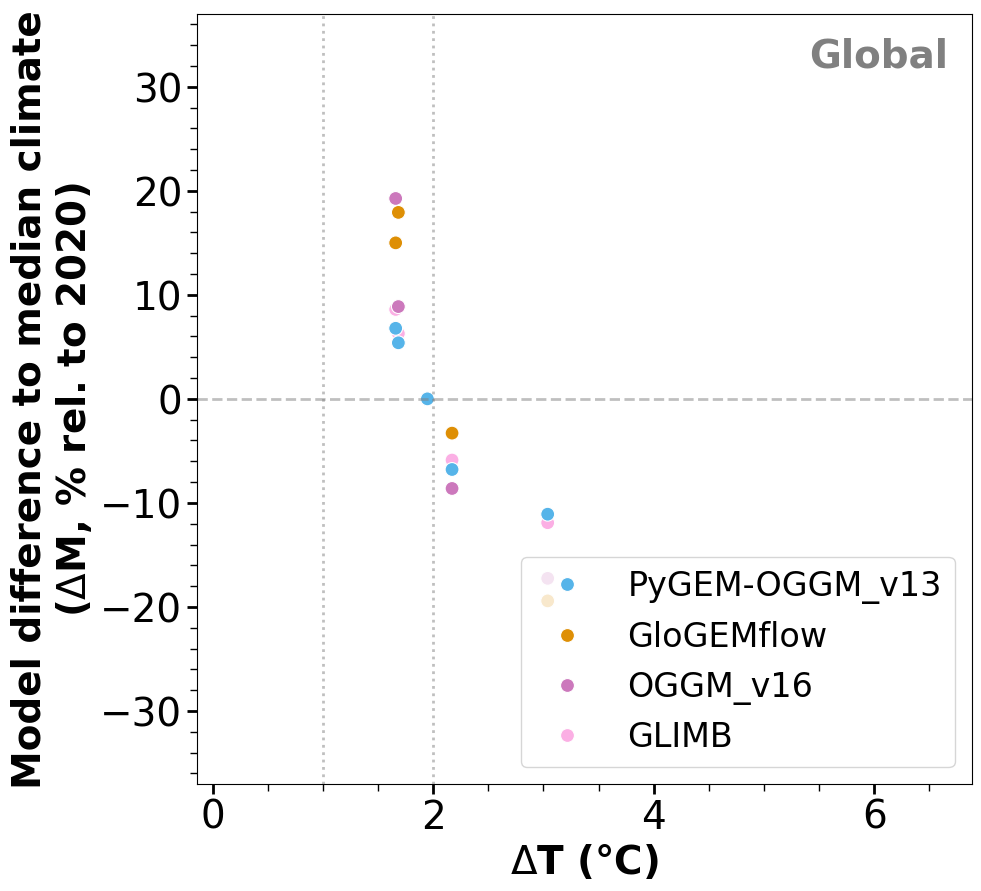

In [11]:
rgi_reg = 'Global'

if rgi_reg != 'Global':
    rgi_reg_long = f'{rgi_reg} - {d_reg_num_name[rgi_reg]}'
    _pal_models = pal_models
    _hue_order = hue_order
else:
    rgi_reg_long = rgi_reg
    _pal_models = pal_models_global
    _hue_order = hue_order_global

plt.subplots(1,1,figsize=(10,10))
ax1 = plt.gca()
_d = ds_sel_temp['delta relative volume change (in %, to median climate)'].sel(rgi_reg=rgi_reg).to_dataframe().reset_index().dropna()

sns.scatterplot(ax=ax1, data=_d, 
                x='temp_ch_ipcc', y='delta relative volume change (in %, to median climate)',
               hue='model_author', hue_order=_hue_order, palette=_pal_models, legend=True, s=100)
handles, labels = ax1.get_legend_handles_labels()

ax1.text(0.97,0.97, f'{rgi_reg_long}', ha='right', va='top', weight='bold', 
         transform=ax1.transAxes, color='grey', fontsize=28)
ax1.set_xlabel(r'$\Delta$T (°C)', weight='bold')
ax1.set_ylabel('Model difference to median climate\n'+r'($\Delta$M, % rel. to 2020)', weight='bold')

ax1.axhline(0, ls='--', color='grey', lw=2, alpha = 0.5)
ax1.tick_params(axis='both', which='major', width=2, length=7)
ax1.tick_params(axis='both', which='minor', width=1, length=5)
minorx_locator = MultipleLocator(1) 
ax1.xaxis.set_minor_locator(minorx_locator)
minory_locator = MultipleLocator(10)  
ax1.yaxis.set_minor_locator(minory_locator)
ax1.minorticks_on()
ax1.set_xlim([pd_reg_models_vol_5000.temp_ch_ipcc.min(), pd_reg_models_vol_5000.temp_ch_ipcc.max()])
ax1.axvline(1, ls=':', color='grey', lw=2, alpha = 0.5)
ax1.axvline(2, ls=':', color='grey', lw=2, alpha = 0.5)
ax1.legend(handles, labels, loc='lower right', 
           ncol=1, fontsize=24);   
plt.ylim([-37,37])


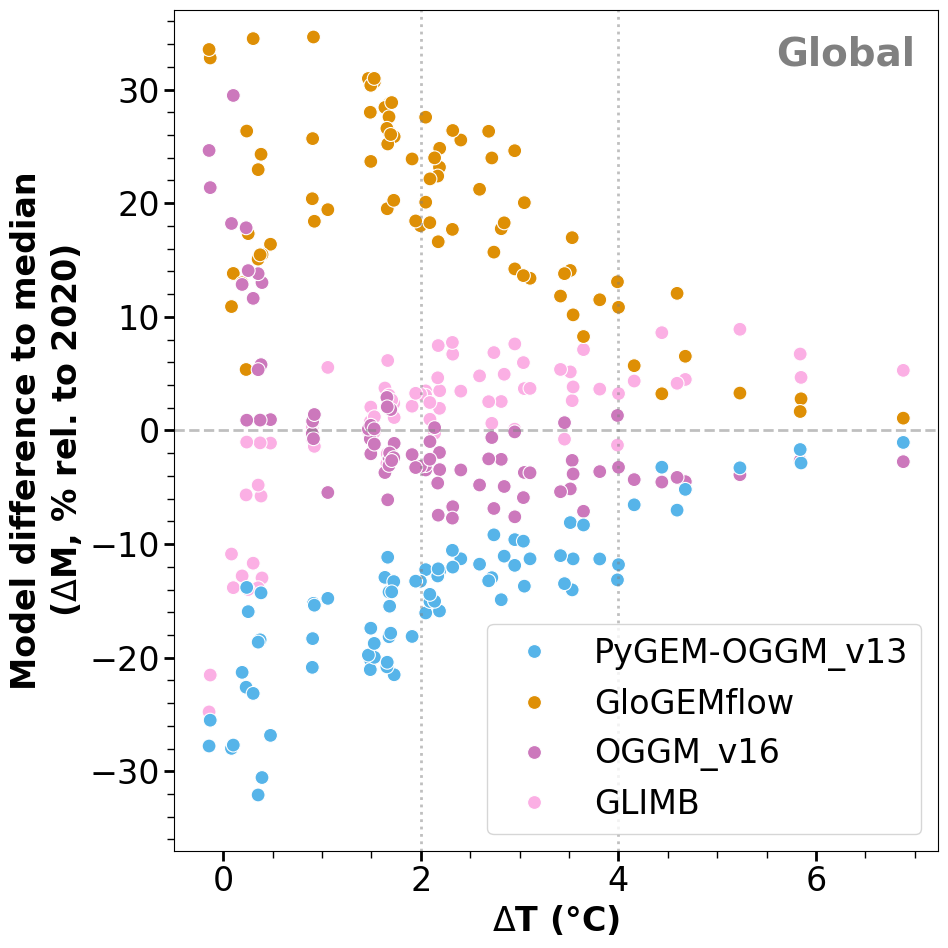

In [12]:
# todo... doble_check if _pd_vol definition is correct
_pd_vol = pd_reg_models_vol_5000.loc[pd_reg_models_vol_5000.rgi_reg == 'Global']

plt.rc('font', size=24)  
plt.figure(figsize=(10,10))
ax1= plt.gca()
for j,rgi_reg in enumerate(['Global']):
    sns.scatterplot(ax= ax1, data=_pd_vol, 
                x='temp_ch_ipcc', y='delta relative volume change (in %, to median model)',
               hue='model_author', hue_order=_hue_order, palette=_pal_models, legend=True, s=100)
    handles, labels = ax1.get_legend_handles_labels()

    ax1.text(0.97,0.97, f'{rgi_reg_long}', ha='right', va='top', weight='bold',# spearman
                transform=ax1.transAxes, color='grey', fontsize=28)
    ax1.set_xlabel(r'$\Delta$T (°C)', weight='bold')
    ax1.set_ylabel('Model difference to median\n'+r'($\Delta$M, % rel. to 2020)', weight='bold')

    ax1.axhline(0, ls='--', color='grey', lw=2, alpha = 0.5)
    ax1.tick_params(axis='both', which='major', width=2, length=7)
    ax1.tick_params(axis='both', which='minor', width=1, length=5)
    minorx_locator = MultipleLocator(1)  # 1° difference 
    ax1.xaxis.set_minor_locator(minorx_locator)
    minory_locator = MultipleLocator(10)  # 1° difference 
    ax1.yaxis.set_minor_locator(minory_locator)
    ax1.minorticks_on()
    ax1.axvline(2, ls=':', color='grey', lw=2, alpha = 0.5)
    ax1.axvline(4, ls=':', color='grey', lw=2, alpha = 0.5)
plt.tight_layout()
ax1.legend(handles, labels, loc='lower right', #bbox_to_anchor=(1,1), 
           ncol=1, fontsize=24);   
plt.ylim([-37,37])
plt.savefig('figures_partB/glacier_model_ss_differences/steady_state_vol_diff_median_glob_reg_scatterplot_vs_deltaT_only_global.png')

## Same for just after 80 years

In [13]:
pd_reg_models_vol_all_80 = pd.read_csv('PartB_data/after80yrs_relative_volume_change.csv', index_col=[0])

In [14]:
_sel_temp_melt

,rgi_reg,model_author,temp_ch_ipcc,variable,value
0,Global,PyGEM-OGGM_v13,3.038482,glacier-model induced steady-state difference...,9.744234
1,Global,PyGEM-OGGM_v13,1.947788,glacier-model induced steady-state difference...,13.265832
2,Global,PyGEM-OGGM_v13,1.684476,glacier-model induced steady-state difference...,15.466481
3,Global,PyGEM-OGGM_v13,1.659996,glacier-model induced steady-state difference...,20.401065
4,Global,OGGM_v16,3.038482,glacier-model induced steady-state difference...,5.910967
...,...,...,...,...,...
955,19,OGGM_v16,3.038482,climate-model induced steady-state differences...,0.000000
956,19,PyGEM-OGGM_v13,1.659996,climate-model induced steady-state differences...,5.384165
957,19,PyGEM-OGGM_v13,1.684476,climate-model induced steady-state differences...,9.130548
958,19,GloGEMflow,1.947788,climate-model induced steady-state differences...,12.146593


0.5 5 0.1909476951352631
0.5 5 0.2524779717488781
0.5 5 0.3530089022449858
0.5 5 0.913313145803356
0.5 5 1.636714986028974
0.5 5 1.6781632715811343
0.5 5 1.664909941388102
0.5 5 1.996245046811256
0.5 5 2.404955505633247
0.5 5 2.687006726396547
0.5 5 2.0912659163195166
0.5 5 3.105613246951532
0.5 5 3.541685753482952
0.5 5 1.9477879408841847
0.5 5 3.811452139882864
0.5 5 4.5943250252311145


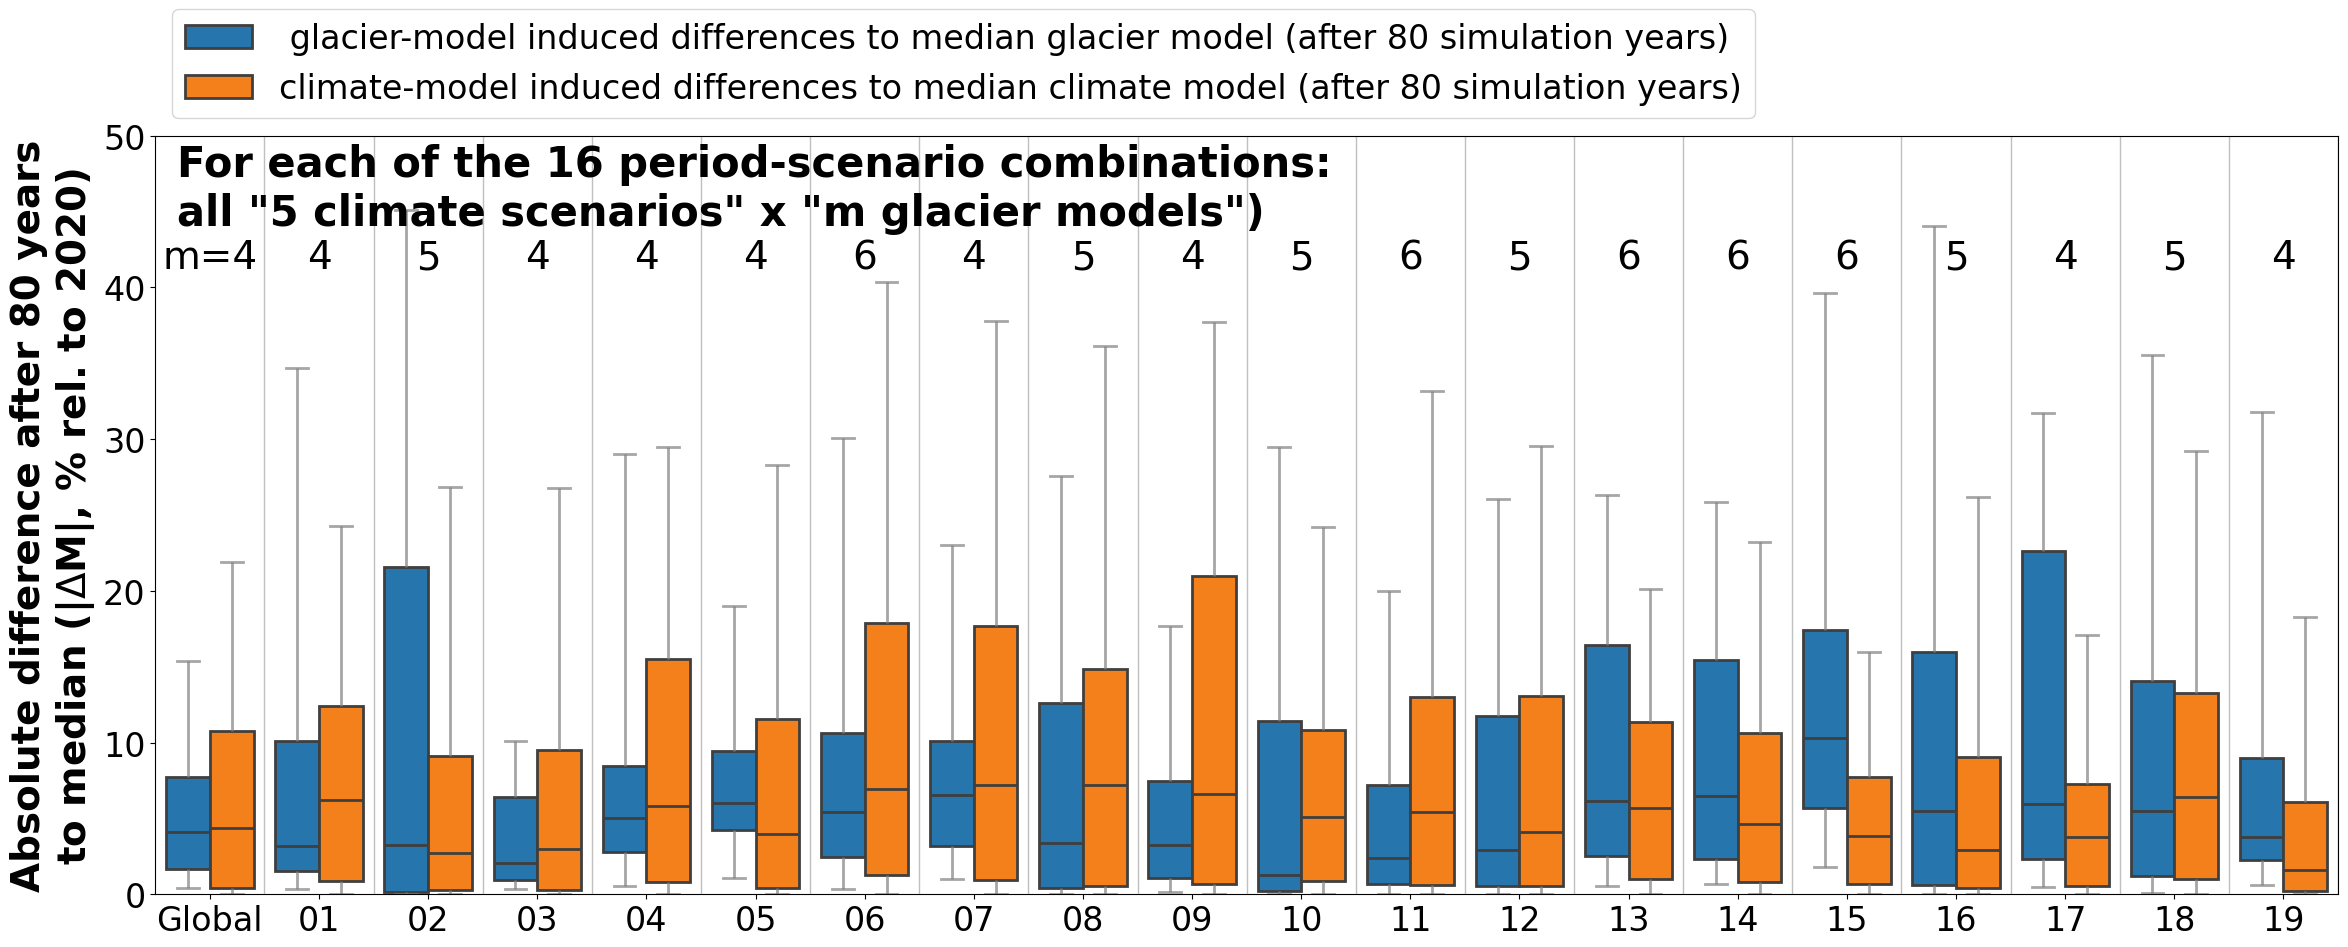

In [15]:

# select just one "period_scenario" for comparison...
#for period_scenario in ['2021-2040_ssp126', '2061-2080_ssp126', '2081-2100_ssp126']:
plt.subplots(1,1,figsize=(24,10), sharey=True)
_sel_temp_melt_l = []
for period_scenario in pd_reg_models_vol_all_80.period_scenario.unique():
    _sel_temp = pd_reg_models_vol_all_80.loc[pd_reg_models_vol_all_80.period_scenario==period_scenario]
    n = len(_sel_temp.groupby(['gcm','period_scenario']).count())
    print(delta, n, _sel_temp.groupby(['gcm','period_scenario'])['temp_ch_ipcc'].median().median())
    assert np.all(_sel_temp.groupby(['rgi_reg', 'model_author', 'temp_ch_ipcc']).count()==1)
    
    ds_sel_temp = _sel_temp.groupby(['rgi_reg', 'model_author',
                                  'temp_ch_ipcc'])[['relative volume change (in %)',
                                                     'delta relative volume change (in %, to median model)']].median().to_xarray()
    ds_sel_temp['delta relative volume change (in %, to median climate)'] = ds_sel_temp['relative volume change (in %)'] - ds_sel_temp['relative volume change (in %)'].median(dim='temp_ch_ipcc')
    
    ds_sel_temp[' glacier-model induced differences to median glacier model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median model)'])
    ds_sel_temp['climate-model induced differences to median climate model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median climate)'])
    _sel_temp = ds_sel_temp.to_dataframe().dropna()
    _sel_temp = _sel_temp.reset_index()
    _sel_temp_melt_ps = _sel_temp.melt(id_vars=['rgi_reg', 'model_author', 'temp_ch_ipcc'],
                  value_vars=[' glacier-model induced differences to median glacier model (after 80 simulation years)',
                              'climate-model induced differences to median climate model (after 80 simulation years)'])
    _sel_temp_melt_ps['period_scenario'] = period_scenario
    _sel_temp_melt_l.append(_sel_temp_melt_ps)
_sel_temp_melt = pd.concat(_sel_temp_melt_l)
# Define custom sorting order
custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
# Create a categorical type with the custom order
_sel_temp_melt['rgi_reg'] = pd.Categorical(_sel_temp_melt['rgi_reg'], categories=custom_order, ordered=True) 
# Sort the DataFrame by the 'rgi_reg' column
_sel_temp_melt = _sel_temp_melt.sort_values('rgi_reg').reset_index(drop=True)


ax = plt.gca()
y=f'delta relative volume change (in %, to median climate {temp}+/-{delta}°C)'

xlim0=0#-35
xlim1 = 50
sns.boxplot(data=_sel_temp_melt,
            ax = ax,
            y='value',
            x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
            hue='variable', 
            hue_order = [' glacier-model induced differences to median glacier model (after 80 simulation years)', 
                         'climate-model induced differences to median climate model (after 80 simulation years)'],
           fliersize=0, whis = [5,95], 
                  dodge = True, #hue='ssp',
                  #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
            #y = 'time', #hue_order = ['2040', '2100'],
            linewidth=2,
            capprops={'color':'grey', 'alpha':0.7},
            whiskerprops={'color':'grey', 'alpha':0.7},
            saturation = 0.9,
            #legend=False
            #hue_order=_hue_order, palette=_pal_models,
           )#legend = True)#legend=legend)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
#_,xlim1 = ax.get_xlim()
ax.set_ylim([xlim0,xlim1])

ax.set_ylabel('Absolute difference after 80 years\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)


ax.set_xlabel('', fontsize=26)
#for n in np.arange(xlim0+15,xlim1,20):
#    ax.axhline(n, color='grey', ls=':', alpha = 0.5, lw=2)
#ax.axhline(0, color='grey', ls=':', alpha = 1, lw=3)
for vl in np.arange(0.5,20,1):
    ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
#ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
ax.text(0.01,0.99,f'For each of the 16 period-scenario combinations:\nall "{n} climate scenarios" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
_c = _sel_temp_melt.groupby(['rgi_reg','model_author'], observed=False)['value'].median().dropna().reset_index()
_c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
for j,c in enumerate(_c.values):
    if j ==0:
        ax.text(j,42,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
    else:
        ax.text(j,42,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
        
plt.tight_layout()
plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_differences_after_80years_all_period_scenarios_separately.png')
plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_differences_after_80years_all_period_scenarios_separately.pdf')


0.5 5 1.664909941388102
0.5 5 1.996245046811256
0.5 5 2.404955505633247
0.5 5 2.687006726396547
0.5 5 2.0912659163195166
0.5 5 3.105613246951532
0.5 5 3.541685753482952
0.5 5 1.9477879408841847
0.5 5 3.811452139882864
0.5 5 4.5943250252311145


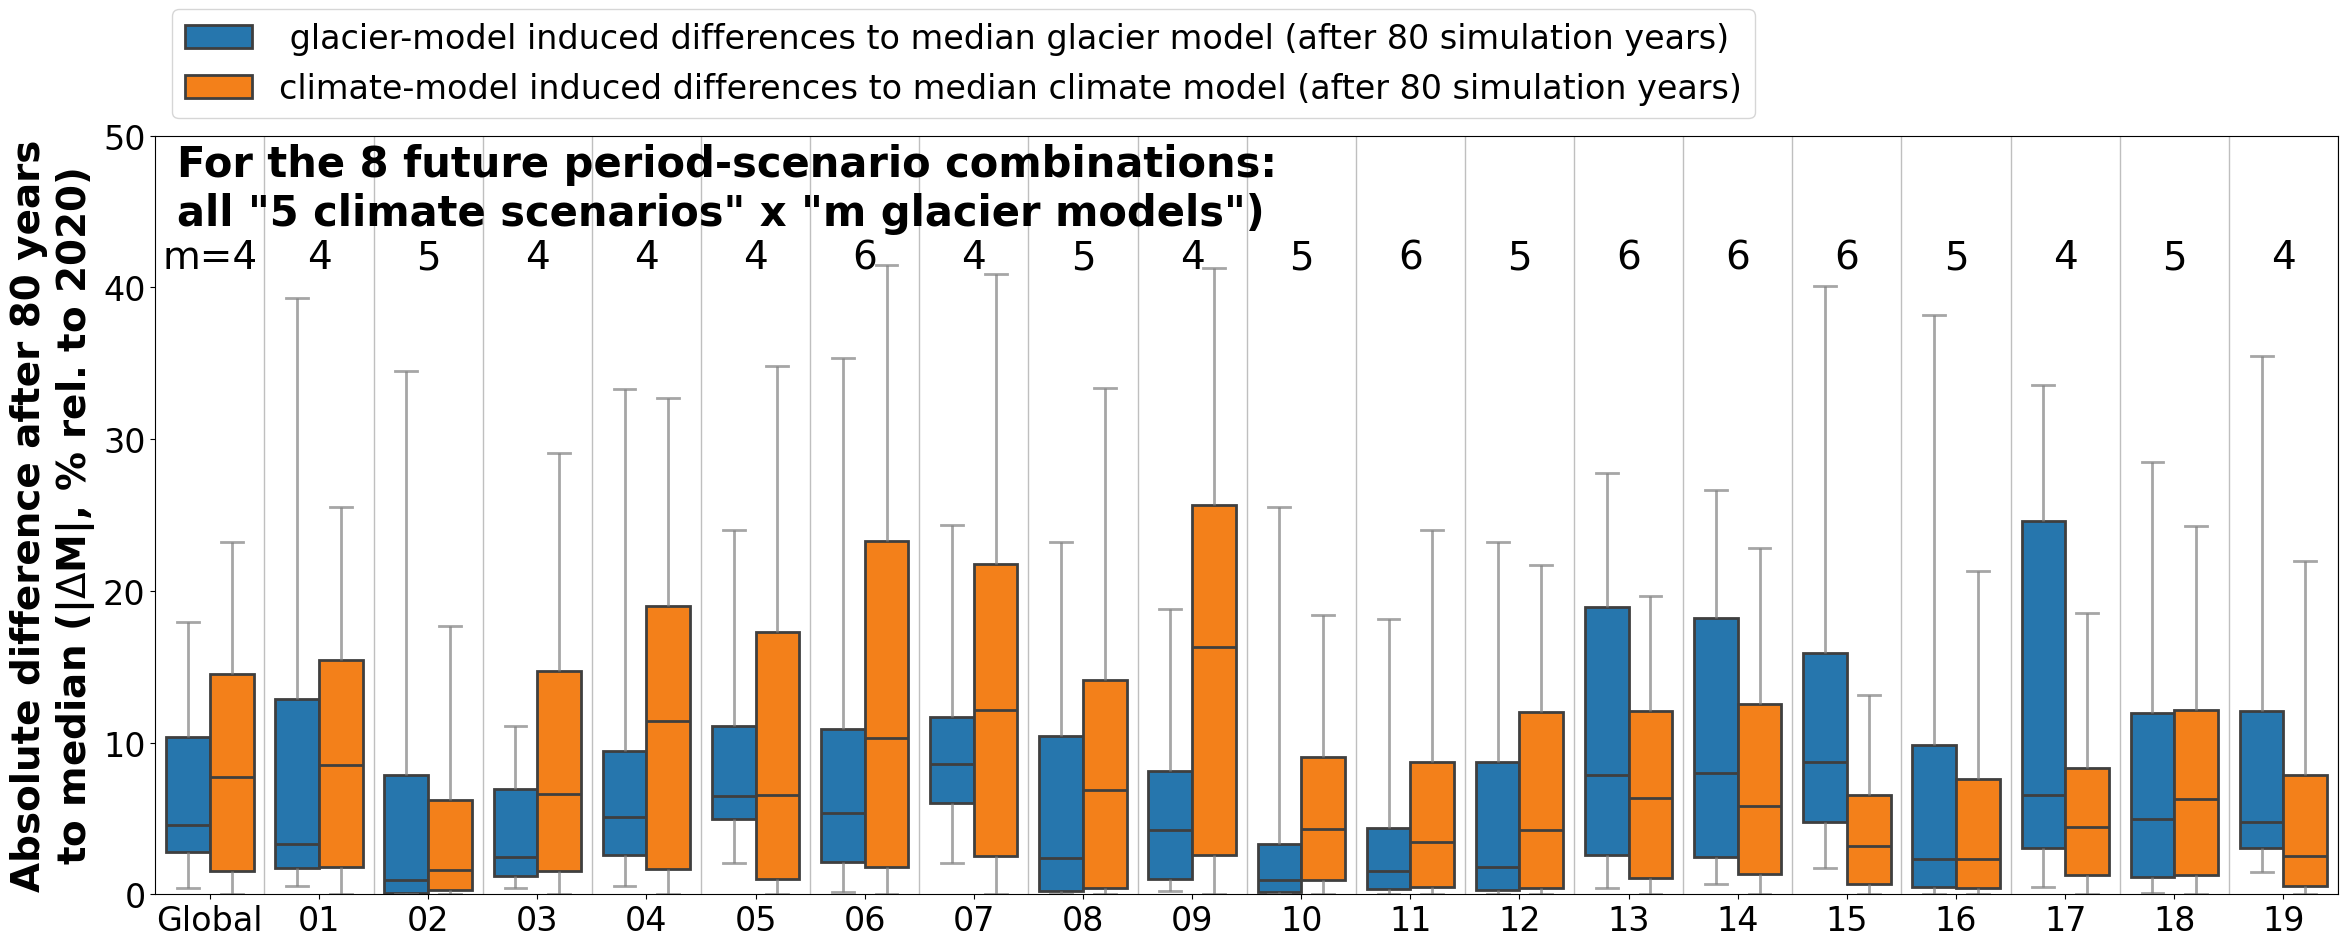

In [16]:

# select just one "period_scenario" for comparison...
#for period_scenario in ['2021-2040_ssp126', '2061-2080_ssp126', '2081-2100_ssp126']:
plt.subplots(1,1,figsize=(24,10), sharey=True)
_sel_temp_melt_l = []
for period_scenario in ['2021-2040_ssp585', '2041-2060_ssp126', '2041-2060_ssp370',
       '2041-2060_ssp585', '2061-2080_ssp126', '2061-2080_ssp370',
       '2061-2080_ssp585', '2081-2100_ssp126', '2081-2100_ssp370',
       '2081-2100_ssp585']:
    _sel_temp = pd_reg_models_vol_all_80.loc[pd_reg_models_vol_all_80.period_scenario==period_scenario]
    n = len(_sel_temp.groupby(['gcm','period_scenario']).count())
    print(delta, n, _sel_temp.groupby(['gcm','period_scenario'])['temp_ch_ipcc'].median().median())
    assert np.all(_sel_temp.groupby(['rgi_reg', 'model_author', 'temp_ch_ipcc']).count()==1)
    
    ds_sel_temp = _sel_temp.groupby(['rgi_reg', 'model_author',
                                  'temp_ch_ipcc'])[['relative volume change (in %)',
                                                     'delta relative volume change (in %, to median model)']].median().to_xarray()
    ds_sel_temp['delta relative volume change (in %, to median climate)'] = ds_sel_temp['relative volume change (in %)'] - ds_sel_temp['relative volume change (in %)'].median(dim='temp_ch_ipcc')
    
    ds_sel_temp[' glacier-model induced differences to median glacier model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median model)'])
    ds_sel_temp['climate-model induced differences to median climate model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median climate)'])
    _sel_temp = ds_sel_temp.to_dataframe().dropna()
    _sel_temp = _sel_temp.reset_index()
    _sel_temp_melt_ps = _sel_temp.melt(id_vars=['rgi_reg', 'model_author', 'temp_ch_ipcc'],
                  value_vars=[' glacier-model induced differences to median glacier model (after 80 simulation years)',
                              'climate-model induced differences to median climate model (after 80 simulation years)'])
    _sel_temp_melt_ps['period_scenario'] = period_scenario
    _sel_temp_melt_l.append(_sel_temp_melt_ps)
_sel_temp_melt = pd.concat(_sel_temp_melt_l)
# Define custom sorting order
custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
# Create a categorical type with the custom order
_sel_temp_melt['rgi_reg'] = pd.Categorical(_sel_temp_melt['rgi_reg'], categories=custom_order, ordered=True) 
# Sort the DataFrame by the 'rgi_reg' column
_sel_temp_melt = _sel_temp_melt.sort_values('rgi_reg').reset_index(drop=True)


ax = plt.gca()
y=f'delta relative volume change (in %, to median climate {temp}+/-{delta}°C)'

xlim0=0#-35
xlim1 = 50
sns.boxplot(data=_sel_temp_melt,
            ax = ax,
            y='value',
            x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
            hue='variable', 
            hue_order = [' glacier-model induced differences to median glacier model (after 80 simulation years)', 
                         'climate-model induced differences to median climate model (after 80 simulation years)'],
           fliersize=0, whis = [5,95], 
                  dodge = True, #hue='ssp',
                  #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
            #y = 'time', #hue_order = ['2040', '2100'],
            linewidth=2,
            capprops={'color':'grey', 'alpha':0.7},
            whiskerprops={'color':'grey', 'alpha':0.7},
            saturation = 0.9,
            #legend=False
            #hue_order=_hue_order, palette=_pal_models,
           )#legend = True)#legend=legend)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
#_,xlim1 = ax.get_xlim()
ax.set_ylim([xlim0,xlim1])

ax.set_ylabel('Absolute difference after 80 years\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)


ax.set_xlabel('', fontsize=26)
#for n in np.arange(xlim0+15,xlim1,20):
#    ax.axhline(n, color='grey', ls=':', alpha = 0.5, lw=2)
#ax.axhline(0, color='grey', ls=':', alpha = 1, lw=3)
for vl in np.arange(0.5,20,1):
    ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
#ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
ax.text(0.01,0.99,f'For the 8 future period-scenario combinations:\nall "{n} climate scenarios" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
_c = _sel_temp_melt.groupby(['rgi_reg','model_author'], observed=False)['value'].median().dropna().reset_index()
_c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
for j,c in enumerate(_c.values):
    if j ==0:
        ax.text(j,42,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
    else:
        ax.text(j,42,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
        
plt.tight_layout()
plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_differences_after_80years_future_period_scenarios_separately.png')
plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_differences_after_80years_future_period_scenarios_separately.pdf')


0.5 80 2.022660256828102


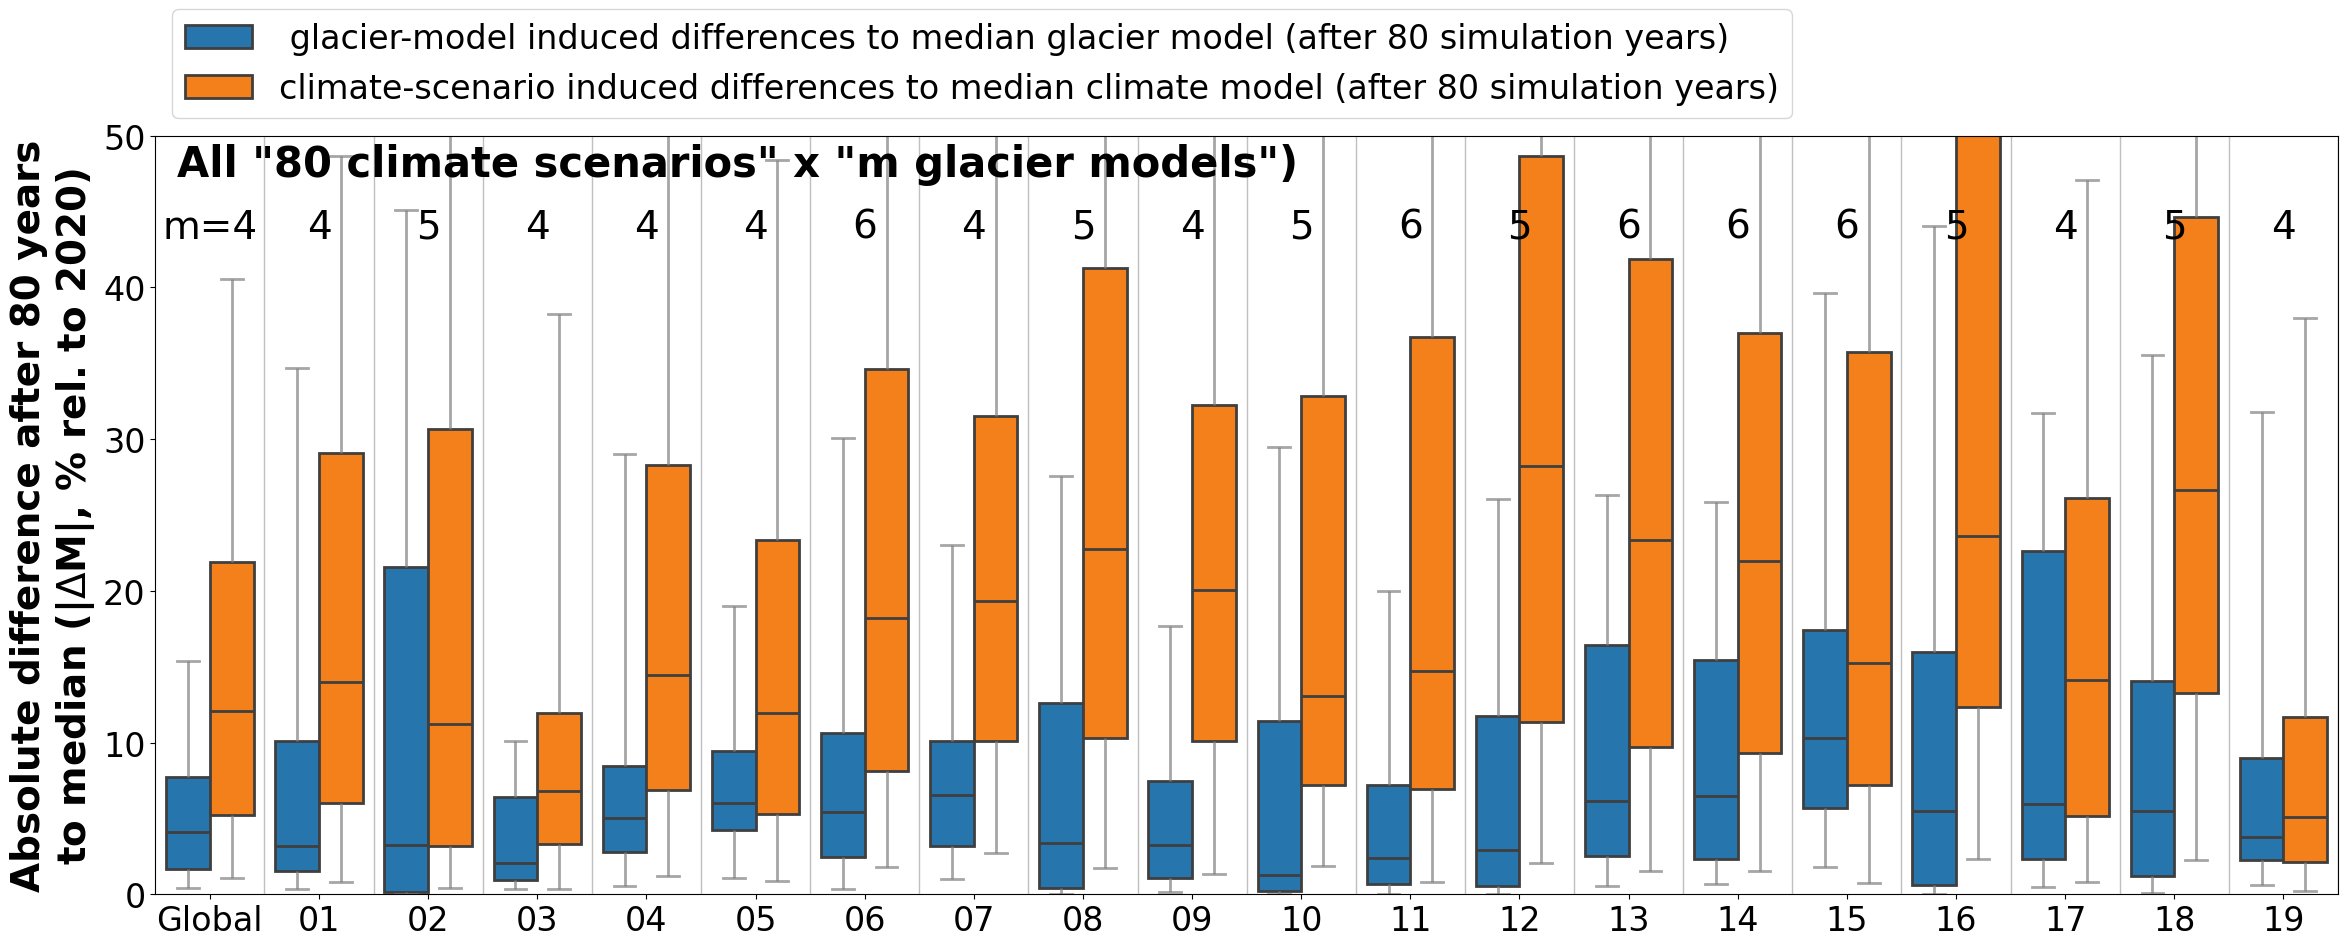

In [17]:

# select just one "period_scenario" for comparison...
#for period_scenario in ['2021-2040_ssp126', '2061-2080_ssp126', '2081-2100_ssp126']:
plt.subplots(1,1,figsize=(24,10), sharey=True)

_sel_temp = pd_reg_models_vol_all_80 # let's try to select all ... .loc[pd_reg_models_vol_all_80.period_scenario==period_scenario]
n = len(_sel_temp.groupby(['gcm','period_scenario']).count())
print(delta, n, _sel_temp.groupby(['gcm','period_scenario'])['temp_ch_ipcc'].median().median())
assert np.all(_sel_temp.groupby(['rgi_reg', 'model_author', 'temp_ch_ipcc']).count()==1)

ds_sel_temp = _sel_temp.groupby(['rgi_reg', 'model_author',
                              'temp_ch_ipcc'])[['relative volume change (in %)',
                                                 'delta relative volume change (in %, to median model)']].median().to_xarray()
ds_sel_temp['delta relative volume change (in %, to median climate)'] = ds_sel_temp['relative volume change (in %)'] - ds_sel_temp['relative volume change (in %)'].median(dim='temp_ch_ipcc')

ds_sel_temp[' glacier-model induced differences to median glacier model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median model)'])
ds_sel_temp['climate-scenario induced differences to median climate model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median climate)'])
_sel_temp = ds_sel_temp.to_dataframe().dropna()
_sel_temp = _sel_temp.reset_index()
_sel_temp_melt = _sel_temp.melt(id_vars=['rgi_reg', 'model_author', 'temp_ch_ipcc'],
              value_vars=[' glacier-model induced differences to median glacier model (after 80 simulation years)',
                          'climate-scenario induced differences to median climate model (after 80 simulation years)'])

# Define custom sorting order
custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
# Create a categorical type with the custom order
_sel_temp_melt['rgi_reg'] = pd.Categorical(_sel_temp_melt['rgi_reg'], categories=custom_order, ordered=True) 
# Sort the DataFrame by the 'rgi_reg' column
_sel_temp_melt = _sel_temp_melt.sort_values('rgi_reg').reset_index(drop=True)


ax = plt.gca()
y=f'delta relative volume change (in %, to median climate {temp}+/-{delta}°C)'

xlim0=0#-35
xlim1 = 50
sns.boxplot(data=_sel_temp_melt,
            ax = ax,
            y='value',
            x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
            hue='variable', 
            hue_order = [' glacier-model induced differences to median glacier model (after 80 simulation years)', 
                         'climate-scenario induced differences to median climate model (after 80 simulation years)'],
           fliersize=0, whis = [5,95], 
                  dodge = True, #hue='ssp',
                  #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
            #y = 'time', #hue_order = ['2040', '2100'],
            linewidth=2,
            capprops={'color':'grey', 'alpha':0.7},
            whiskerprops={'color':'grey', 'alpha':0.7},
            saturation = 0.9,
            #legend=False
            #hue_order=_hue_order, palette=_pal_models,
           )#legend = True)#legend=legend)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
#_,xlim1 = ax.get_xlim()
ax.set_ylim([xlim0,xlim1])

ax.set_ylabel('Absolute difference after 80 years\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)


ax.set_xlabel('', fontsize=26)
#for n in np.arange(xlim0+15,xlim1,20):
#    ax.axhline(n, color='grey', ls=':', alpha = 0.5, lw=2)
#ax.axhline(0, color='grey', ls=':', alpha = 1, lw=3)
for vl in np.arange(0.5,20,1):
    ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
#ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
ax.text(0.01,0.99,f'All "{n} climate scenarios" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
_c = _sel_temp_melt.groupby(['rgi_reg','model_author'], observed=False)['value'].median().dropna().reset_index()
_c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
for j,c in enumerate(_c.values):
    if j ==0:
        ax.text(j,44,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
    else:
        ax.text(j,44,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
        
plt.tight_layout()
plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_differences_after_80years_all_period_scenarios.png')
plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_differences_after_80years_all_period_scenarios.pdf')


--> of course this includes all 80 climate scenarios --> there the climate model 

0.5 5 1.636714986028974
0.5 5 2.0912659163195166
0.5 5 1.9477879408841847


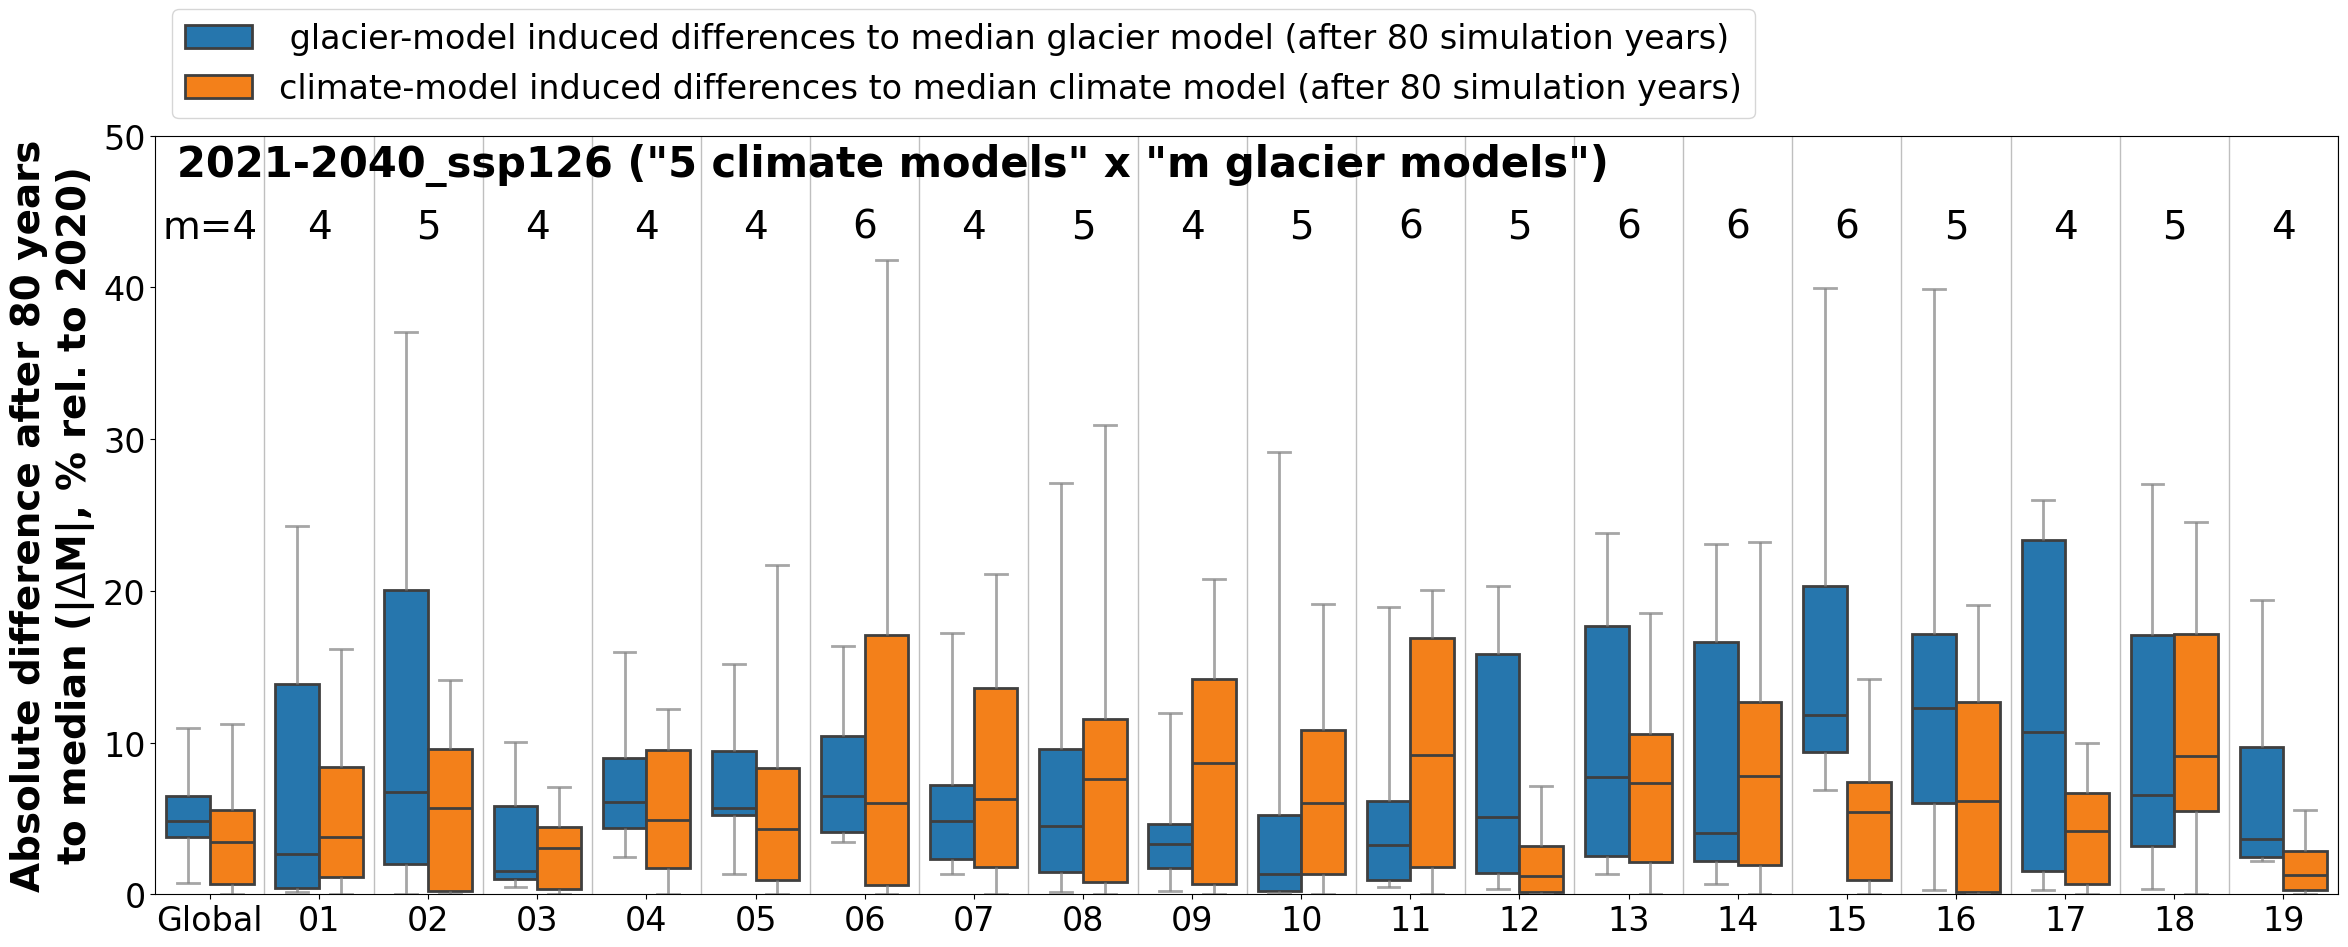

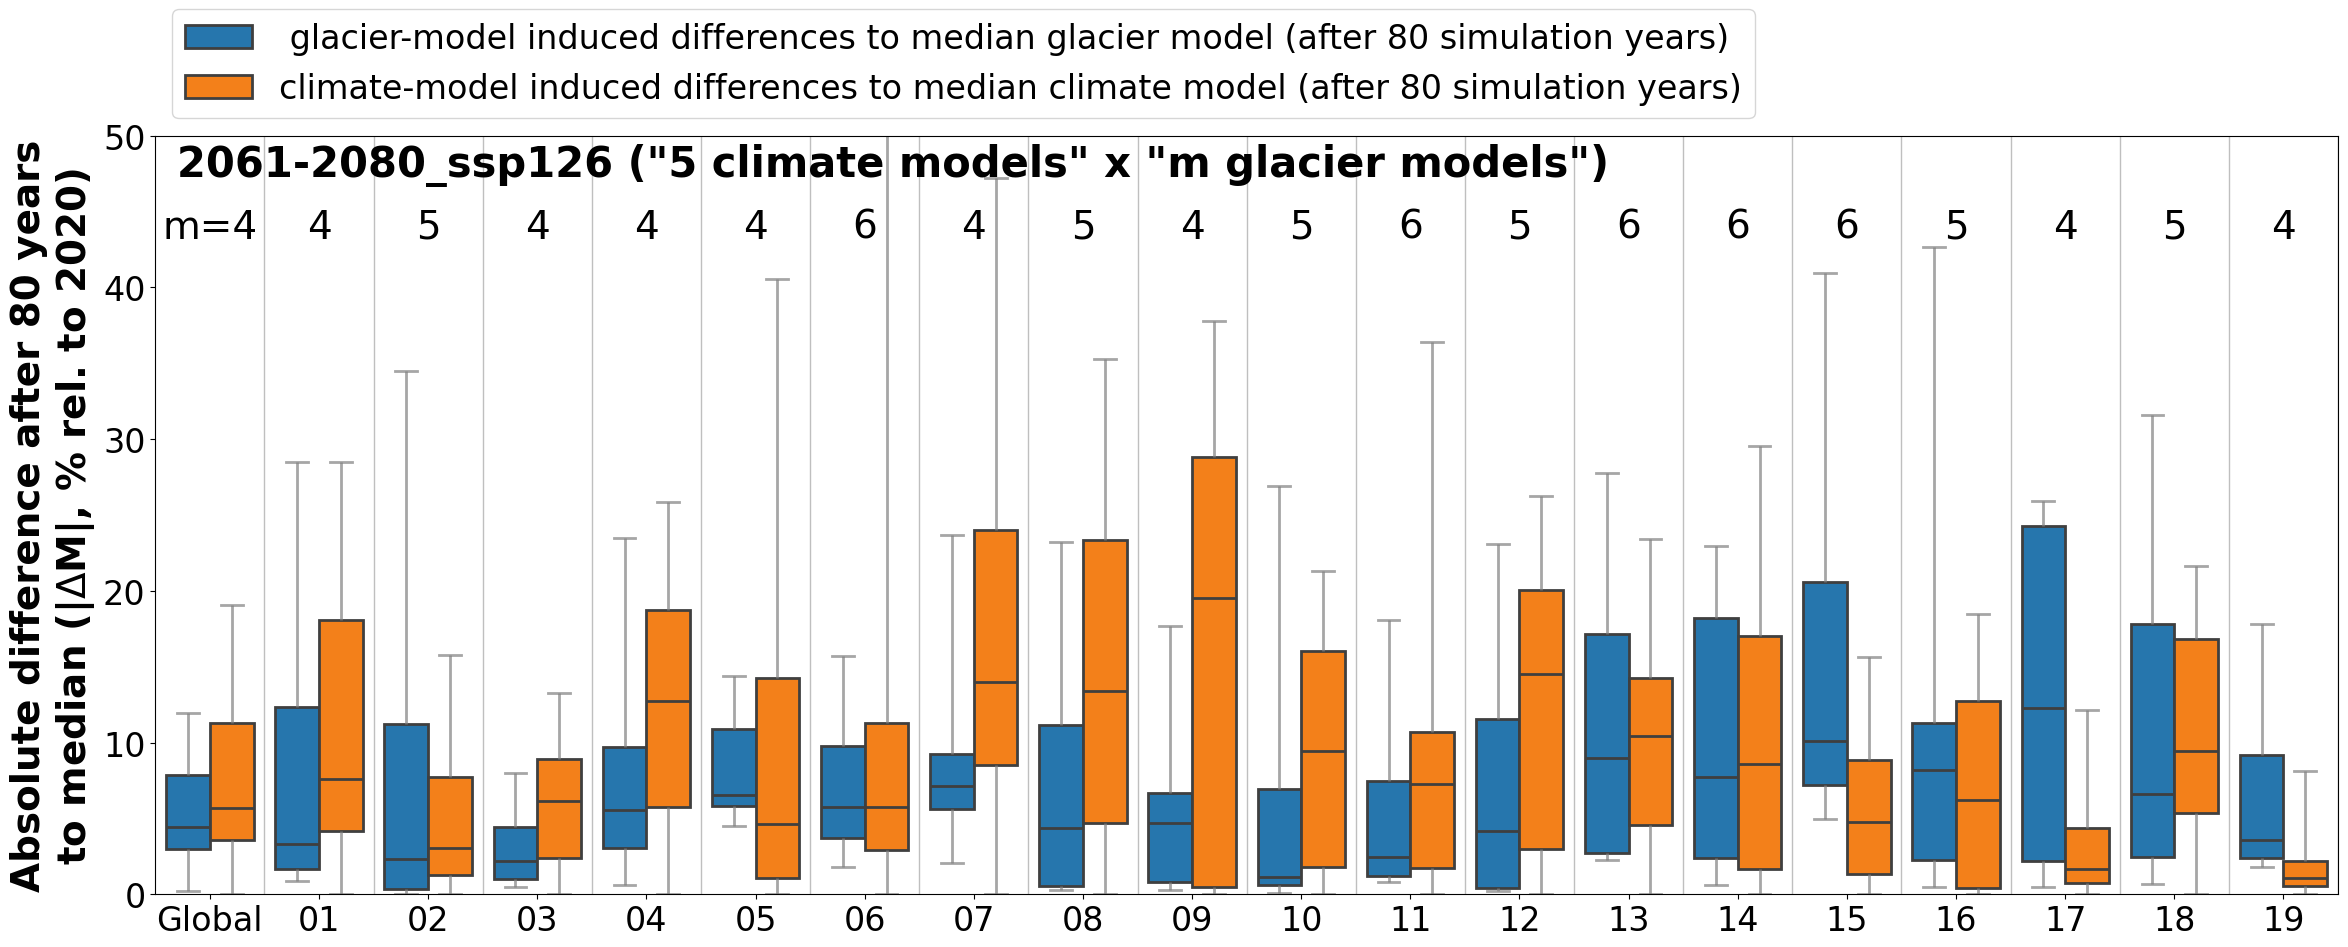

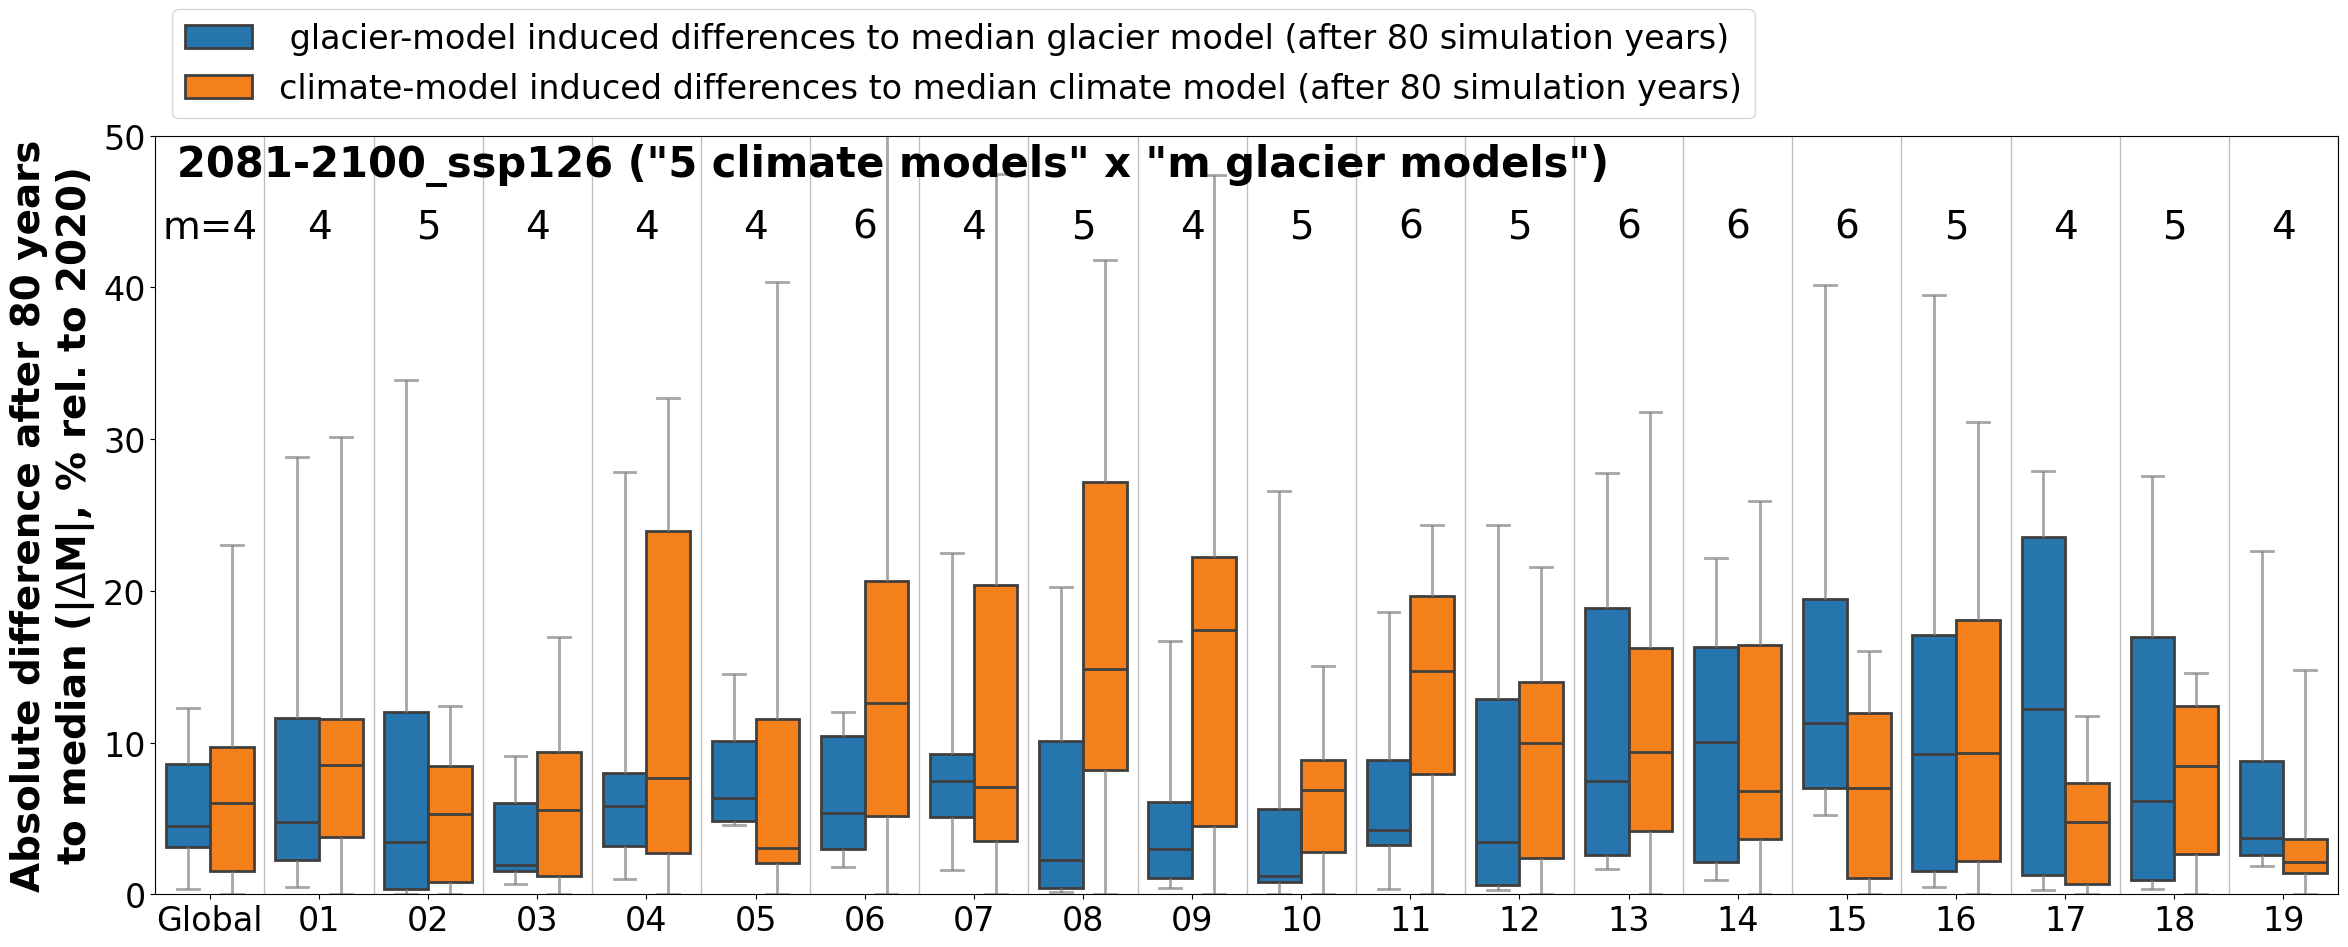

In [18]:

# select just one "period_scenario" for comparison...
for period_scenario in ['2021-2040_ssp126', '2061-2080_ssp126', '2081-2100_ssp126']:
    plt.subplots(1,1,figsize=(24,10), sharey=True)
    
    _sel_temp = pd_reg_models_vol_all_80.loc[pd_reg_models_vol_all_80.period_scenario==period_scenario]
    n = len(_sel_temp.groupby(['gcm','period_scenario']).count())
    print(delta, n, _sel_temp.groupby(['gcm','period_scenario'])['temp_ch_ipcc'].median().median())
    assert np.all(_sel_temp.groupby(['rgi_reg', 'model_author', 'temp_ch_ipcc']).count()==1)
    
    ds_sel_temp = _sel_temp.groupby(['rgi_reg', 'model_author',
                                  'temp_ch_ipcc'])[['relative volume change (in %)',
                                                     'delta relative volume change (in %, to median model)']].median().to_xarray()
    ds_sel_temp['delta relative volume change (in %, to median climate)'] = ds_sel_temp['relative volume change (in %)'] - ds_sel_temp['relative volume change (in %)'].median(dim='temp_ch_ipcc')
    
    ds_sel_temp[' glacier-model induced differences to median glacier model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median model)'])
    ds_sel_temp['climate-model induced differences to median climate model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median climate)'])
    _sel_temp = ds_sel_temp.to_dataframe().dropna()
    _sel_temp = _sel_temp.reset_index()
    _sel_temp_melt = _sel_temp.melt(id_vars=['rgi_reg', 'model_author', 'temp_ch_ipcc'],
                  value_vars=[' glacier-model induced differences to median glacier model (after 80 simulation years)',
                              'climate-model induced differences to median climate model (after 80 simulation years)'])
    
    # Define custom sorting order
    custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
    # Create a categorical type with the custom order
    _sel_temp_melt['rgi_reg'] = pd.Categorical(_sel_temp_melt['rgi_reg'], categories=custom_order, ordered=True) 
    # Sort the DataFrame by the 'rgi_reg' column
    _sel_temp_melt = _sel_temp_melt.sort_values('rgi_reg').reset_index(drop=True)
    
    
    ax = plt.gca()
    y=f'delta relative volume change (in %, to median climate {temp}+/-{delta}°C)'
    
    xlim0=0#-35
    xlim1 = 50
    sns.boxplot(data=_sel_temp_melt,
                ax = ax,
                y='value',
                x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
                hue='variable', 
                hue_order = [' glacier-model induced differences to median glacier model (after 80 simulation years)', 
                             'climate-model induced differences to median climate model (after 80 simulation years)'],
               fliersize=0, whis = [5,95], 
                      dodge = True, #hue='ssp',
                      #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
                #y = 'time', #hue_order = ['2040', '2100'],
                linewidth=2,
                capprops={'color':'grey', 'alpha':0.7},
                whiskerprops={'color':'grey', 'alpha':0.7},
                saturation = 0.9,
                #legend=False
                #hue_order=_hue_order, palette=_pal_models,
               )#legend = True)#legend=legend)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
    #_,xlim1 = ax.get_xlim()
    ax.set_ylim([xlim0,xlim1])
    
    ax.set_ylabel('Absolute difference after 80 years\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)
    
    
    ax.set_xlabel('', fontsize=26)
    #for n in np.arange(xlim0+15,xlim1,20):
    #    ax.axhline(n, color='grey', ls=':', alpha = 0.5, lw=2)
    #ax.axhline(0, color='grey', ls=':', alpha = 1, lw=3)
    for vl in np.arange(0.5,20,1):
        ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
    #ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
    ax.text(0.01,0.99,f'{period_scenario} ("{n} climate models" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
    _c = _sel_temp_melt.groupby(['rgi_reg','model_author'], observed=False)['value'].median().dropna().reset_index()
    _c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
    for j,c in enumerate(_c.values):
        if j ==0:
            ax.text(j,44,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
        else:
            ax.text(j,44,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
            
    plt.tight_layout()
    plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_differences_after_80years_{period_scenario}.png')
    plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_model_induced_differences_after_80years_{period_scenario}.pdf')


0.2 5 0.0833736138284337
0.5 15 0.2524779717488781
0.2 14 1.6467728177590986
0.5 21 1.664909941388102
0.2 7 2.951472321285355
0.5 13 2.950346953824412
0.2 3 4.5943250252311145
0.5 5 4.439976778002009


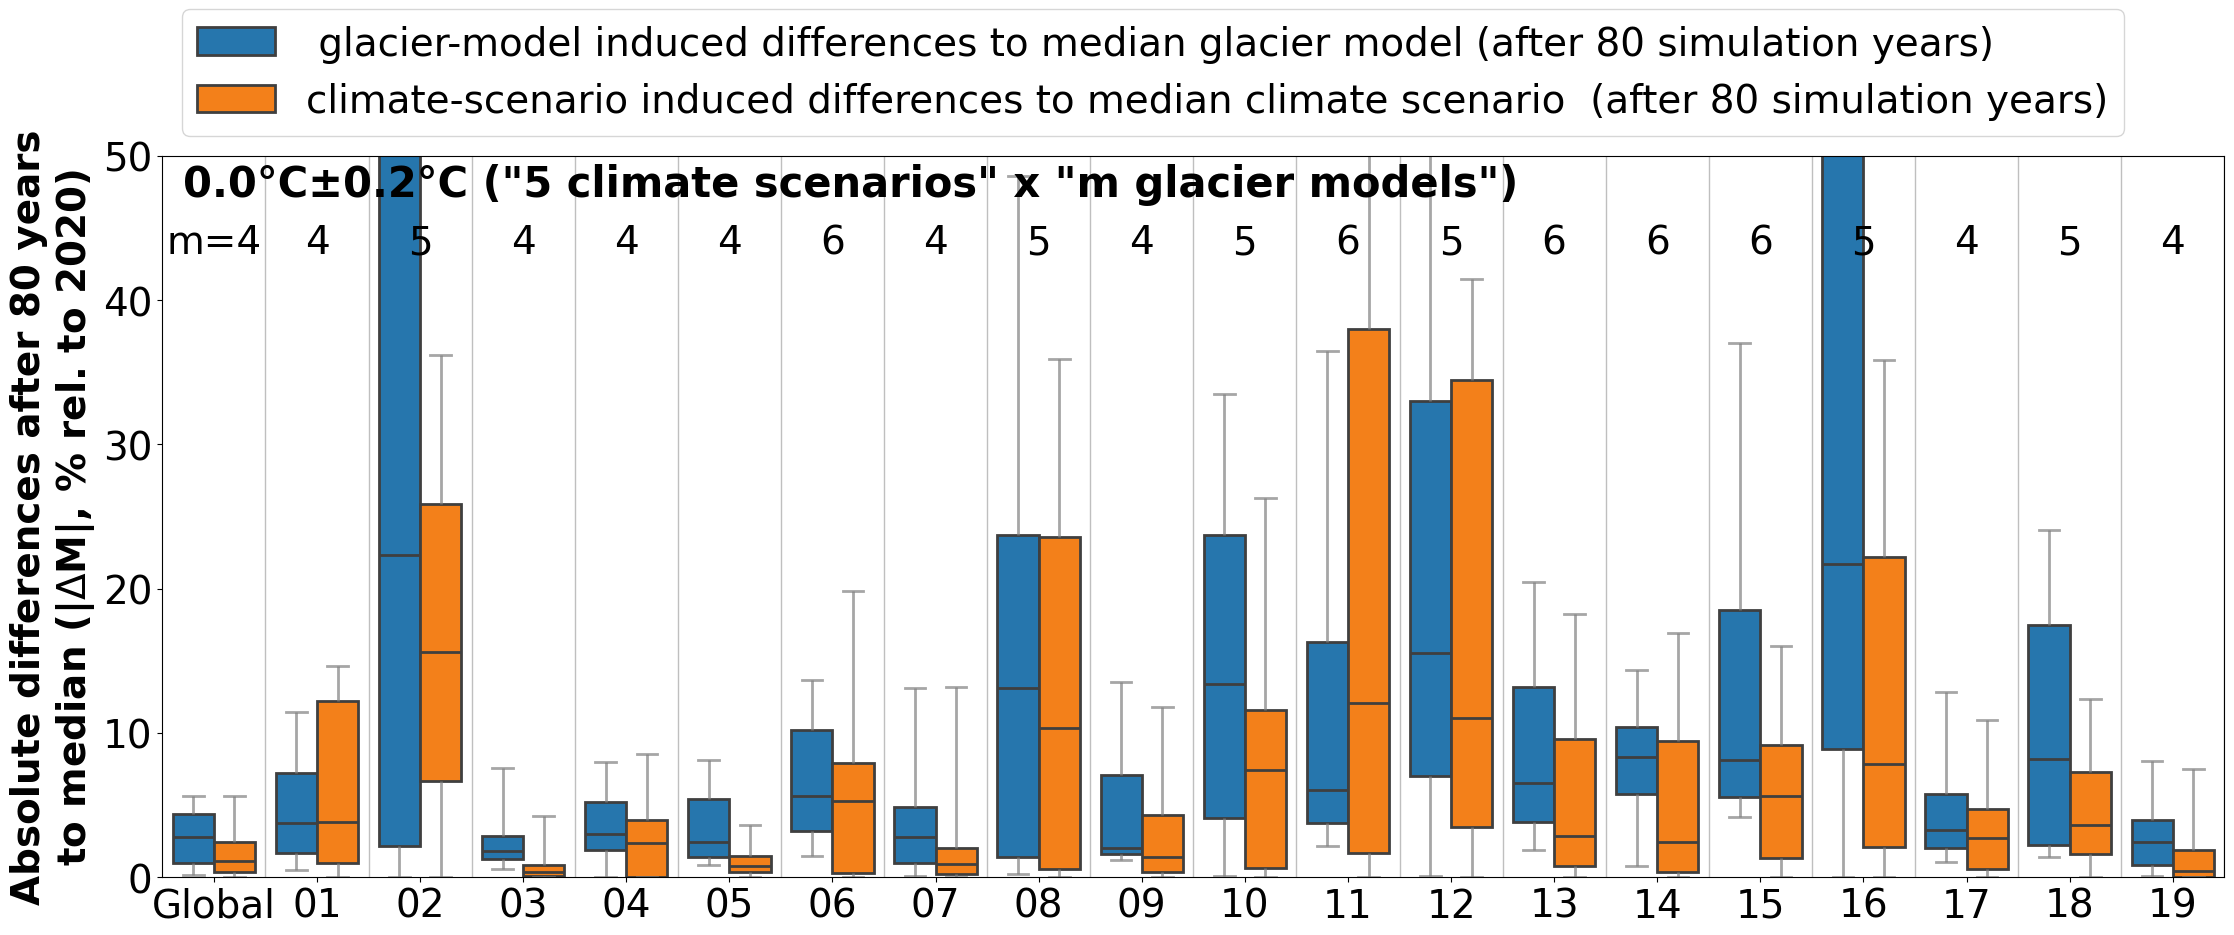

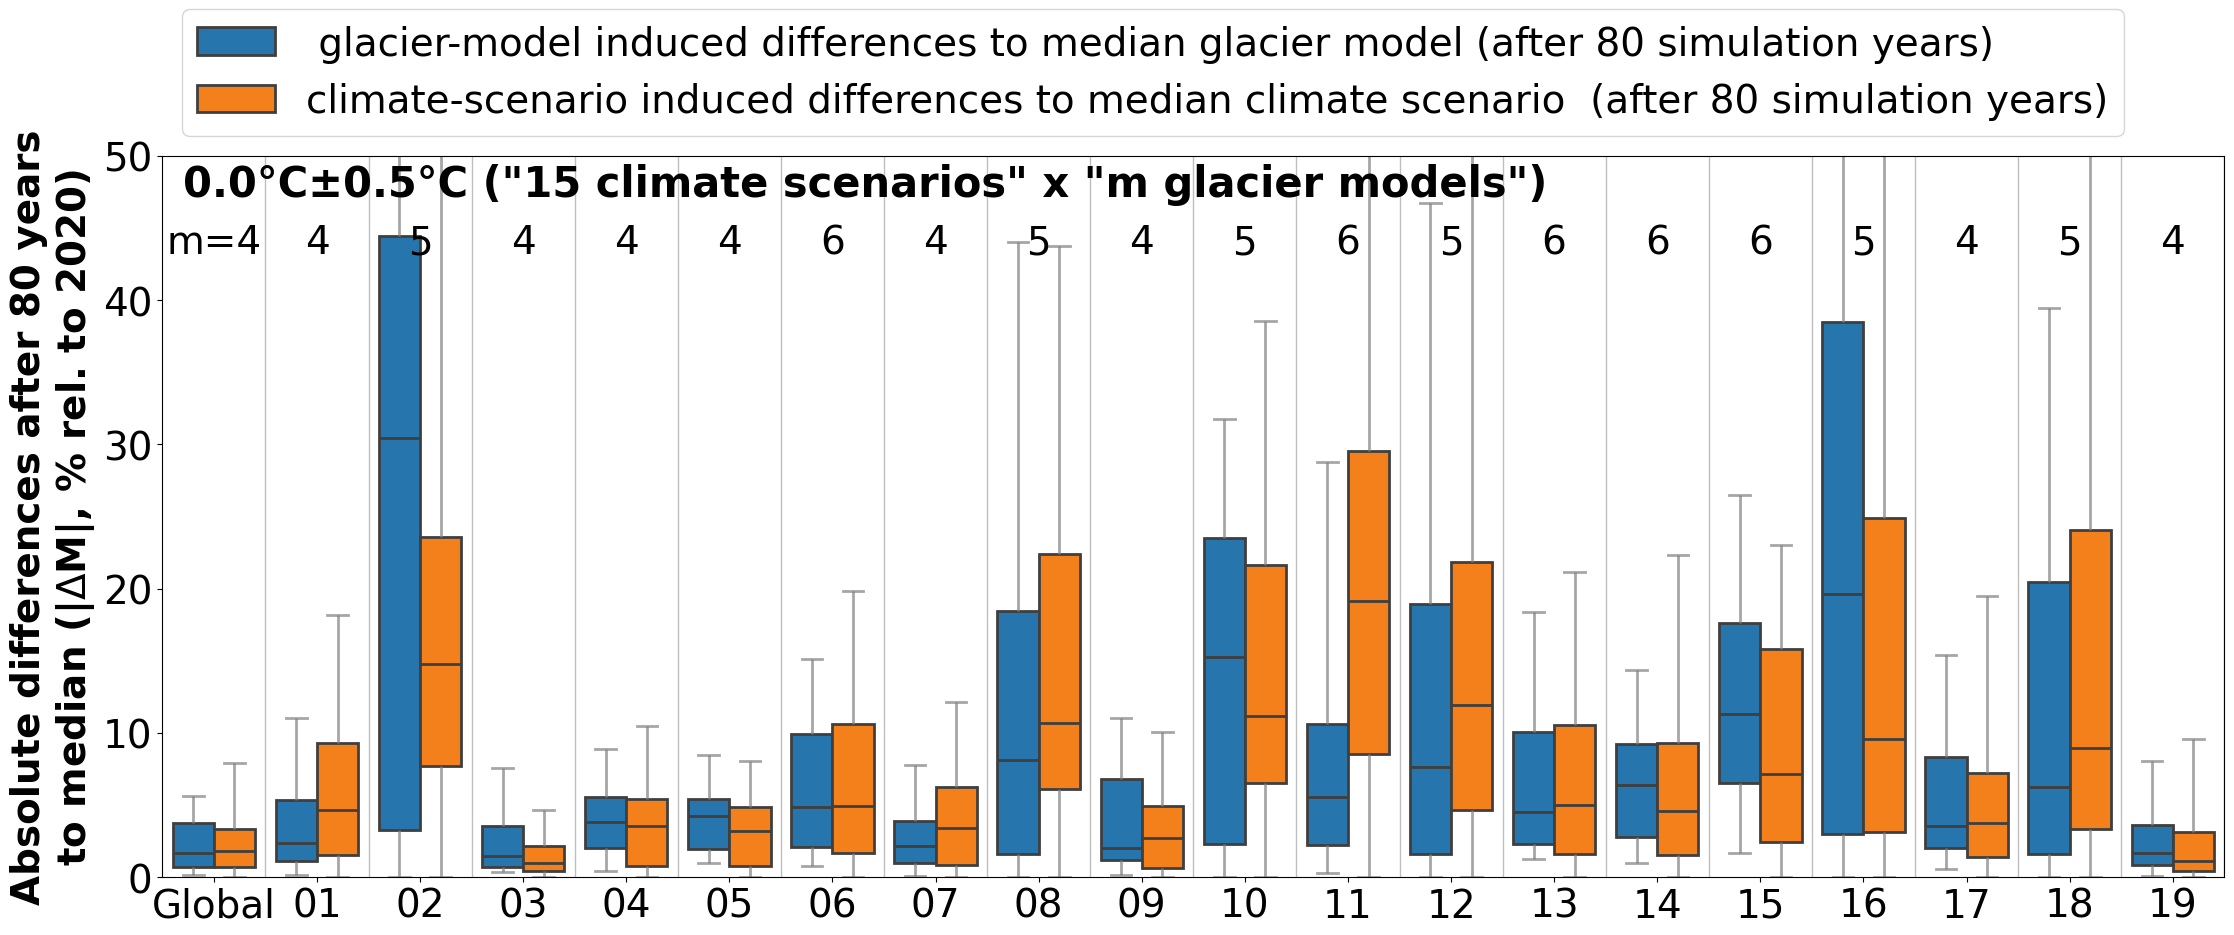

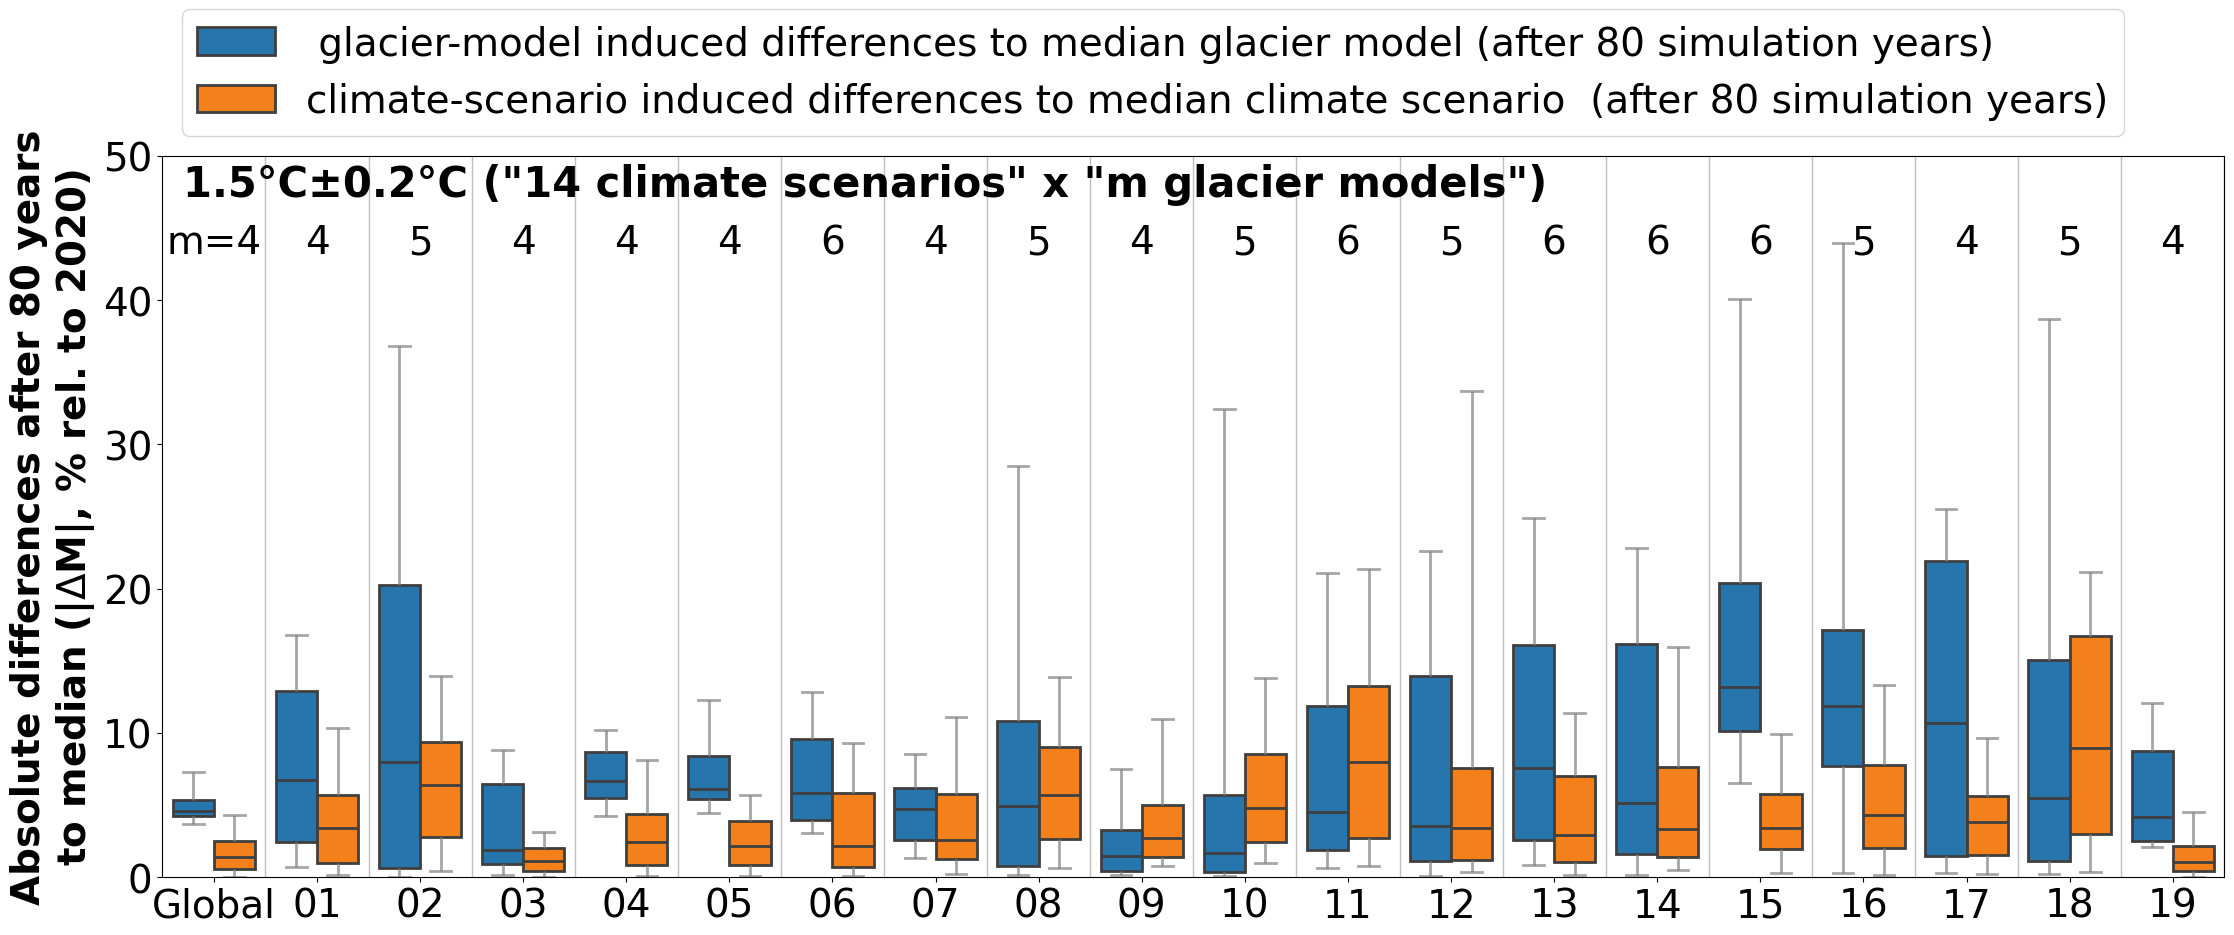

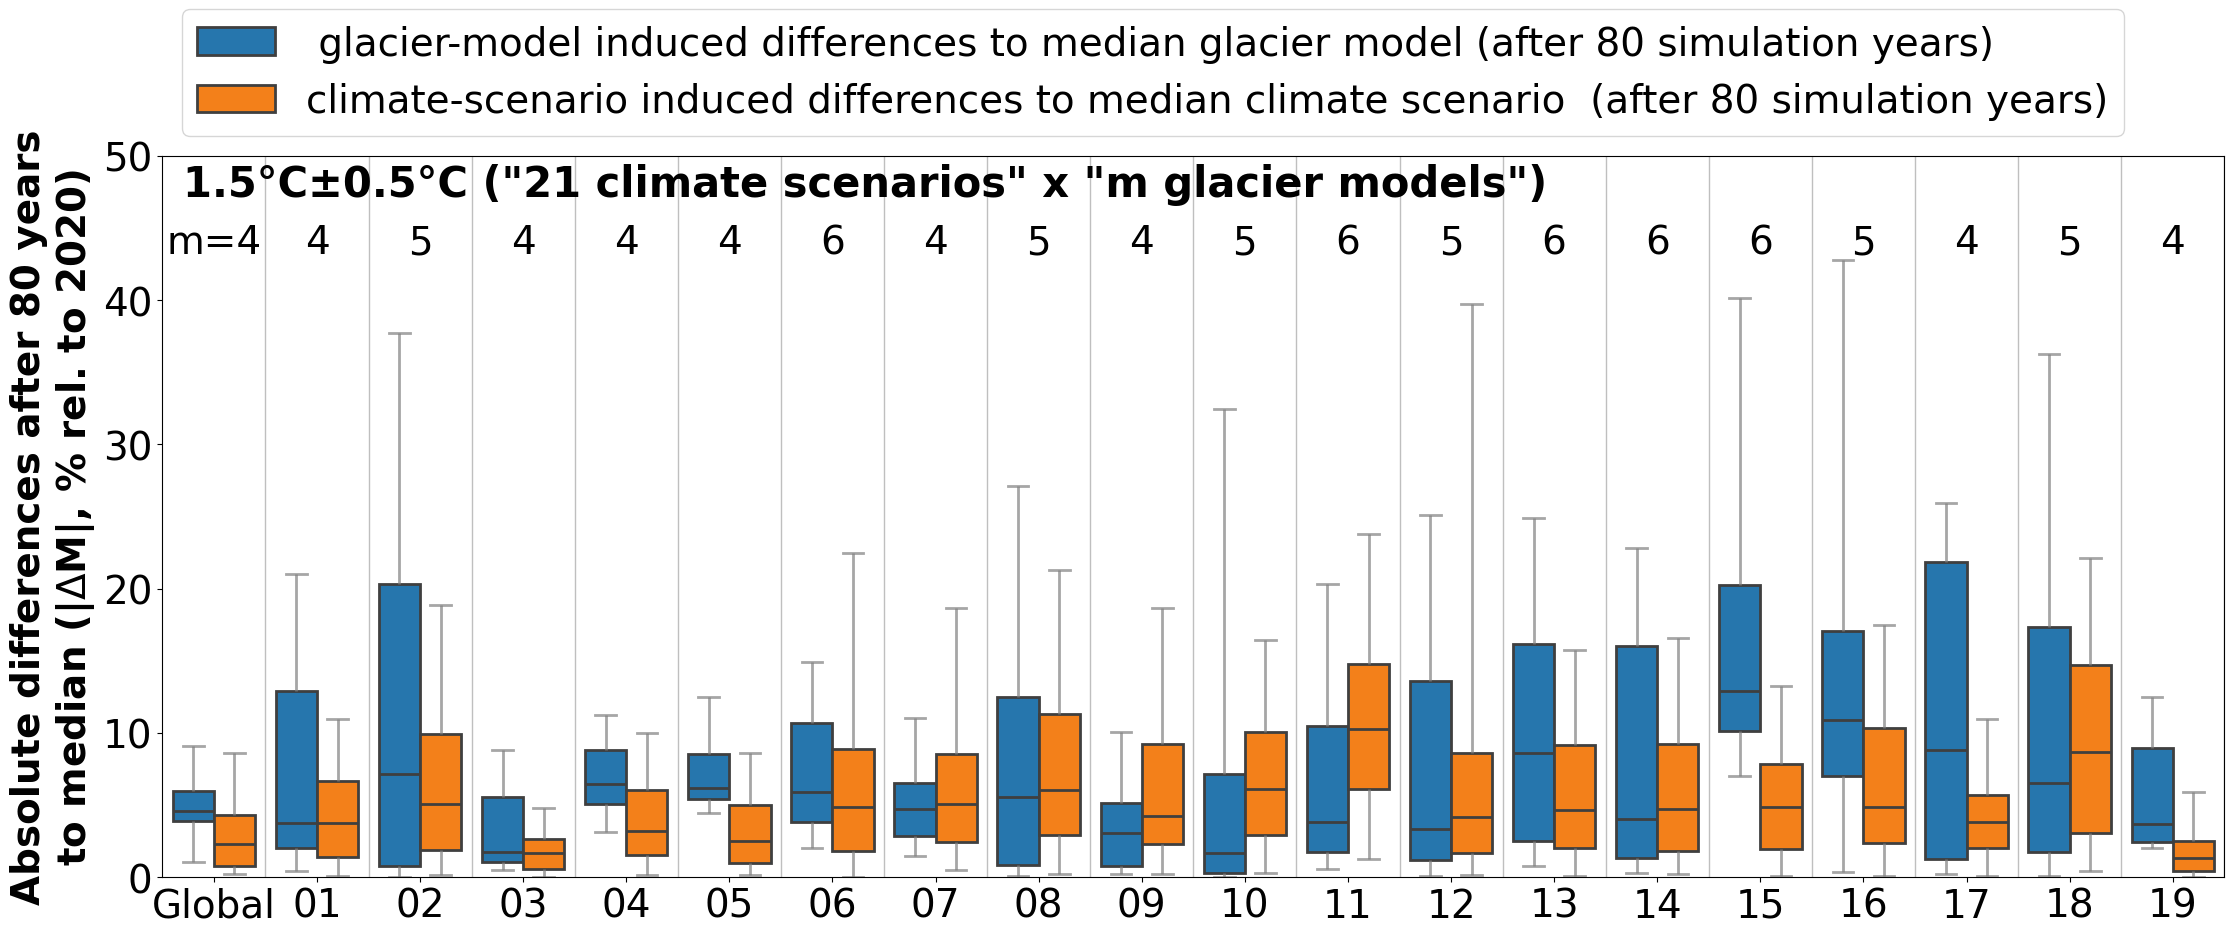

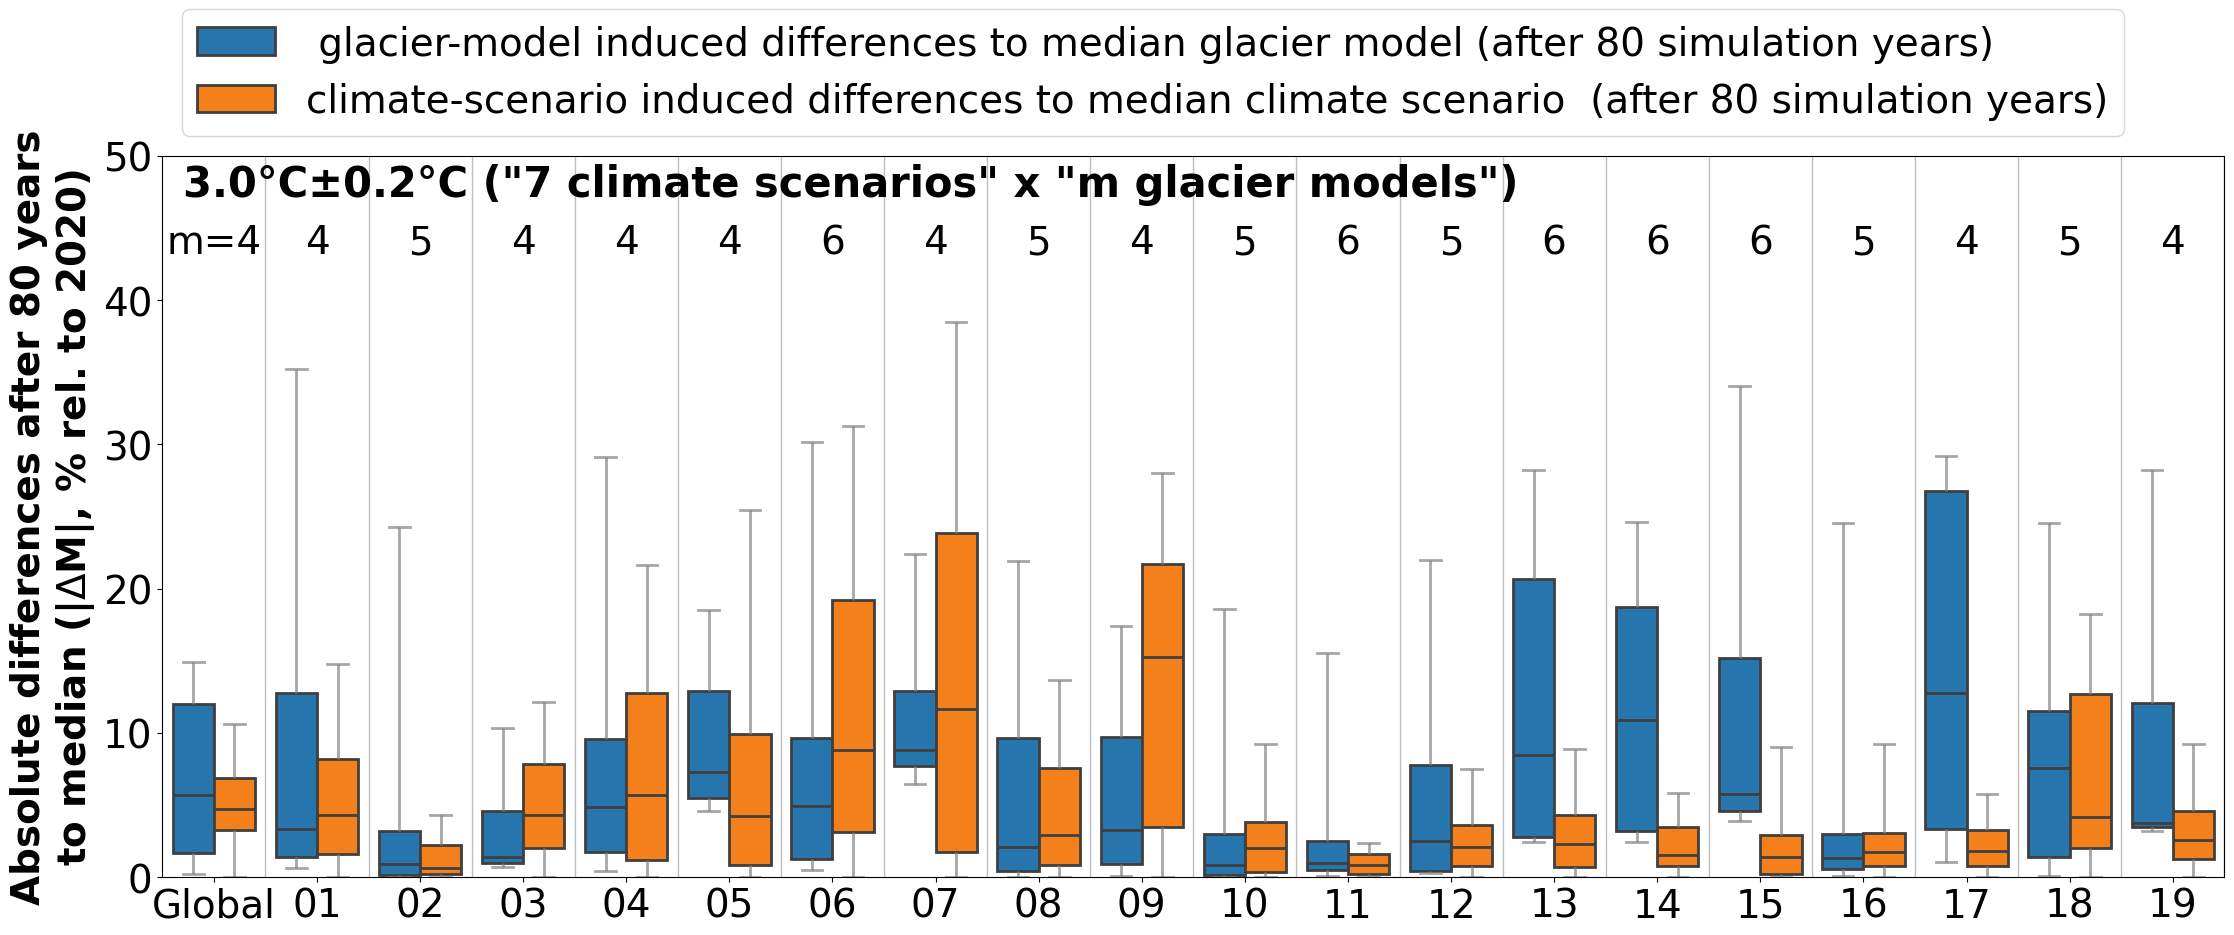

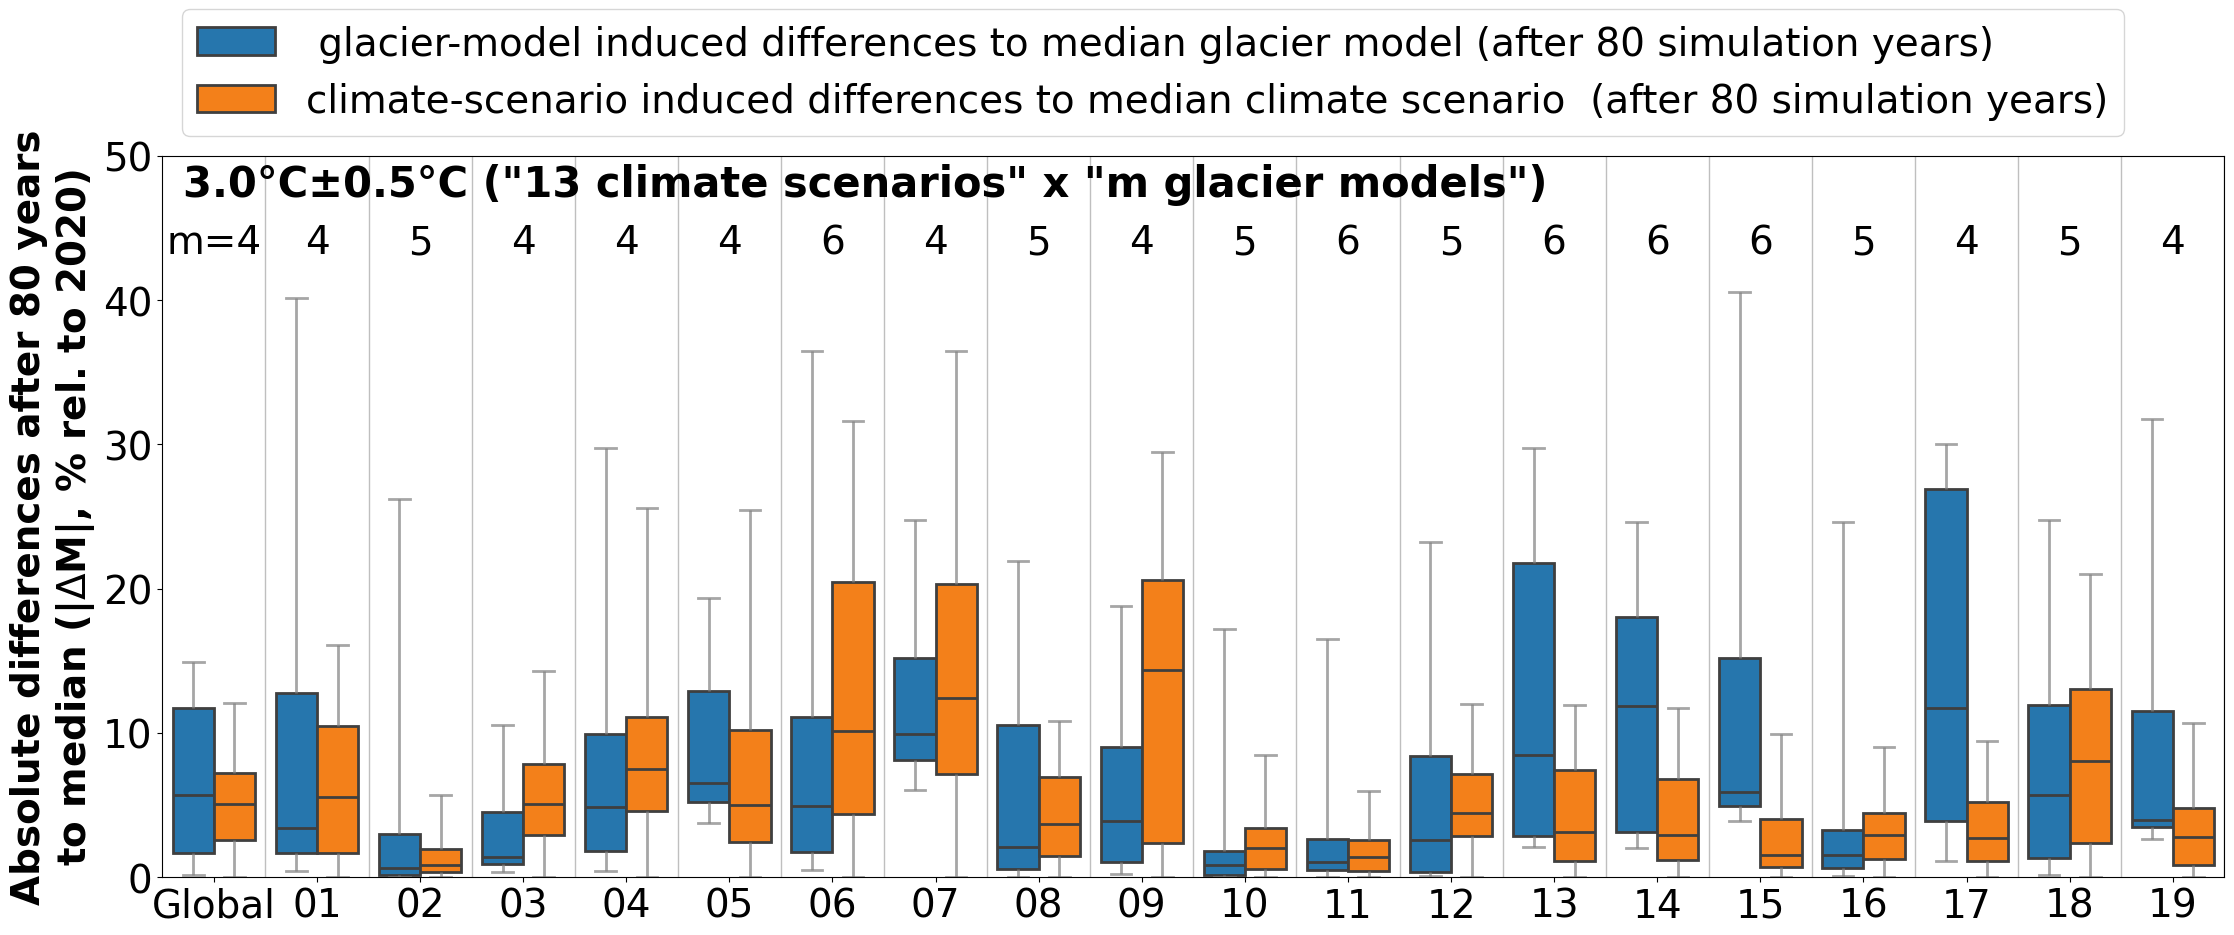

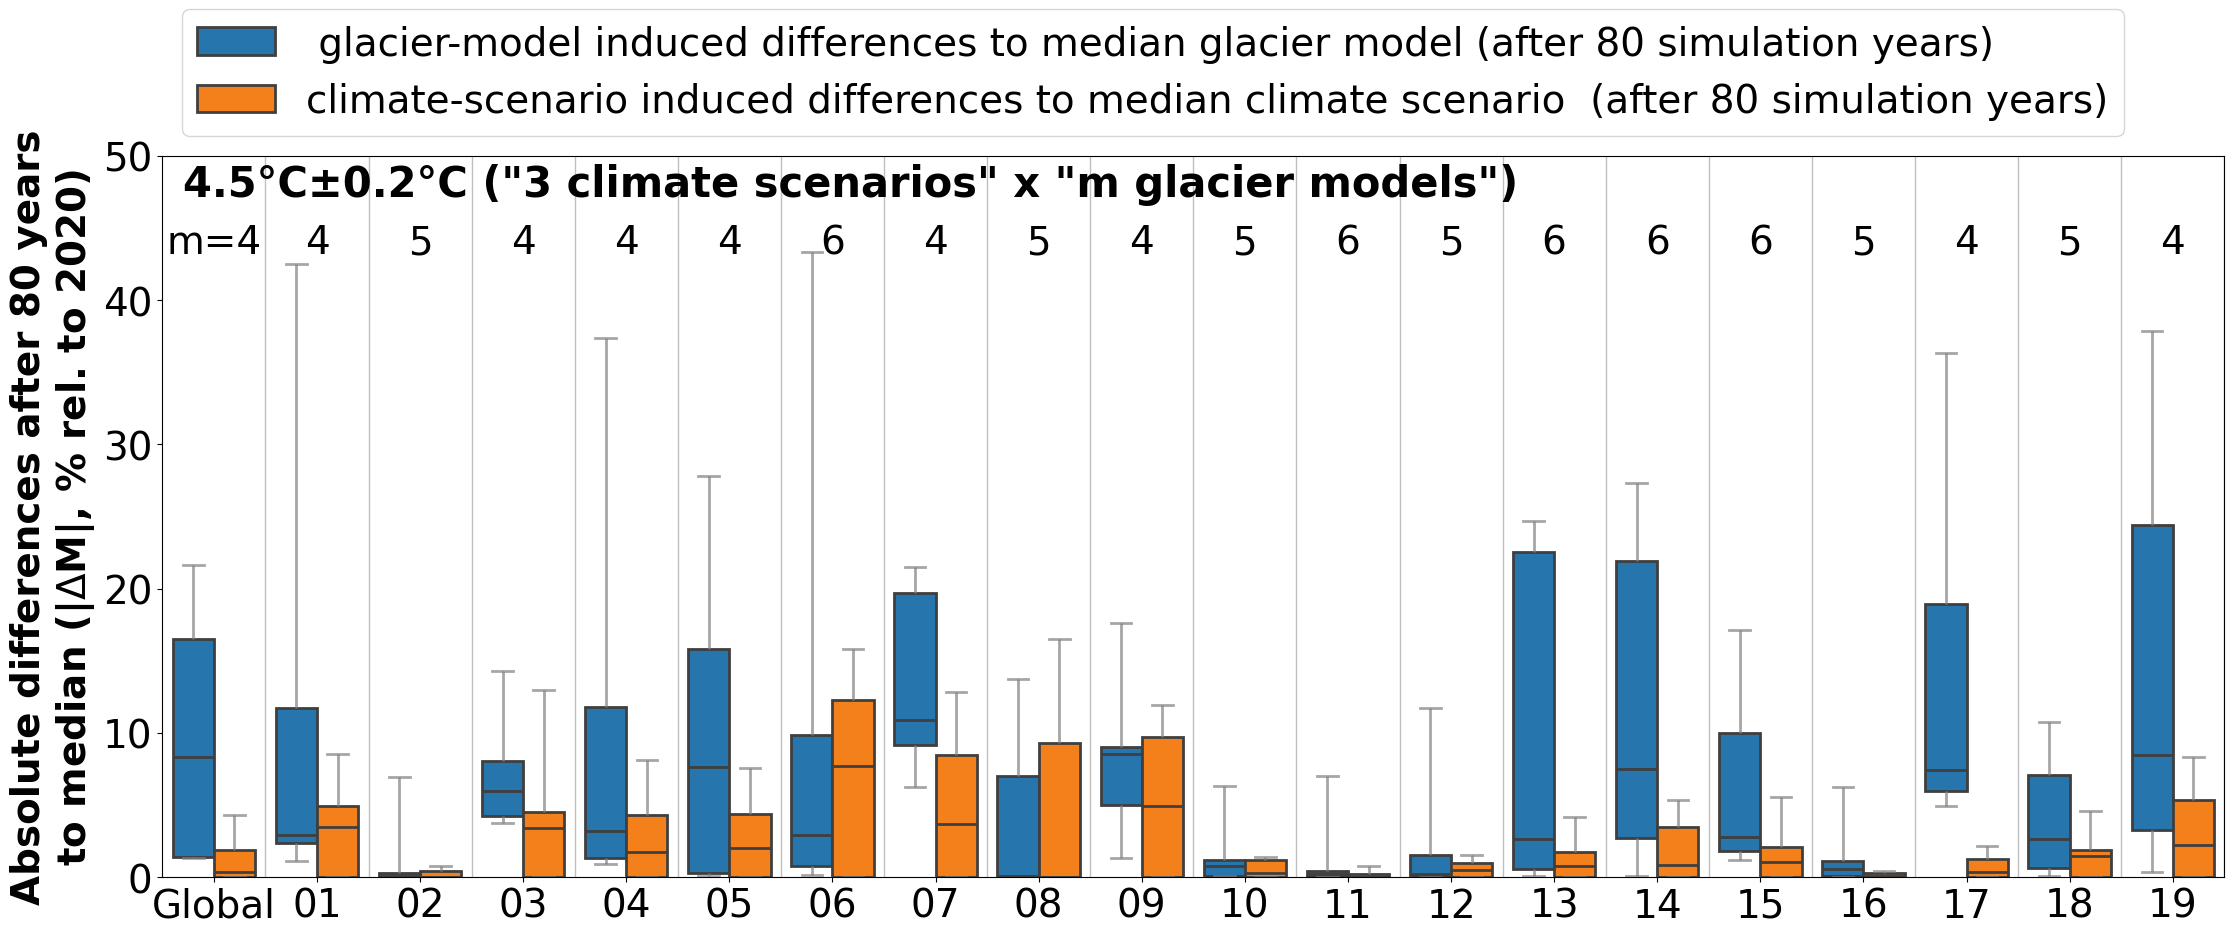

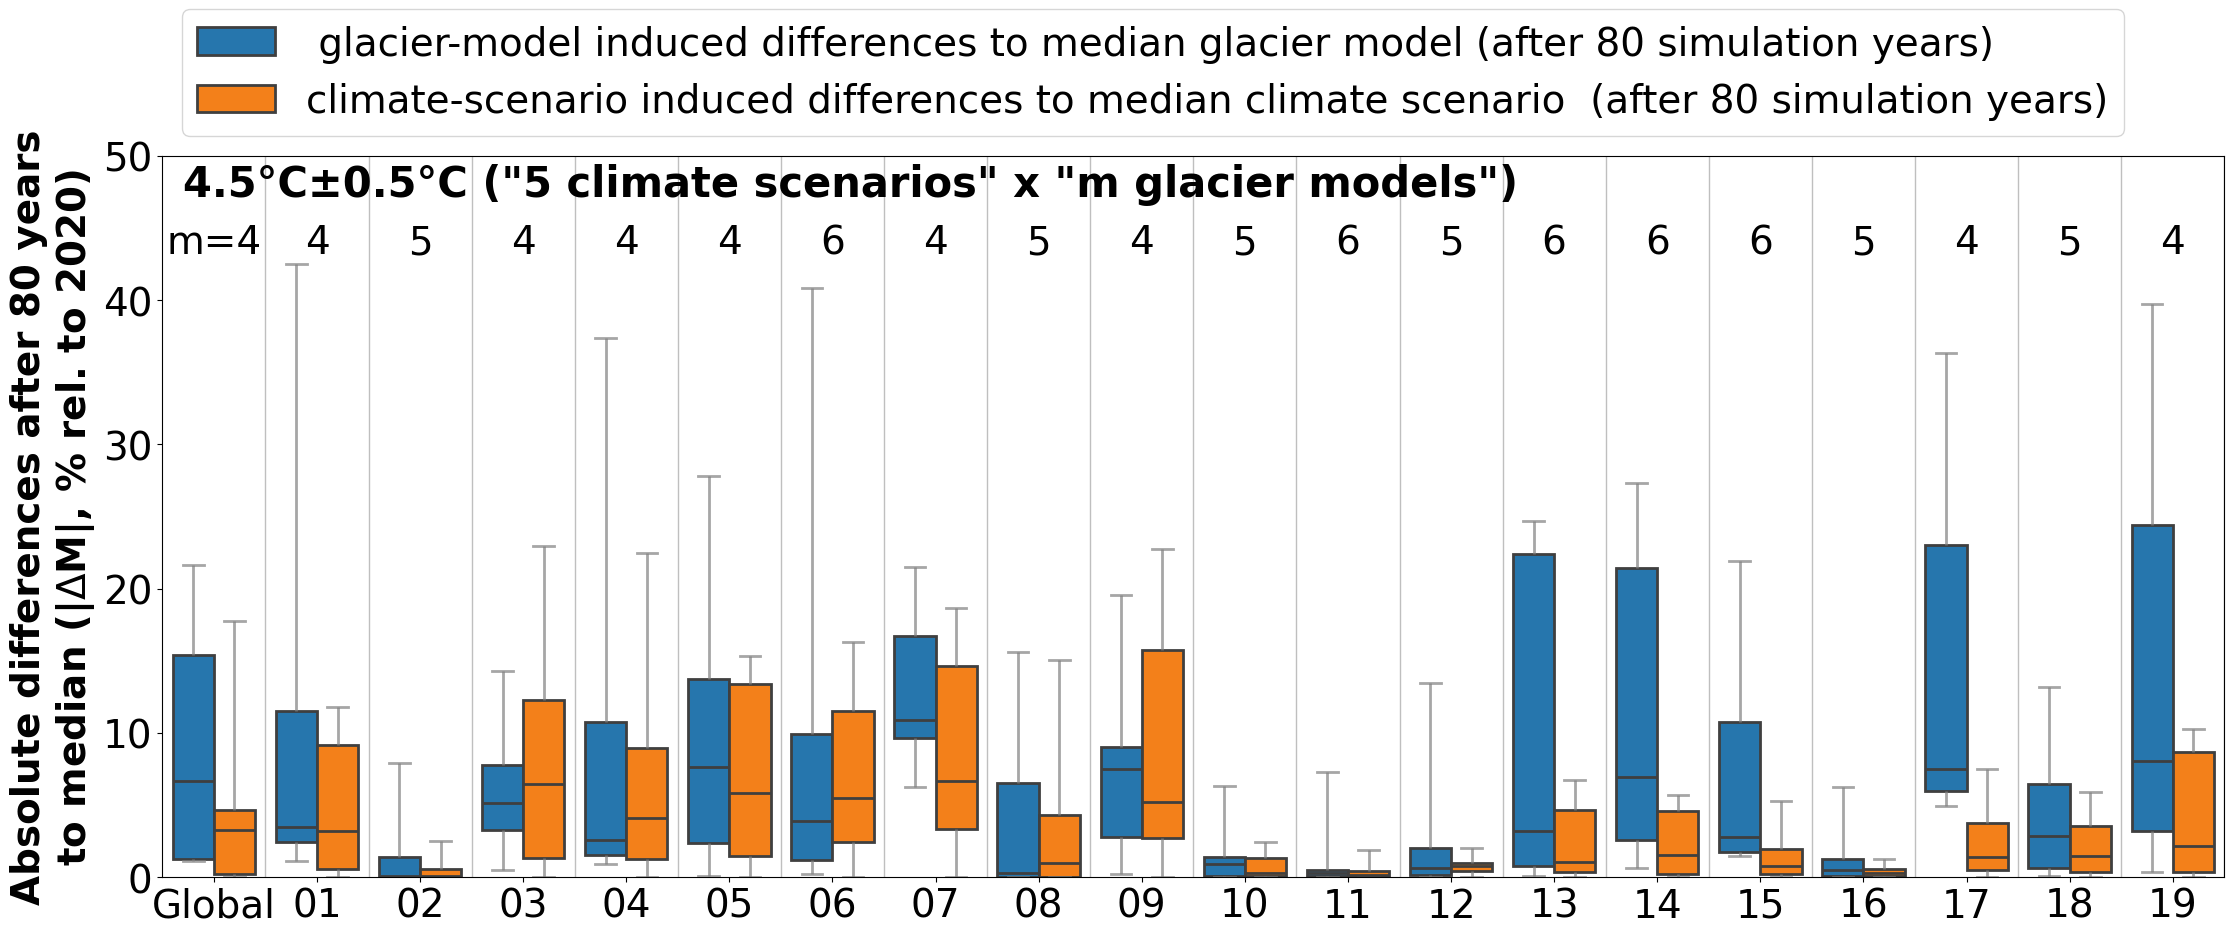

In [19]:
plt.rc('font', size=28)  


for temp in [0.0, 1.5, 3.0, 4.5]:
    for j,delta in enumerate([0.2, 0.5]): 
        plt.subplots(1,1,figsize=(24,10), sharey=True)
        _sel_temp = pd_reg_models_vol_all_80.loc[(pd_reg_models_vol_all_80.temp_ch_ipcc>=temp-delta) & 
                                            (pd_reg_models_vol_all_80.temp_ch_ipcc<=temp+delta)]
        n = len(_sel_temp.groupby(['gcm','period_scenario']).count())
        print(delta, n, _sel_temp.groupby(['gcm','period_scenario'])['temp_ch_ipcc'].median().median())
        assert np.all(_sel_temp.groupby(['rgi_reg', 'model_author', 'temp_ch_ipcc']).count()==1)
        
        ds_sel_temp = _sel_temp.groupby(['rgi_reg', 'model_author',
                                      'temp_ch_ipcc'])[['relative volume change (in %)',
                                                         'delta relative volume change (in %, to median model)']].median().to_xarray()
        ds_sel_temp['delta relative volume change (in %, to median climate)'] = ds_sel_temp['relative volume change (in %)'] - ds_sel_temp['relative volume change (in %)'].median(dim='temp_ch_ipcc')
        
        ds_sel_temp[' glacier-model induced differences to median glacier model (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median model)'])
        ds_sel_temp['climate-scenario induced differences to median climate scenario  (after 80 simulation years)'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median climate)'])
        _sel_temp = ds_sel_temp.to_dataframe().dropna()
        _sel_temp = _sel_temp.reset_index()
        _sel_temp_melt = _sel_temp.melt(id_vars=['rgi_reg', 'model_author', 'temp_ch_ipcc'],
                      value_vars=[' glacier-model induced differences to median glacier model (after 80 simulation years)',
                                  'climate-scenario induced differences to median climate scenario  (after 80 simulation years)'])

        # Define custom sorting order
        custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
        # Create a categorical type with the custom order
        _sel_temp_melt['rgi_reg'] = pd.Categorical(_sel_temp_melt['rgi_reg'], categories=custom_order, ordered=True) 
        # Sort the DataFrame by the 'rgi_reg' column
        _sel_temp_melt = _sel_temp_melt.sort_values('rgi_reg').reset_index(drop=True)

        
        ax = plt.gca()
        y=f'delta relative volume change (in %, to median climate {temp}+/-{delta}°C)'
    
        xlim0=0#-35
        xlim1 = 50
        sns.boxplot(data=_sel_temp_melt,
                    ax = ax,
                    y='value',
                    x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
                    hue='variable', 
                    hue_order = [' glacier-model induced differences to median glacier model (after 80 simulation years)', 
                                 'climate-scenario induced differences to median climate scenario  (after 80 simulation years)'],
                   fliersize=0, whis = [5,95], 
                          dodge = True, #hue='ssp',
                          #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
                    #y = 'time', #hue_order = ['2040', '2100'],
                    linewidth=2,
                    capprops={'color':'grey', 'alpha':0.7},
                    whiskerprops={'color':'grey', 'alpha':0.7},
                    saturation = 0.9,
                    #legend=False
                    #hue_order=_hue_order, palette=_pal_models,
                   )#legend = True)#legend=legend)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
        #_,xlim1 = ax.get_xlim()
        ax.set_ylim([xlim0,xlim1])
    
        ax.set_ylabel('Absolute differences after 80 years\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)
    
    
        ax.set_xlabel('', fontsize=26)
        #for n in np.arange(xlim0+15,xlim1,20):
        #    ax.axhline(n, color='grey', ls=':', alpha = 0.5, lw=2)
        #ax.axhline(0, color='grey', ls=':', alpha = 1, lw=3)
        for vl in np.arange(0.5,20,1):
            ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
        #ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
        ax.text(0.01,0.99,f'{temp}°C±{delta}°C ("{n} climate scenarios" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
        _c = _sel_temp_melt.groupby(['rgi_reg','model_author'], observed=False)['value'].median().dropna().reset_index()
        _c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
        for j,c in enumerate(_c.values):
            if j ==0:
                ax.text(j,44,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
            else:
                ax.text(j,44,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
                
        plt.tight_layout()
        _temp = str(temp).replace('.','-')
        _delta = str(delta).replace('.','-')
        plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_scenario_induced_differences_after80years_{_temp}_delta{_delta}.png')
        plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/glacier_vs_climate_scenario_induced_differences_after_80years_{_temp}_delta{_delta}.pdf')

### Import GlacierMIP2 data

In [20]:
ds_gmip2 = xr.open_dataset('PartB_data/data_from_others/suppl_GlacierMIP2_results.nc')

In [21]:
ds_gmip2_2100 = ds_gmip2.sel(Time=2100)
ds_gmip2_2100 = ds_gmip2_2100.sel(Scenario=1).Mass
ds_gmip2_2100_global = ds_gmip2_2100.sum(dim='Region', min_count=19)
ds_gmip2_2100_global = ds_gmip2_2100_global.dropna(dim='Glacier_Model', how='all').dropna(dim='Climate_Model', how='any')
###
ds_gmip2_2020 = ds_gmip2.sel(Time=2020)
ds_gmip2_2020 = ds_gmip2_2020.sel(Scenario=1).Mass
ds_gmip2_2020_global = ds_gmip2_2020.sum(dim='Region', min_count=19)
ds_gmip2_2020_global = ds_gmip2_2020_global.dropna(dim='Glacier_Model', how='all').dropna(dim='Climate_Model', how='any')

In [22]:
# probleM: different amount of climate models per glacier... 
ds_gmip2_2100_rel = 100*ds_gmip2_2100/ds_gmip2_2020
ds_gmip2_2100_rel= ds_gmip2_2100_rel.to_dataset(name='relative volume change (in %)')
ds_gmip2_2100_rel['climate-model induced year 2100 differences to median climate model'] = np.abs(ds_gmip2_2100_rel['relative volume change (in %)'] - ds_gmip2_2100_rel['relative volume change (in %)'].median(dim='Climate_Model'))
ds_gmip2_2100_rel[' glacier-model induced year 2100 differences to median glacier model'] = np.abs(ds_gmip2_2100_rel['relative volume change (in %)'] - ds_gmip2_2100_rel['relative volume change (in %)'].median(dim='Glacier_Model'))
pd_ds_gmip2_2100_rel = ds_gmip2_2100_rel.to_dataframe().reset_index()
pd_ds_gmip2_2100_rel['rgi_reg'] =  [f'{int(i):02}' for i in pd_ds_gmip2_2100_rel['Region']]

###
ds_gmip2_2100_global_rel = 100*ds_gmip2_2100_global/ds_gmip2_2020_global
ds_gmip2_2100_global_rel= ds_gmip2_2100_global_rel.to_dataset(name='relative volume change (in %)')
ds_gmip2_2100_global_rel['climate-model induced year 2100 differences to median climate model'] = np.abs(ds_gmip2_2100_global_rel['relative volume change (in %)'] - ds_gmip2_2100_global_rel['relative volume change (in %)'].median(dim='Climate_Model'))
ds_gmip2_2100_global_rel[' glacier-model induced year 2100 differences to median glacier model'] = np.abs(ds_gmip2_2100_global_rel['relative volume change (in %)'] - ds_gmip2_2100_global_rel['relative volume change (in %)'].median(dim='Glacier_Model'))
pd_ds_gmip2_2100_global_rel = ds_gmip2_2100_global_rel.to_dataframe().reset_index()
pd_ds_gmip2_2100_global_rel['rgi_reg'] = 'Global'

In [23]:
pd_ds_gmip2_2100_rel = pd_ds_gmip2_2100_rel.dropna()[['rgi_reg', 'Glacier_Model', 'Climate_Model',' glacier-model induced year 2100 differences to median glacier model',
                                                                          'climate-model induced year 2100 differences to median climate model']]

In [24]:
pd_ds_gmip2_2100_all_rel = pd.concat([pd_ds_gmip2_2100_global_rel, pd_ds_gmip2_2100_rel])

pd_ds_gmip2_2100_all_rel = pd_ds_gmip2_2100_all_rel.melt(id_vars=['rgi_reg', 'Glacier_Model', 'Climate_Model'],
                                                              value_vars=[' glacier-model induced year 2100 differences to median glacier model',
                                                                          'climate-model induced year 2100 differences to median climate model'])
# Define custom sorting order
custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
# Create a categorical type with the custom order
pd_ds_gmip2_2100_all_rel['rgi_reg'] = pd.Categorical(pd_ds_gmip2_2100_all_rel['rgi_reg'], categories=custom_order, ordered=True) 
# Sort the DataFrame by the 'rgi_reg' column
pd_ds_gmip2_2100_all_rel = pd_ds_gmip2_2100_all_rel.sort_values('rgi_reg').reset_index(drop=True)

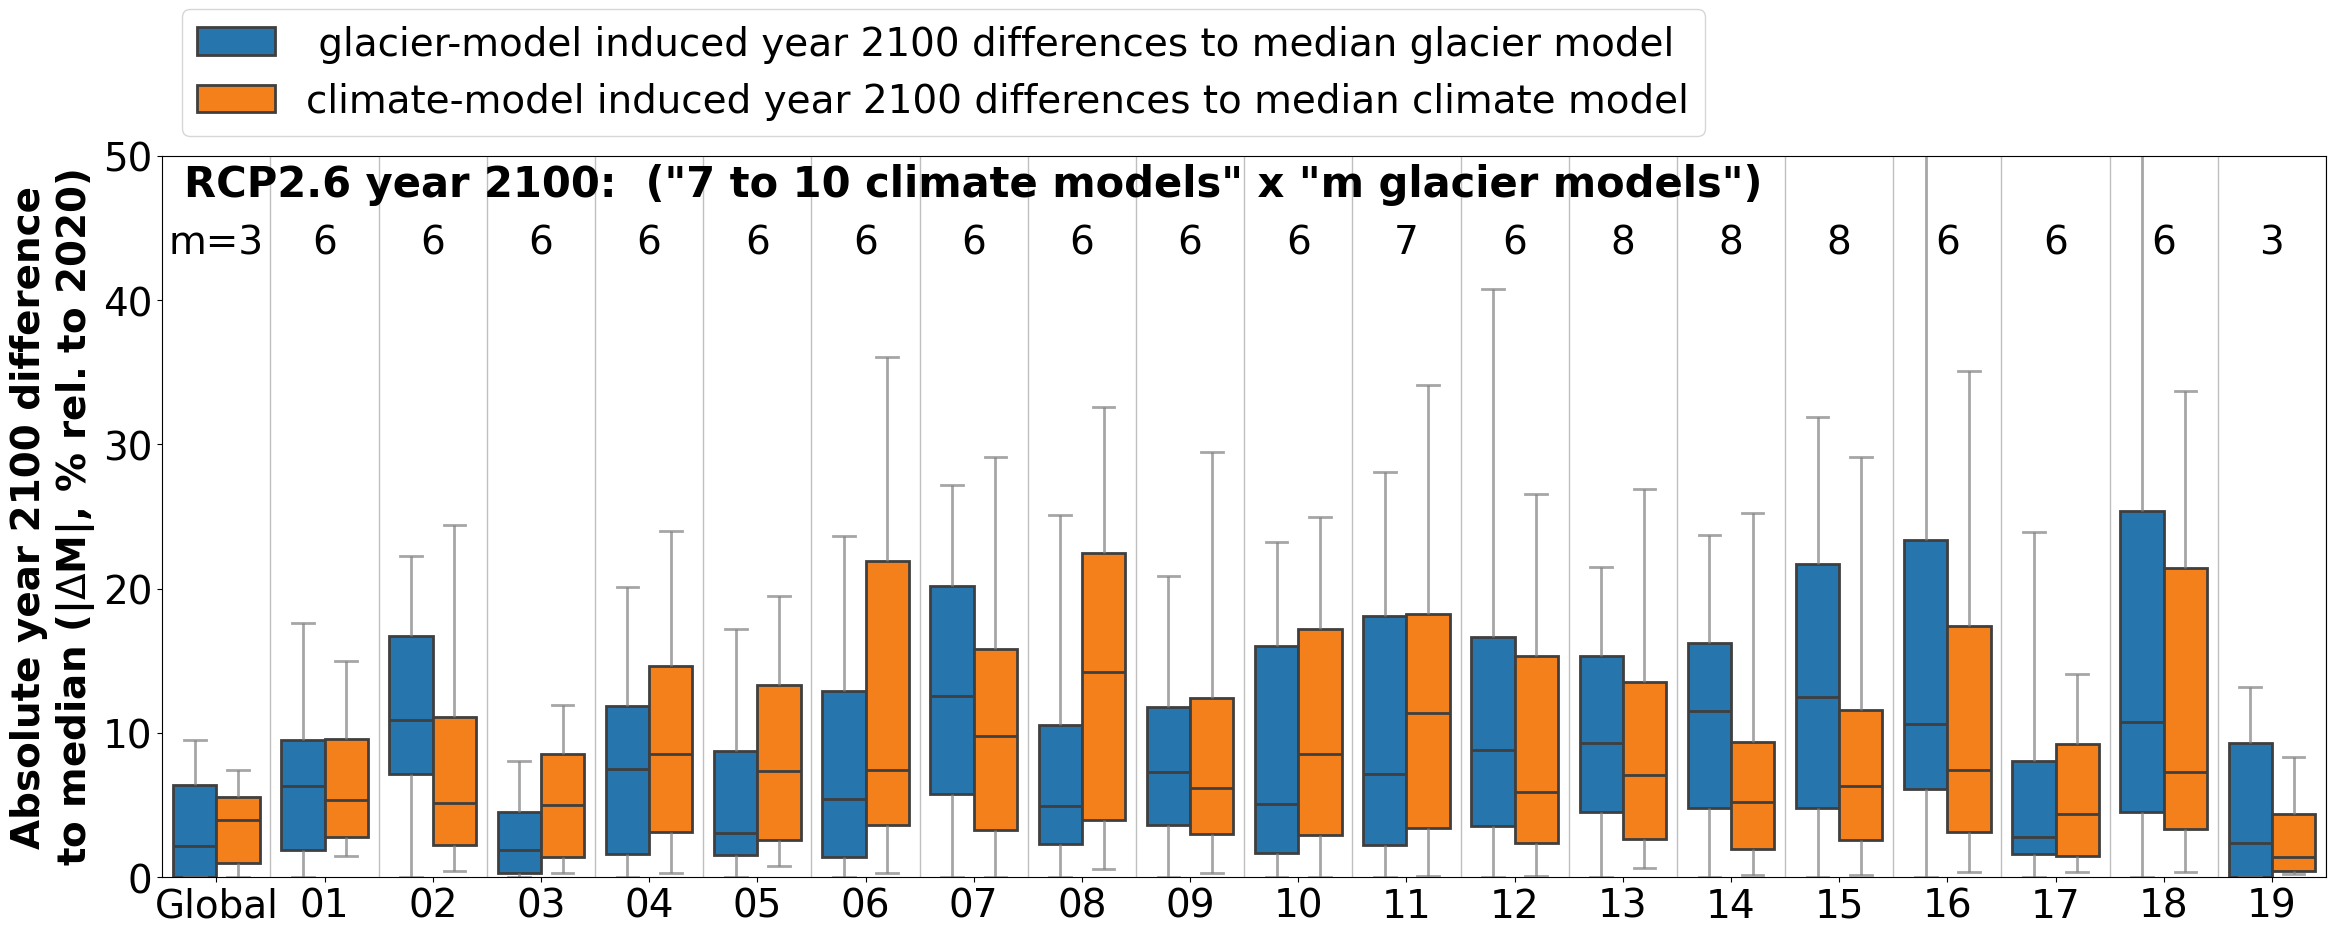

In [25]:
plt.subplots(1,1,figsize=(24,10), sharey=True)
ax = plt.gca()
sns.boxplot(data=pd_ds_gmip2_2100_all_rel,
            ax = ax,
                y='value',
                x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
                hue='variable', 
                hue_order = [' glacier-model induced year 2100 differences to median glacier model', 
                             'climate-model induced year 2100 differences to median climate model'],
               fliersize=0, whis = [5,95], 
                      dodge = True, #hue='ssp',
                      #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
                #y = 'time', #hue_order = ['2040', '2100'],
                linewidth=2,
                capprops={'color':'grey', 'alpha':0.7},
                whiskerprops={'color':'grey', 'alpha':0.7},
                saturation = 0.9,
                #legend=False
                #hue_order=_hue_order, palette=_pal_models,
               )#legend = True)#legend=legend)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
#_,xlim1 = ax.get_xlim()
ax.set_ylim([xlim0,xlim1])

ax.set_ylabel('Absolute year 2100 difference\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)

ax.set_xlabel('', fontsize=26)

for vl in np.arange(0.5,20,1):
    ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
#ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
scenario = ds_gmip2_2100.Scenario.attrs['1']
ax.text(0.01,0.99,f'{scenario} year 2100:  ("7 to 10 climate models" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
_c = pd_ds_gmip2_2100_all_rel.groupby(['rgi_reg','Glacier_Model'], observed=False)['value'].median().dropna().reset_index()
_c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
for j,c in enumerate(_c.values):
    if j ==0:
        ax.text(j,44,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
    else:
        ax.text(j,44,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
        
plt.tight_layout()
plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/gmip2_comparison_glacier_vs_climate_model_induced_differences_{scenario}_year_2100.png')
plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/gmip2_comparison_glacier_vs_climate_model_induced_differences_{scenario}_year_2100.pdf')

**I could now do the same for a specific temperature range...**

In [26]:
##### GMT changes for different GCMs of CMIP5 and CMIP6
# you can directly download these files from the following urls, or let OGGM do that
# import oggm 
#_file_cmip5 = oggm.utils.file_downloader('https://cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/analysis_notebooks/Global_mean_temp_deviation_2071_2100_2081_2100_2271_2300_2281_2300_rel_1850_1900_cmip5_gcms_ipcc_ar6_def.csv', reset=True)
#_file_cmip6 = oggm.utils.file_downloader('https://cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/analysis_notebooks/Global_mean_temp_deviation_2071_2100_2081_2100_2271_2300_2281_2300_rel_1850_1900_cmip6_gcms_ipcc_ar6_def.csv', reset=True)
## cmip5
pd_cmip5_temp_ch_2100 = pd.read_csv('/home/users/lschuster/www_oggm/oggm-standard-projections/analysis_notebooks/Global_mean_temp_deviation_2071_2100_2081_2100_2271_2300_2281_2300_rel_1850_1900_cmip5_gcms_ipcc_ar6_def.csv', index_col=0)
pd_cmip5_temp_ch_2100['cmip'] = 'CMIP5'
## cmip6

In [27]:
ds_gmip2_2100 = ds_gmip2.sel(Time=2100)
ds_gmip2_2020 = ds_gmip2.sel(Time=2020)
ds_gmip2_2100_rel = 100*ds_gmip2_2100.Mass/ds_gmip2_2020.Mass

In [28]:
_glob = 100*ds_gmip2_2100.Mass.sum(dim='Region', min_count=19) / ds_gmip2_2020.Mass.sum(dim='Region', min_count=19)

In [29]:
new_region = xr.DataArray(
    _glob.values.reshape(4,11,10,1),
    dims=["Scenario", "Glacier_Model", "Climate_Model", "Region"],
    coords={
        "Scenario": _glob.Scenario,
        "Glacier_Model": _glob.Glacier_Model,
        "Climate_Model": _glob.Climate_Model,
        "Region": [20],  # New region index
    },
    name="Mass",
)

In [30]:
ds_gmip2_2100_rel_all = xr.concat([ds_gmip2_2100_rel,new_region], dim = 'Region')

In [31]:
ds_gmip2_2100_rel_all.Scenario

<xarray.DataArray 'Scenario' (Scenario: 4)>
array([1., 2., 3., 4.])
Coordinates:
  * Scenario  (Scenario) float64 1.0 2.0 3.0 4.0
Attributes:
    1:        RCP2.6
    2:        RCP4.5
    3:        RCP6.0
    4:        RCP8.5

In [32]:
rename_dict = ds_gmip2_2100_rel_all.Climate_Model.attrs
# Convert Climate_Model to integer, then to string 
_t =ds_gmip2_2100_rel_all.Climate_Model.astype(int).astype(str).to_pandas()
_t.index = _t.values
_t = _t.map(rename_dict)
ds_gmip2_2100_rel_all = ds_gmip2_2100_rel_all.assign_coords(
    Climate_Model=_t
)

In [33]:
rename_dict = ds_gmip2_2100_rel_all.Scenario.attrs

rename_dict_rcp = {}
rename_dict_rcp['RCP2.6'] = 'rcp26'
rename_dict_rcp['RCP4.5'] = 'rcp45'
rename_dict_rcp['RCP6.0'] = 'rcp60'
rename_dict_rcp['RCP8.5'] = 'rcp85'
for r in rename_dict.keys():
    rename_dict[r] = rename_dict_rcp[rename_dict[r]]

In [34]:
# Convert Climate_Model to integer, then to string 
_t =ds_gmip2_2100_rel_all.Scenario.astype(int).astype(str).to_pandas()
_t.index = _t.values
_t = _t.map(rename_dict)
ds_gmip2_2100_rel_all = ds_gmip2_2100_rel_all.assign_coords(
    Scenario=_t
)

In [35]:
pd_gmip2_2100 = ds_gmip2_2100_rel_all.to_dataframe().reset_index().dropna()

In [36]:
pd_gmip2_2100.loc[pd_gmip2_2100.Region==19].Glacier_Model.unique()

array([ 2.,  3., 11., 10.])

In [37]:
pd_gmip2_2100['gcm_rcp']  = ''

In [38]:
for j in pd_gmip2_2100.index:
    pd_gmip2_2100.loc[j,'gcm_rcp'] = pd_gmip2_2100.loc[j]['Climate_Model'].upper() +'_' + pd_gmip2_2100.loc[j]['Scenario']

In [39]:
pd_gmip2_2100 = pd_gmip2_2100.set_index('gcm_rcp')

In [40]:
not_in_cmip5 = list(set(pd_gmip2_2100.index.unique())-set(pd_cmip5_temp_ch_2100.index.unique()))
print(not_in_cmip5)  # Output: ['apple', 'cherry']

['GFDL-ESM2M_rcp26', 'GFDL-ESM2M_rcp85', 'GFDL-ESM2M_rcp60', 'GFDL-ESM2M_rcp45']


In [41]:
not_in_gmip2 = list(set(pd_cmip5_temp_ch_2100.index.unique()) - set(pd_gmip2_2100.index.unique()))
print(not_in_gmip2)  # Output: ['apple', 'cherry']

['CESM1-CAM5_rcp26', 'CESM1-CAM5_rcp45', 'CESM1-CAM5_rcp60', 'GFDL-ESM2G_rcp45', 'GFDL-ESM2G_rcp85', 'GFDL-ESM2G_rcp26', 'GFDL-ESM2G_rcp60']


In [42]:
for gcm_rcp in pd_cmip5_temp_ch_2100.index:
    pd_gmip2_2100.loc[gcm_rcp, 'temp_ch_ipcc'] = pd_cmip5_temp_ch_2100.loc[gcm_rcp, 'global_temp_ch_2071-2100_preindustrial']

In [43]:
pd_gmip2_2100 = pd_gmip2_2100.dropna(axis='rows')
pd_gmip2_2100['rgi_reg'] =  [f'{int(i):02}' for i in pd_gmip2_2100['Region']]
pd_gmip2_2100 = pd_gmip2_2100.reset_index()
pd_gmip2_2100.loc[pd_gmip2_2100.rgi_reg == '20', 'rgi_reg'] = 'Global'

In [44]:
pd_gmip2_2100

,gcm_rcp,Scenario,Glacier_Model,Climate_Model,Region,Mass,temp_ch_ipcc,rgi_reg
0,CANESM2_rcp26,rcp26,2.0,CanESM2,1.0,60.082691,2.180245,01
1,CANESM2_rcp26,rcp26,2.0,CanESM2,2.0,32.242387,2.180245,02
2,CANESM2_rcp26,rcp26,2.0,CanESM2,3.0,81.633554,2.180245,03
3,CANESM2_rcp26,rcp26,2.0,CanESM2,4.0,68.022014,2.180245,04
4,CANESM2_rcp26,rcp26,2.0,CanESM2,5.0,55.416901,2.180245,05
...,...,...,...,...,...,...,...,...
3351,NORESM1-M_rcp85,rcp85,11.0,NorESM1-M,16.0,3.446311,3.670783,16
3352,NORESM1-M_rcp85,rcp85,11.0,NorESM1-M,17.0,66.783880,3.670783,17
3353,NORESM1-M_rcp85,rcp85,11.0,NorESM1-M,18.0,24.453497,3.670783,18
3354,NORESM1-M_rcp85,rcp85,11.0,NorESM1-M,19.0,77.039513,3.670783,19


0.2 3 1.5455853152232657
0.5 7 1.5794275401255526
0.2 4 2.0056055185721697
0.5 12 2.1354196995913264
0.2 4 2.5040993657126784
0.5 14 2.5040993657126784
0.2 5 2.9837146384554694
0.5 10 2.9120243828310515


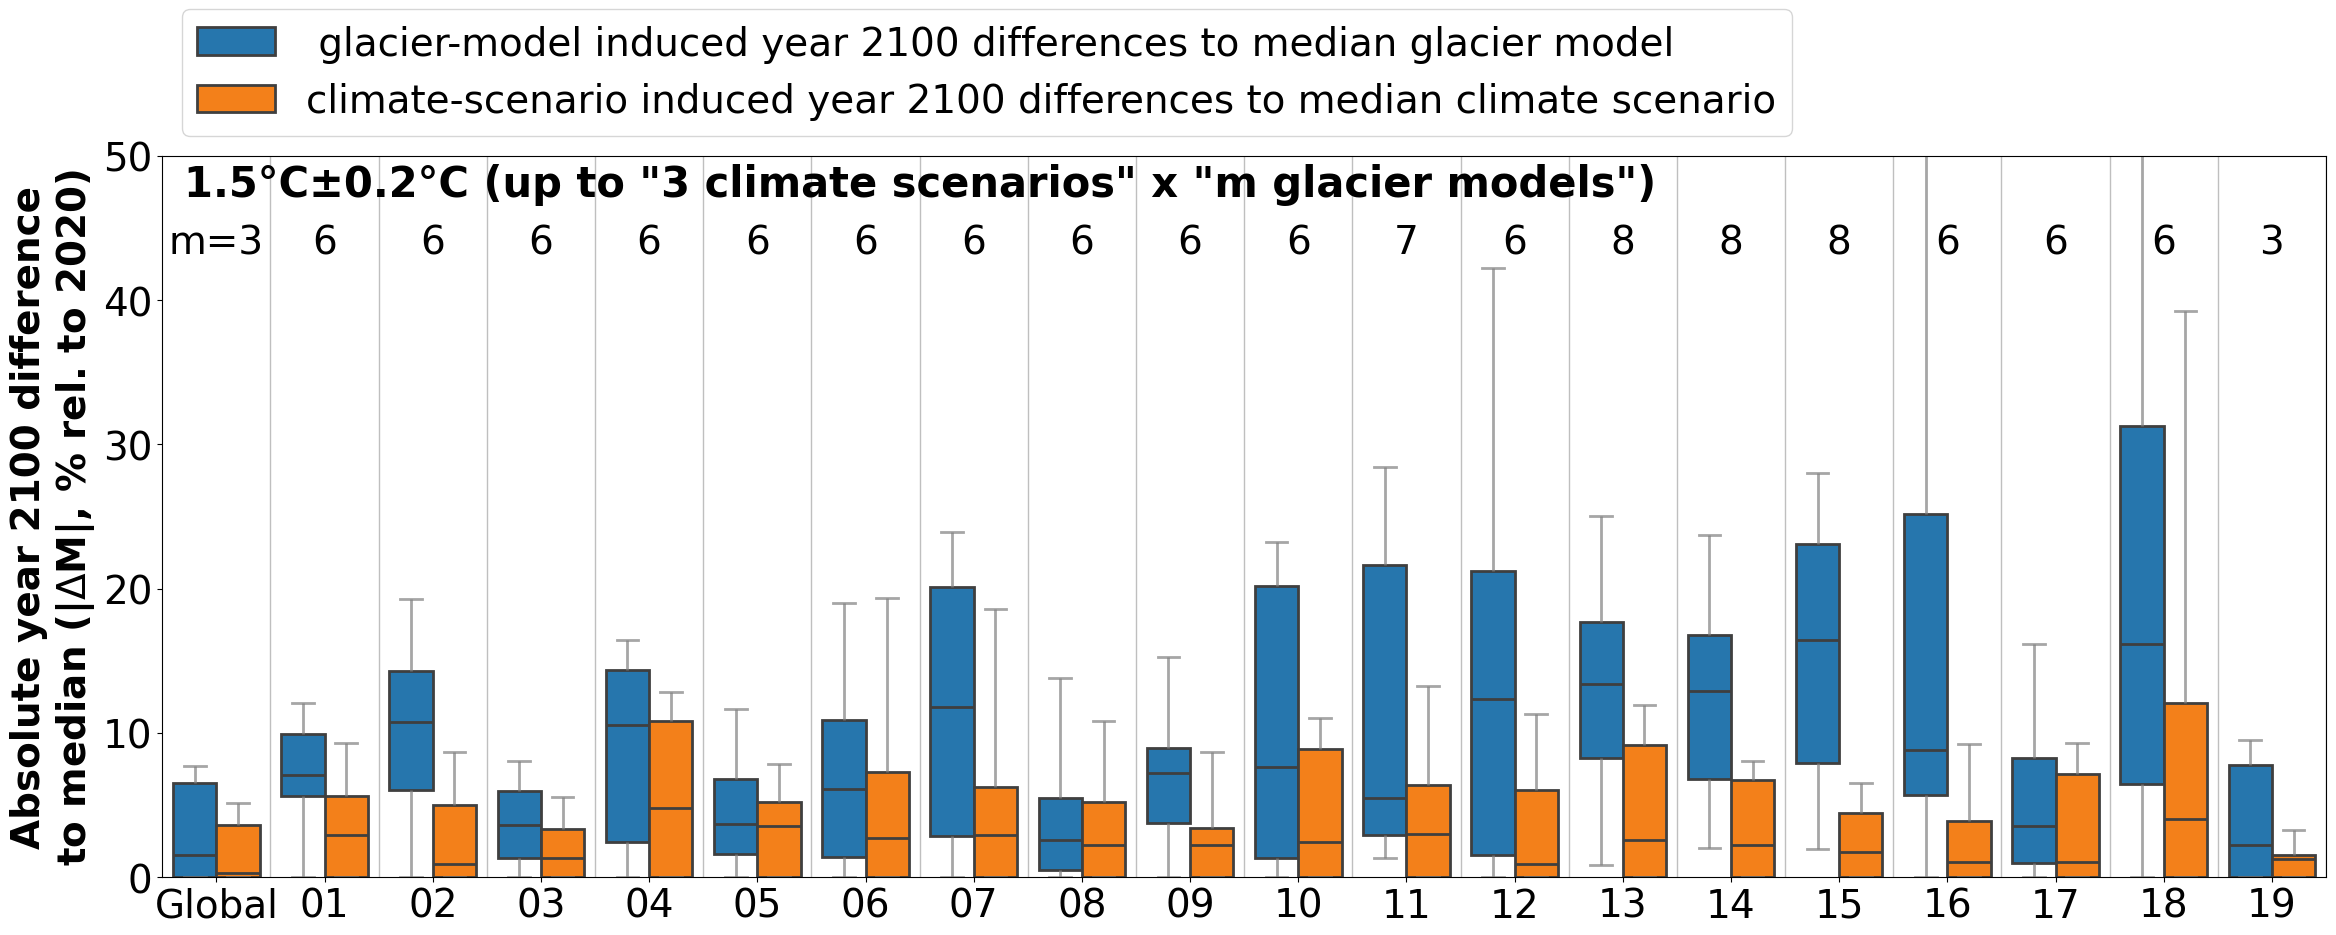

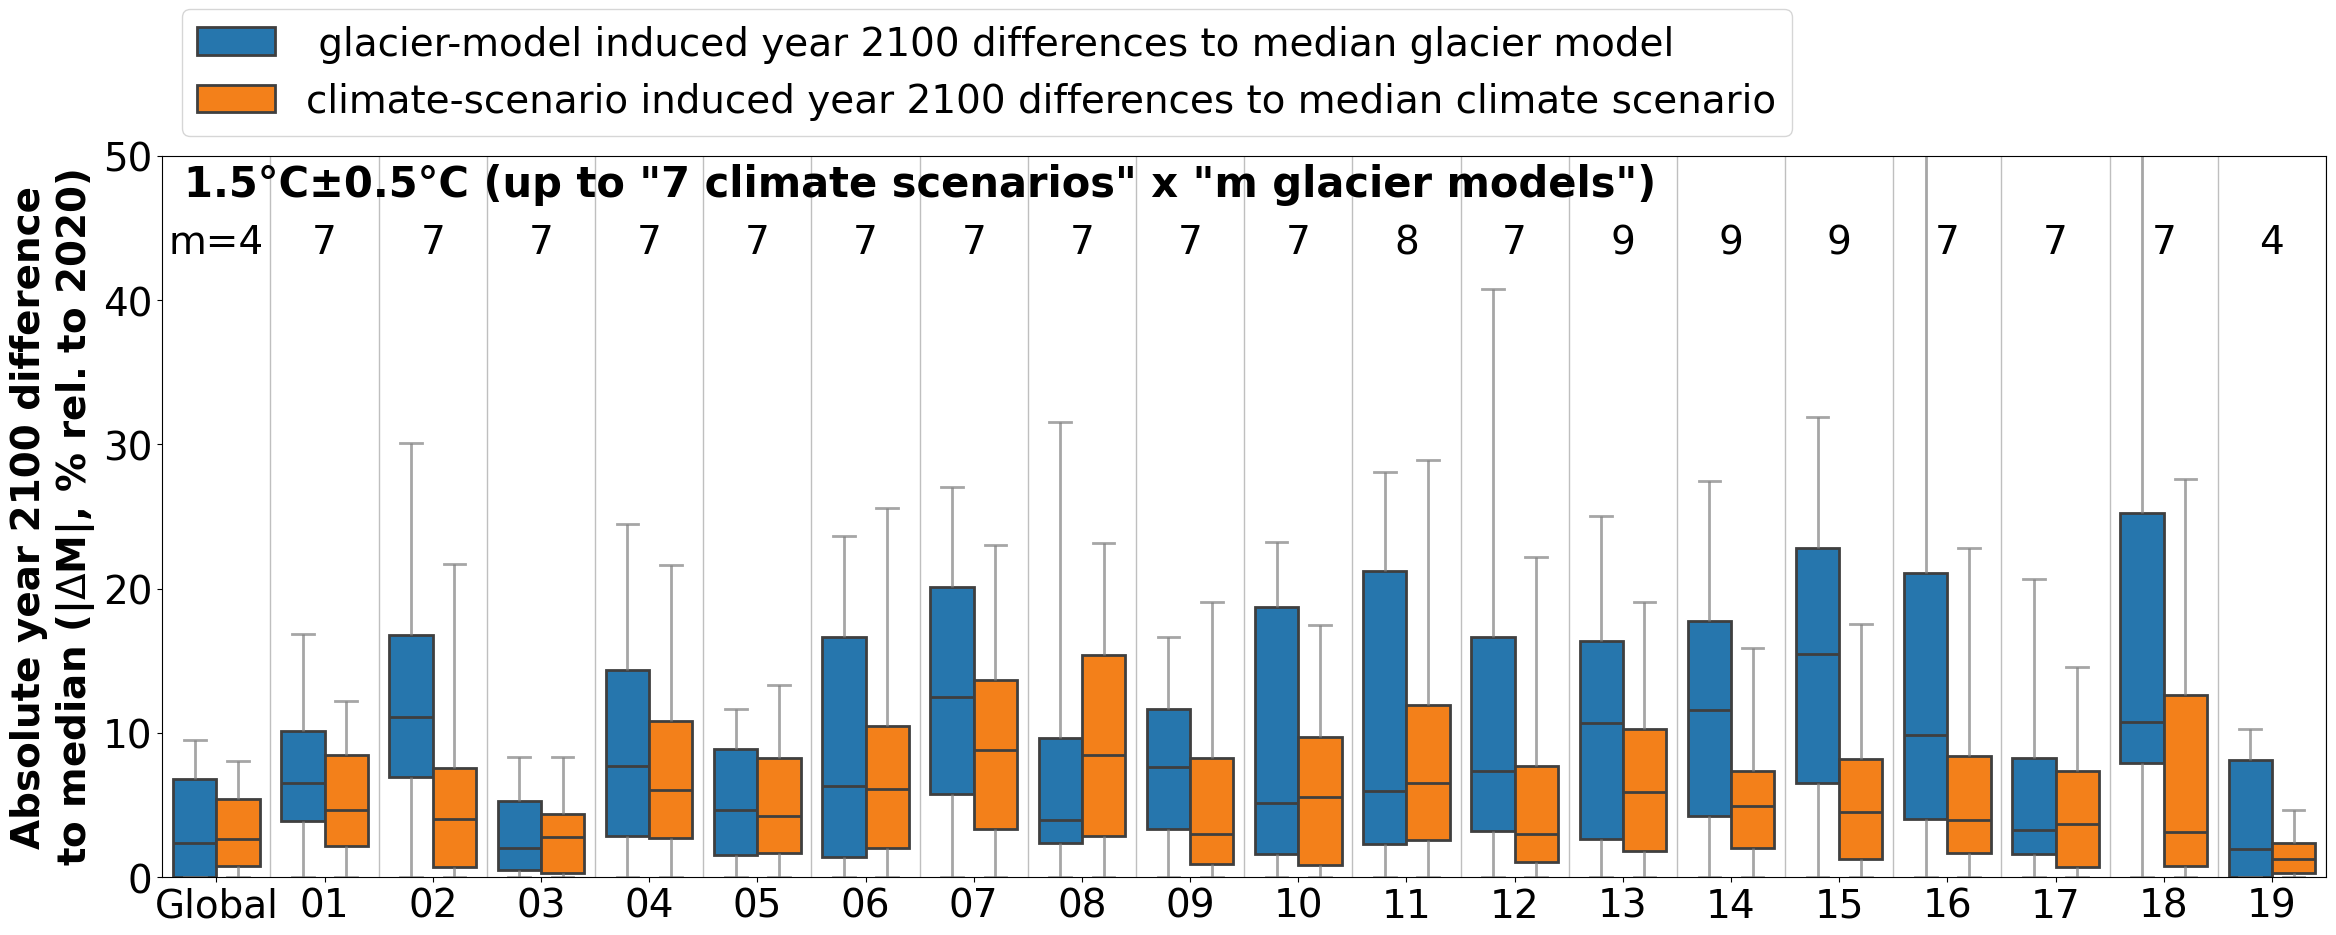

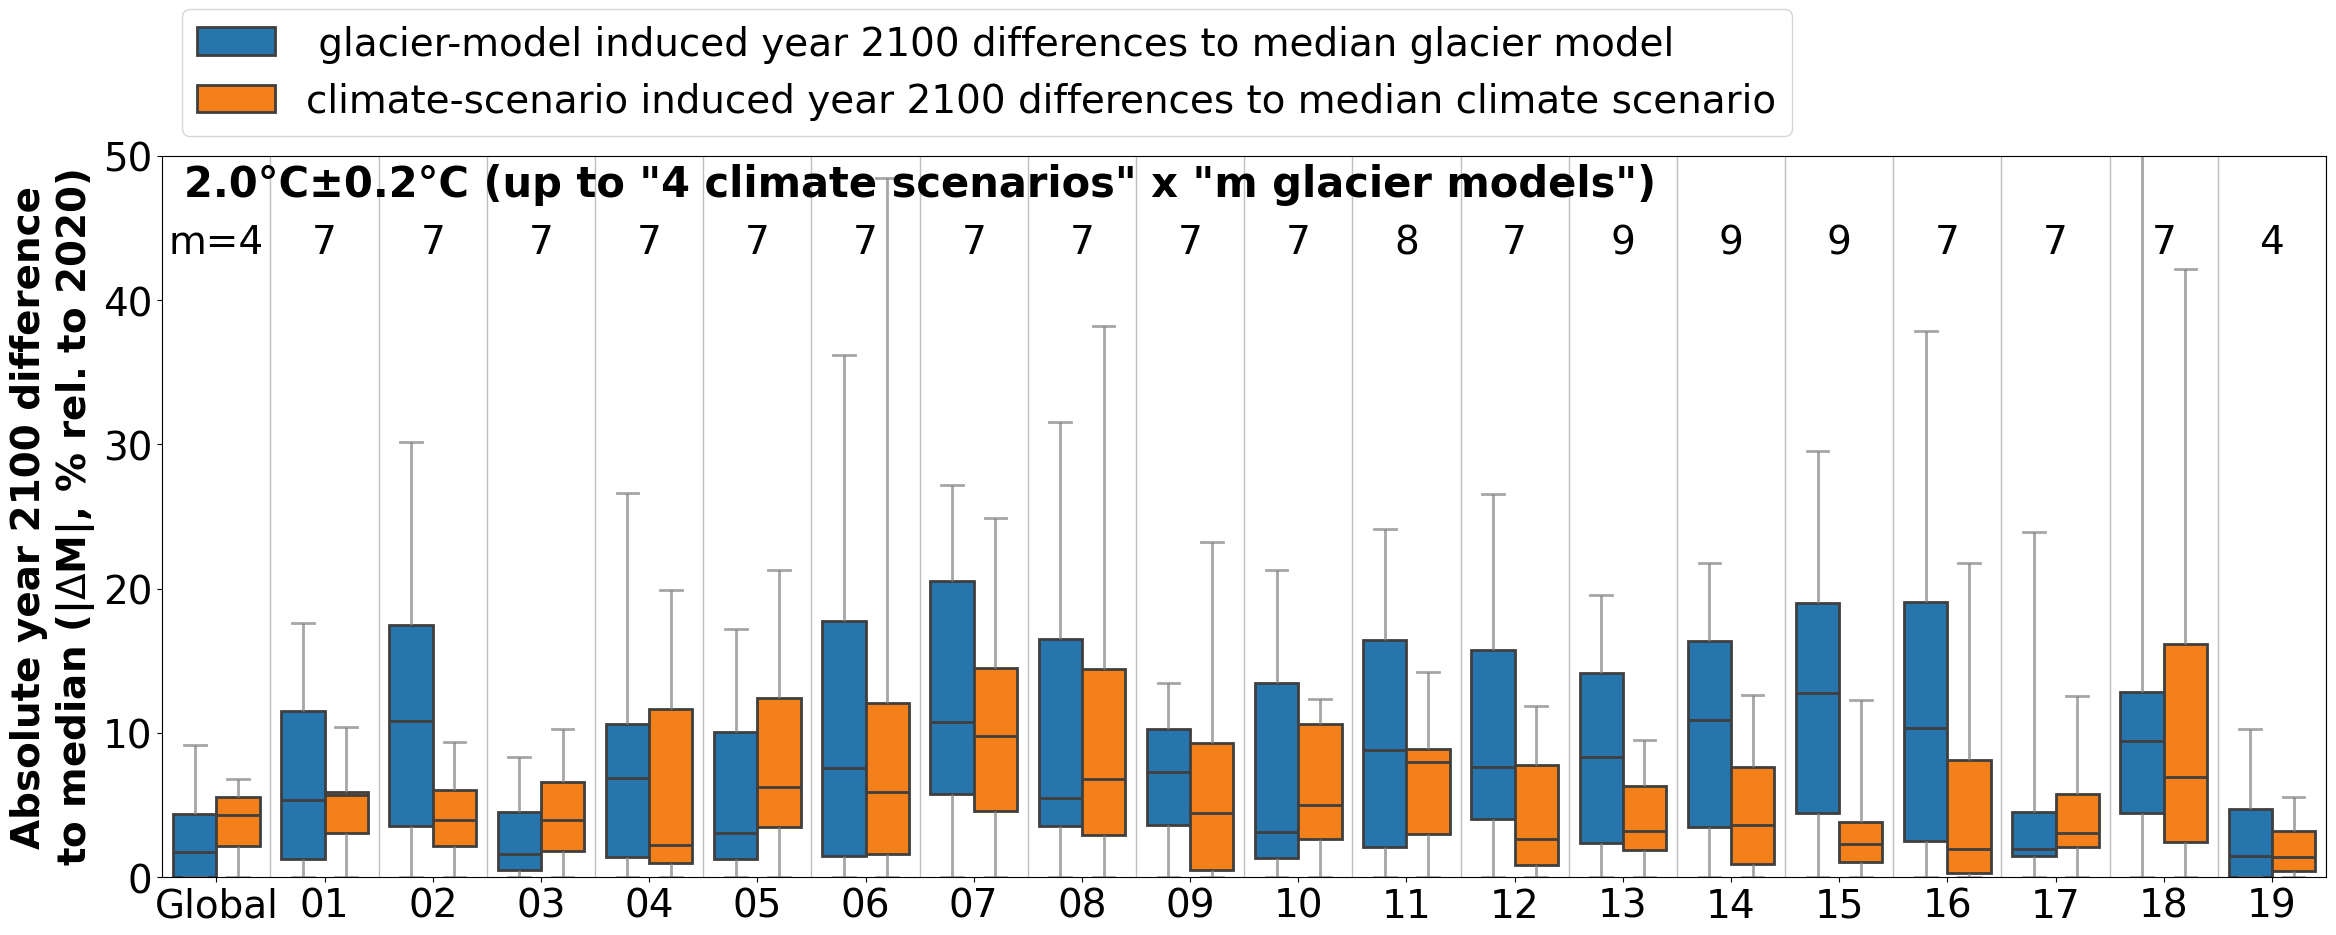

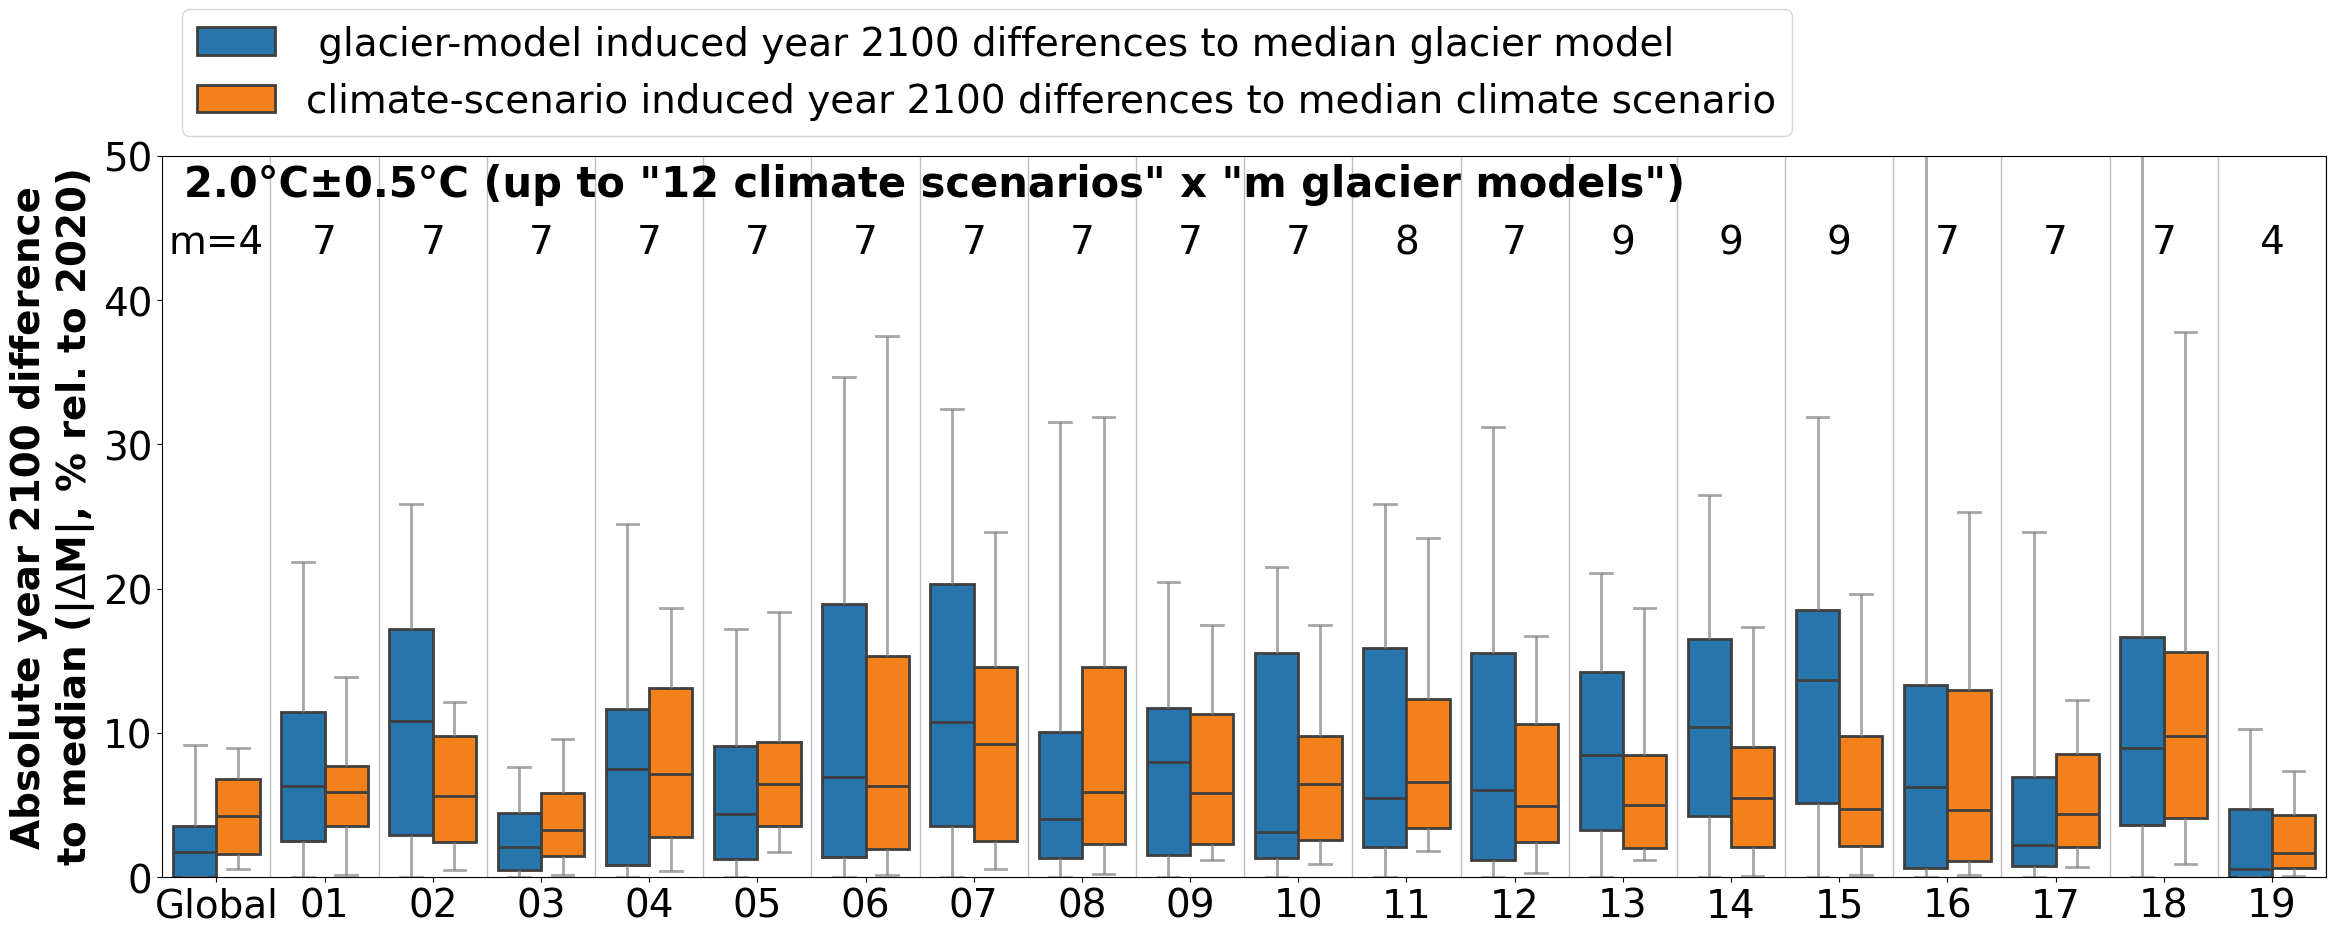

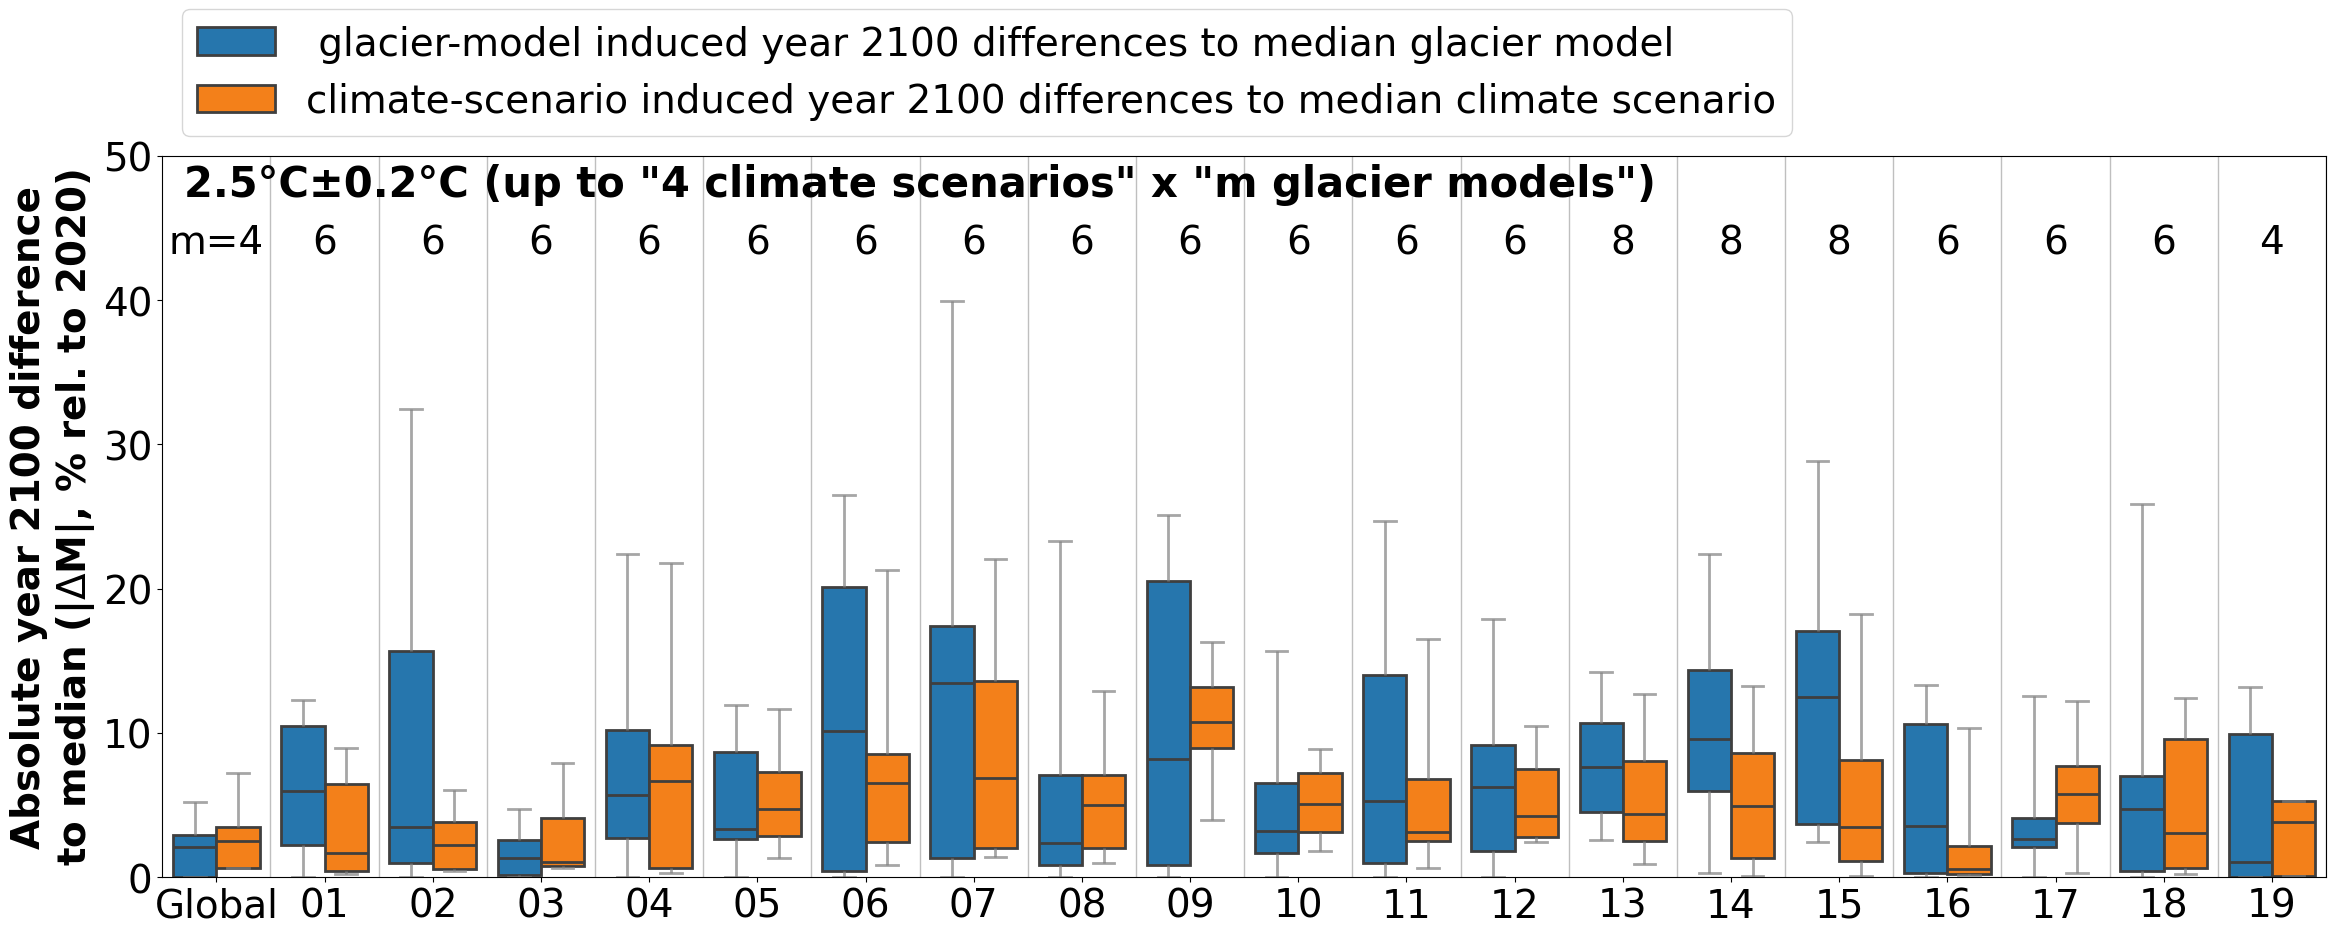

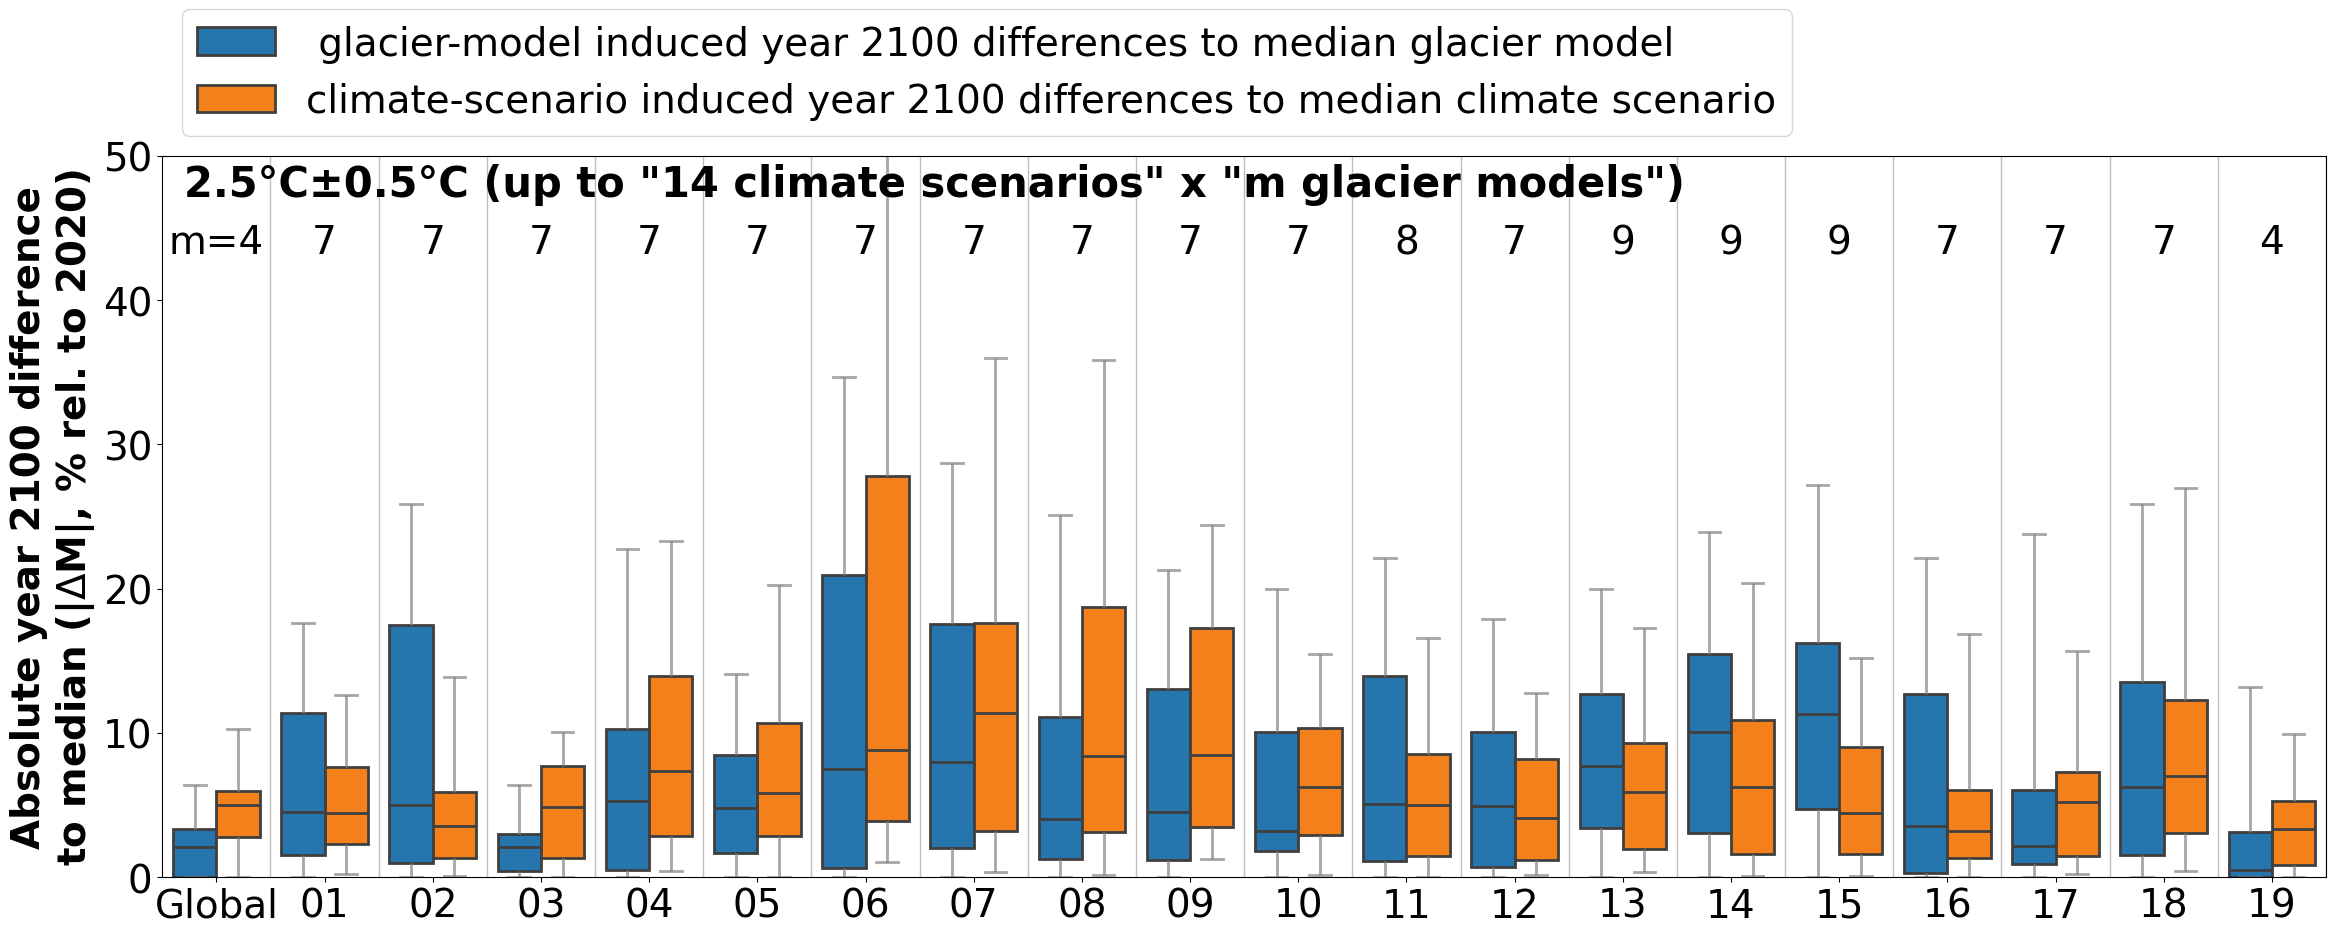

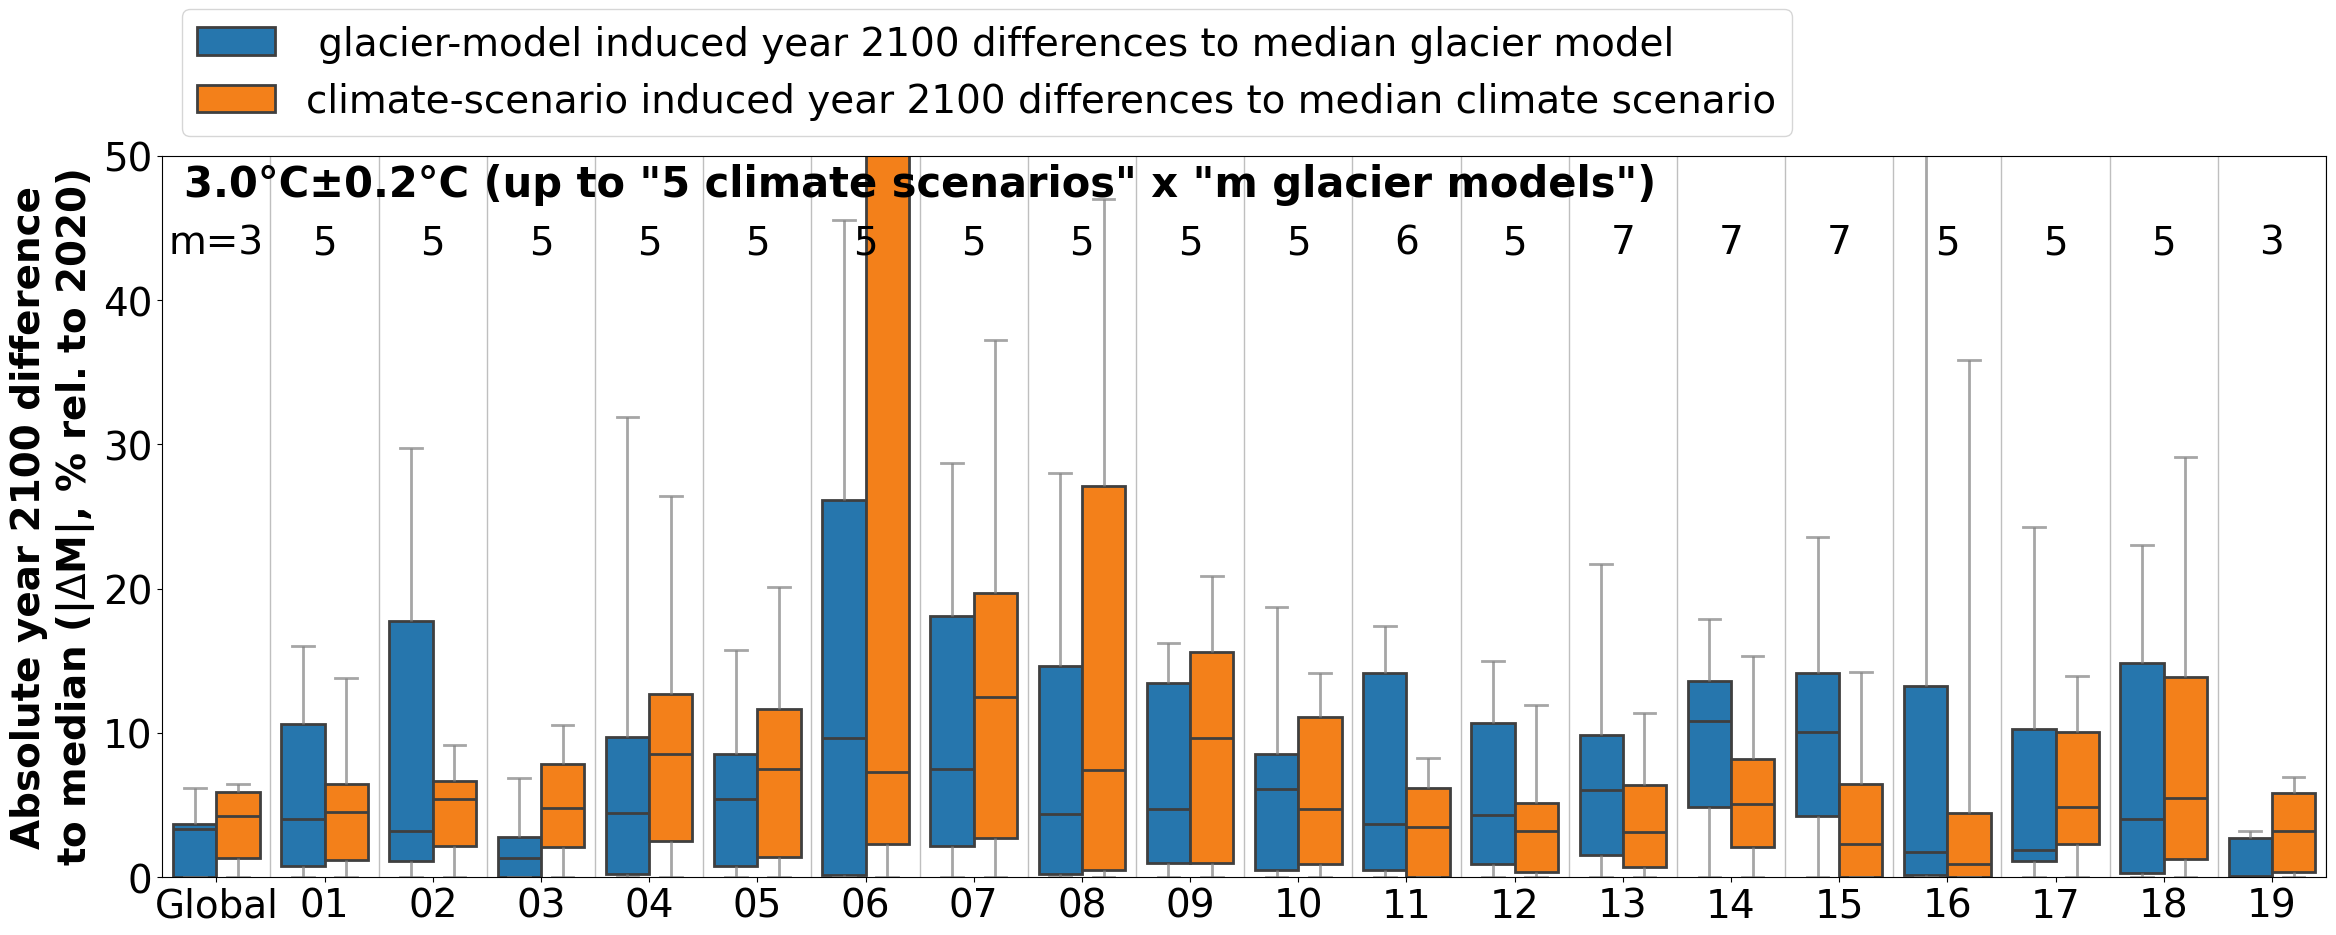

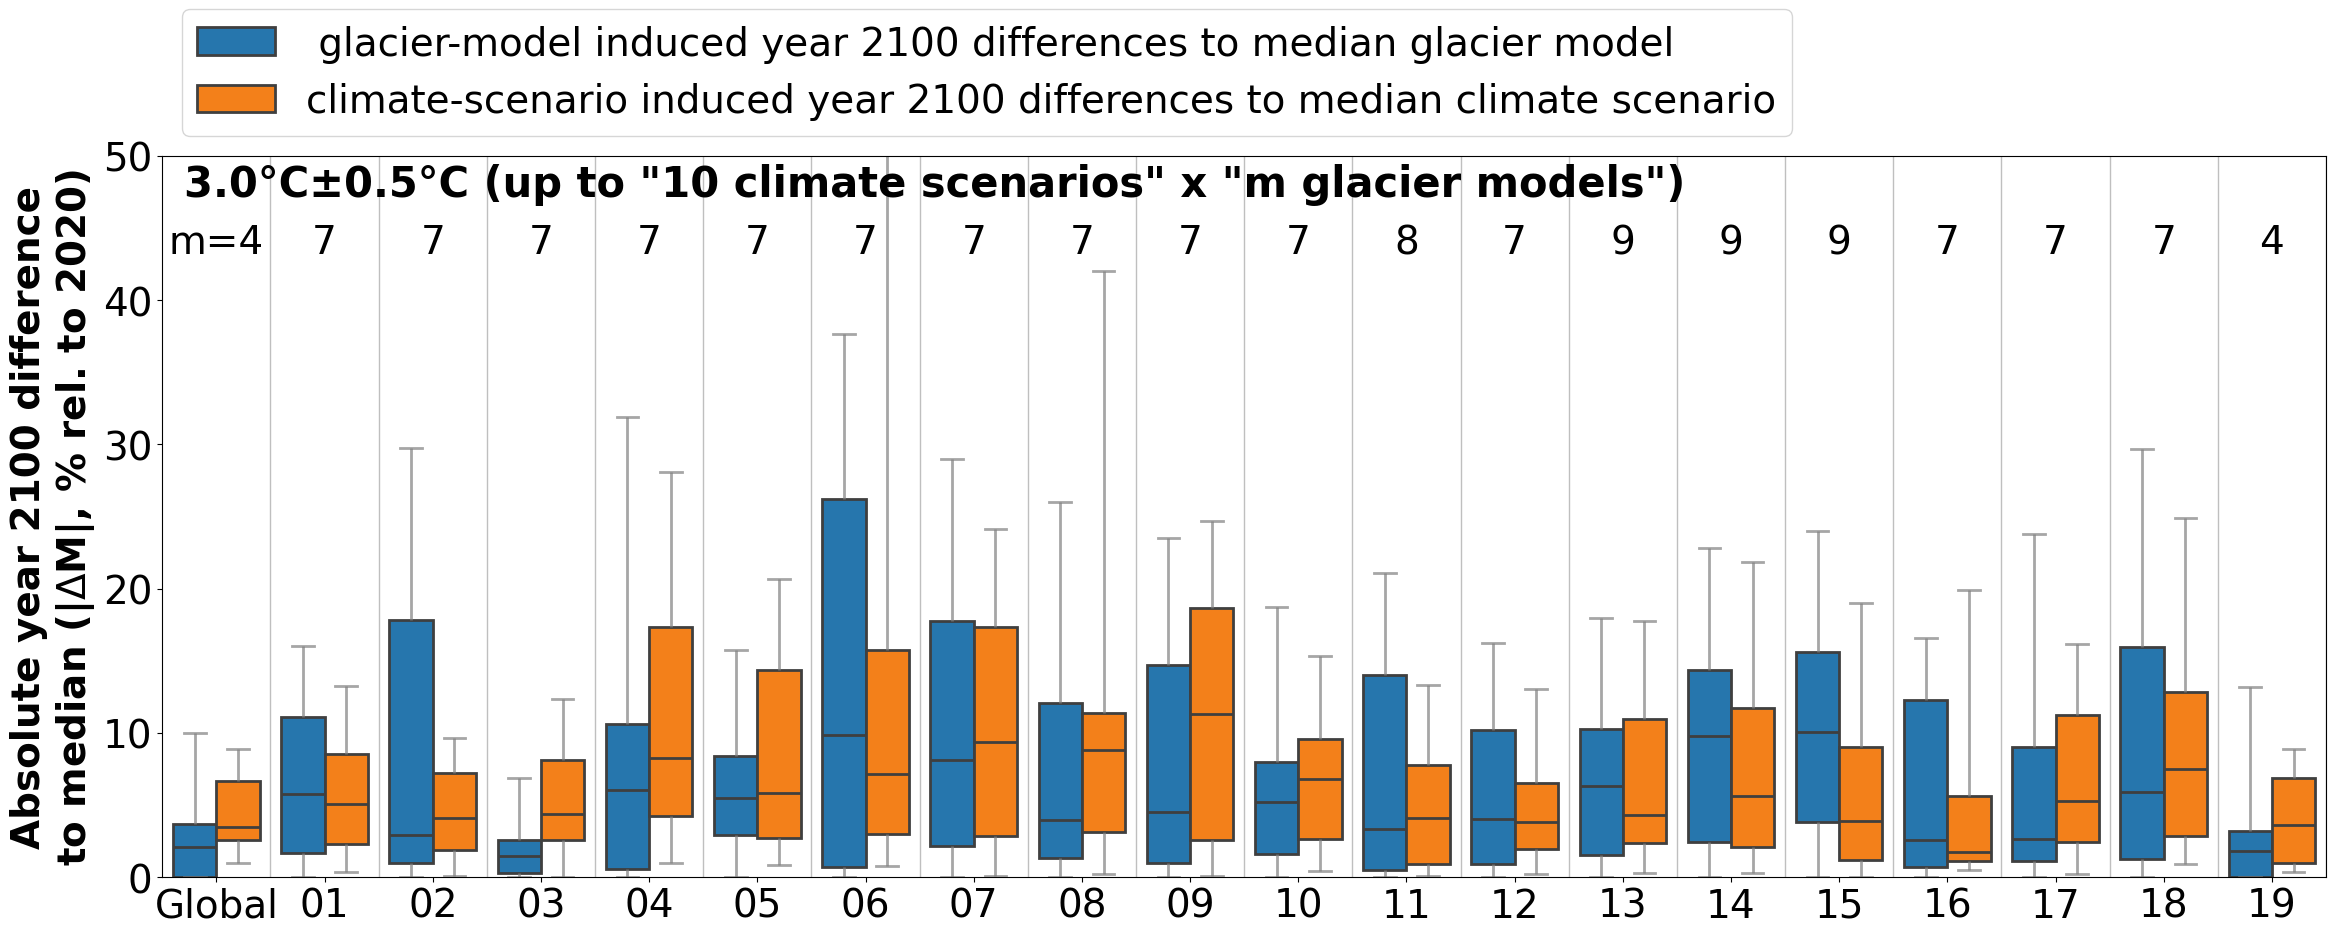

In [45]:
plt.rc('font', size=28)  


for temp in [1.5, 2.0, 2.5, 3.0]:
    for j,delta in enumerate([0.2, 0.5]): 
        plt.subplots(1,1,figsize=(24,10), sharey=True)
        _sel_temp = pd_gmip2_2100.loc[(pd_gmip2_2100.temp_ch_ipcc>=temp-delta) & 
                                            (pd_gmip2_2100.temp_ch_ipcc<=temp+delta)]
        n = len(_sel_temp.groupby(['Scenario','Climate_Model']).count())
        print(delta, n, _sel_temp.groupby(['Climate_Model','gcm_rcp'])['temp_ch_ipcc'].median().median())
        assert np.all(_sel_temp.groupby(['rgi_reg', 'Glacier_Model', 'temp_ch_ipcc']).count()==1)
        
        ds_sel_temp = _sel_temp.groupby(['rgi_reg', 'Glacier_Model',
                                      'temp_ch_ipcc'])[['Mass']].median().to_xarray()
        ds_sel_temp['delta relative volume change (in %, to median climate)'] = ds_sel_temp['Mass'] - ds_sel_temp['Mass'].median(dim='temp_ch_ipcc')
        ds_sel_temp['delta relative volume change (in %, to median model)'] = ds_sel_temp['Mass'] - ds_sel_temp['Mass'].median(dim='Glacier_Model')
        ds_sel_temp[' glacier-model induced year 2100 differences to median glacier model'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median model)'])
        ds_sel_temp['climate-scenario induced year 2100 differences to median climate scenario'] = np.abs(ds_sel_temp['delta relative volume change (in %, to median climate)'])
        _sel_temp = ds_sel_temp.to_dataframe().dropna()
        _sel_temp = _sel_temp.reset_index()
        _sel_temp_melt = _sel_temp.melt(id_vars=['rgi_reg', 'Glacier_Model', 'temp_ch_ipcc'],
                      value_vars=[' glacier-model induced year 2100 differences to median glacier model',
                                  'climate-scenario induced year 2100 differences to median climate scenario'])

        # Define custom sorting order
        custom_order = ['Global'] + [f'{i:02}' for i in range(1, 20)]  # 'Global', '01', '02', ..., '12'
        # Create a categorical type with the custom order
        _sel_temp_melt['rgi_reg'] = pd.Categorical(_sel_temp_melt['rgi_reg'], categories=custom_order, ordered=True) 
        # Sort the DataFrame by the 'rgi_reg' column
        _sel_temp_melt = _sel_temp_melt.sort_values('rgi_reg').reset_index(drop=True)

        
        ax = plt.gca()
        y=f'delta relative volume change (in %, to median climate {temp}+/-{delta}°C)'
    
        xlim0=0#-35
        xlim1 = 50
        sns.boxplot(data=_sel_temp_melt,
                    ax = ax,
                    y='value',
                    x='rgi_reg', #hue='model_author', hue_order=hue_ord, palette=pal_mod,
                    hue='variable', 
                    hue_order = [' glacier-model induced year 2100 differences to median glacier model', 
                                 'climate-scenario induced year 2100 differences to median climate scenario'],
                   fliersize=0, whis = [5,95], 
                          dodge = True, #hue='ssp',
                          #order = list(_sel_class1_sorted.rgi_reg_long.values), # order after -0.1 to 2.0°C 
                    #y = 'time', #hue_order = ['2040', '2100'],
                    linewidth=2,
                    capprops={'color':'grey', 'alpha':0.7},
                    whiskerprops={'color':'grey', 'alpha':0.7},
                    saturation = 0.9,
                    #legend=False
                    #hue_order=_hue_order, palette=_pal_models,
                   )#legend = True)#legend=legend)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(0,1.001), ncol=1)
        #_,xlim1 = ax.get_xlim()
        ax.set_ylim([xlim0,xlim1])
    
        ax.set_ylabel('Absolute year 2100 difference\nto median '+r'(|$\Delta$M|, % rel. to 2020)', weight='bold',fontsize=28)
    
    
        ax.set_xlabel('', fontsize=26)
        #for n in np.arange(xlim0+15,xlim1,20):
        #    ax.axhline(n, color='grey', ls=':', alpha = 0.5, lw=2)
        #ax.axhline(0, color='grey', ls=':', alpha = 1, lw=3)
        for vl in np.arange(0.5,20,1):
            ax.axvline(vl, color='grey', ls='-', alpha = 0.5, lw=1)
        #ax.text(-0.4,61, text_temp_ch_class_d[temp_ch_class], color='grey', weight='bold')
        ax.text(0.01,0.99,f'{temp}°C±{delta}°C (up to "{n} climate scenarios" x "m glacier models")',ha='left',va='top', transform=ax.transAxes, fontsize = 30, weight='bold')
        _c = _sel_temp_melt.groupby(['rgi_reg','Glacier_Model'], observed=False)['value'].median().dropna().reset_index()
        _c = _c.groupby(['rgi_reg'], observed=False)['value'].count()
        for j,c in enumerate(_c.values):
            if j ==0:
                ax.text(j,44,f'm={c}',ha='center',va='center', fontsize = 28) #, weight='bold')
            else:
                ax.text(j,44,f'{c}',ha='center',va='center', fontsize = 28) #, weight='bold')
                
        plt.tight_layout()
        _temp = str(temp).replace('.','-')
        _delta = str(delta).replace('.','-')
        plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/gmip2_2100_glacier_vs_climate_scenario_induced_differences_{_temp}_delta{_delta}.png')
        plt.savefig(f'figures_partB/glacier_vs_climate_model_differences/gmip2_2100_glacier_vs_climate_scenario_induced_differences_{_temp}_delta{_delta}.pdf')

In [46]:
_sel_temp_melt#.loc[_sel_temp_melt.rgi_reg == 

,rgi_reg,Glacier_Model,temp_ch_ipcc,variable,value
0,Global,11.0,3.380412,glacier-model induced year 2100 differences t...,0.000000
1,Global,11.0,3.073030,glacier-model induced year 2100 differences t...,0.000000
2,Global,11.0,2.983715,glacier-model induced year 2100 differences t...,6.197155
3,Global,11.0,2.953417,glacier-model induced year 2100 differences t...,0.000000
4,Global,11.0,2.870632,glacier-model induced year 2100 differences t...,3.312593
...,...,...,...,...,...
1781,19,11.0,2.870632,climate-scenario induced year 2100 differences...,7.332366
1782,19,11.0,2.953417,climate-scenario induced year 2100 differences...,8.634544
1783,19,11.0,2.983715,climate-scenario induced year 2100 differences...,3.602930
1784,19,11.0,3.082013,climate-scenario induced year 2100 differences...,0.366587


0.0    1.179877
0.5    1.579428
1.0    1.920616
Name: temp_ch_ipcc, dtype: float64


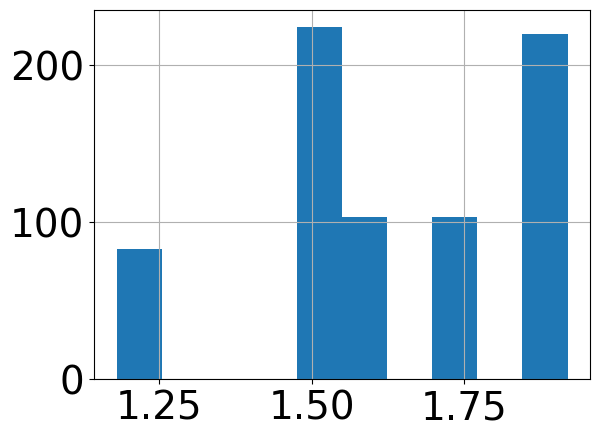

In [47]:
pd_gmip2_2100.loc[(pd_gmip2_2100.temp_ch_ipcc>1.0)&(pd_gmip2_2100.temp_ch_ipcc<2.0)].temp_ch_ipcc.hist()#quantile([0,0.5,1.0])
print(pd_gmip2_2100.loc[(pd_gmip2_2100.temp_ch_ipcc>1.0)&(pd_gmip2_2100.temp_ch_ipcc<2.0)].temp_ch_ipcc.quantile([0,0.5,1.0]))

0.0    1.545585
0.5    2.090595
1.0    2.463212
Name: temp_ch_ipcc, dtype: float64


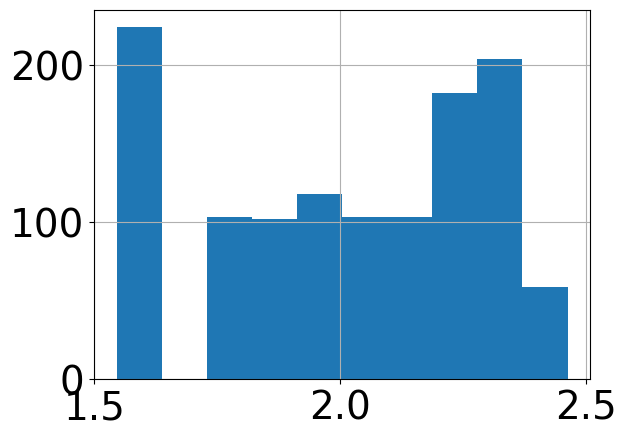

In [48]:
pd_gmip2_2100.loc[(pd_gmip2_2100.temp_ch_ipcc>1.5)&(pd_gmip2_2100.temp_ch_ipcc<2.5)].temp_ch_ipcc.hist()#quantile([0,0.5,1.0])
print(pd_gmip2_2100.loc[(pd_gmip2_2100.temp_ch_ipcc>1.5)&(pd_gmip2_2100.temp_ch_ipcc<2.5)].temp_ch_ipcc.quantile([0,0.5,1.0]))

In [49]:
_sel_temp_melt.loc[_sel_temp_melt.rgi_reg=='19']

,rgi_reg,Glacier_Model,temp_ch_ipcc,variable,value
1740,19,3.0,2.983715,glacier-model induced year 2100 differences t...,0.546373
1741,19,10.0,2.870632,glacier-model induced year 2100 differences t...,0.000000
1742,19,3.0,2.870632,glacier-model induced year 2100 differences t...,2.859592
1743,19,3.0,3.082013,glacier-model induced year 2100 differences t...,2.600370
1744,19,3.0,3.380412,glacier-model induced year 2100 differences t...,0.000000
1745,19,10.0,2.544987,glacier-model induced year 2100 differences t...,0.000000
1746,19,10.0,2.783992,glacier-model induced year 2100 differences t...,2.093535
1747,19,3.0,2.783992,glacier-model induced year 2100 differences t...,1.817317
1748,19,10.0,2.983715,glacier-model induced year 2100 differences t...,0.120888
1749,19,11.0,2.953417,glacier-model induced year 2100 differences t...,0.000000


In [50]:
_a = pd_ds_gmip2_2100_all_rel.loc[pd_ds_gmip2_2100_all_rel.rgi_reg=='19']
_a.Glacier_Model.unique()

array([ 2., 11.,  3.])